# Workshop Bias di Genere — Modelli e Casi Sperimentali

**Dataset**: NHANES 2013-2014 (National Health and Nutrition Examination Survey, USA)
**Obiettivo del notebook**: mostrare con tre esperimenti diversi *come* il bias di genere può entrare in un modello di intelligenza artificiale clinica, anche quando il modello in sé è "neutro".

---

## Indice

0. **Preparazione dell'ambiente** — installazione librerie, caricamento dati
1. **Pre-flight: pulizia condivisa del dataset** — gli step preliminari che tutti e tre i casi useranno
2. **Caso 1 — *Bias di numerosità del genere*** — cosa succede se il training set ha meno donne degli uomini?
3. **Caso 2 — *Two Clinics*** — cosa succede se uomini e donne arrivano da due "cliniche" diverse?
4. **Caso 3 — *Modelli sex-specific*** — esiste un modo "giusto" di trattare il sesso come variabile?

---


## 0 · Preparazione dell'ambiente

Prima di tutto carichiamo gli strumenti che ci serviranno: librerie per leggere tabelle (`pandas`), per fare grafici (`matplotlib`, `seaborn`), per costruire modelli (`scikit-learn`, `xgboost`).

> **Per chi non programma**: una "libreria" è una scatola di funzioni già pronte scritte da altri. Importarla significa "ho a disposizione questi strumenti".

### 0.0 · Installazione automatica delle dipendenze

La cella seguente verifica che tutte le librerie necessarie siano installate, e installa solo quelle mancanti. **Funziona sia in locale sia su Google Colab**, senza richiedere altre operazioni manuali. Se siete su Colab partendo da un kernel pulito, la prima esecuzione richiederà ~1-2 minuti.


In [80]:
import importlib, subprocess, sys

REQUIRED_PACKAGES = {
    # nome_modulo : nome_pip
    'pandas':      'pandas',
    'numpy':       'numpy',
    'matplotlib':  'matplotlib',
    'seaborn':     'seaborn',
    'sklearn':     'scikit-learn',
    'xgboost':     'xgboost',
    'scipy':       'scipy',
    'statsmodels': 'statsmodels',
    'shap':        'shap',
    'PIL':         'pillow',
    'openpyxl':    'openpyxl',
}

missing = [pip_name for mod_name, pip_name in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(mod_name) is None]
if missing:
    print(f'Installazione di {len(missing)} pacchetti mancanti: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print('Installazione completata.')
else:
    print('Tutte le dipendenze sono gia\' presenti.')


Tutte le dipendenze sono gia' presenti.


### 0.1 · Configurazione percorsi e seed


In [81]:
# Se siete su Google Colab, decommentate la riga seguente per montare il vostro Drive
# dove avete caricato il dataset NHANES (zip o cartella estratta).
# from google.colab import drive; drive.mount('/content/drive')

import os, zipfile

# --- Configurazione percorsi ----------------------------------------------
# Se il file si trova altrove (es. su Drive), modificate DATA_PATH.
DATA_PATH  = 'NHANES_2013_2014_CSV/NHANES_2013_2014_CSV/NHANES_2013_2014_master.csv'
ZIP_FALLBACK = 'NHANES_2013_2014_CSV.zip'
OUTPUT_DIR = 'archive'   # qui salveremo i risultati intermedi
SEED       = 42          # garantisce risultati riproducibili
N_BOOTSTRAP = 100        # numero di ripetizioni bootstrap (vedi sezione 1.7 per la spiegazione)

# --- Auto-unzip se la cartella non esiste ma lo zip si' -------------------
if not os.path.exists(DATA_PATH):
    if os.path.exists(ZIP_FALLBACK):
        print(f'Estrazione di {ZIP_FALLBACK} in corso...')
        with zipfile.ZipFile(ZIP_FALLBACK, 'r') as z:
            z.extractall('.')
        print('Estrazione completata.')
    else:
        print(f'ATTENZIONE: ne {DATA_PATH!r} ne {ZIP_FALLBACK!r} sono presenti. '
              f'Verificate il percorso del dataset prima di proseguire.')


In [82]:
# --- Librerie standard ----------------------------------------------------
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
np.random.seed(SEED)

# Creiamo le cartelle di output (silenziose se gia' esistono)
os.makedirs(f'{OUTPUT_DIR}/preflight', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/case1', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/case2', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/case3', exist_ok=True)

print('Ambiente pronto. Seed fissato a', SEED)


Ambiente pronto. Seed fissato a 42


### 0.2 · Funzioni utility statistiche

Definizioni riutilizzabili in tutto il notebook: il **test di DeLong** per confrontare due AUROC sulle stesse osservazioni (richiesto dalla relazione per i Casi 1B, 1C, 3) e l'**Equal Opportunity Difference** (richiesto come test di equità per il Caso 2).


In [83]:
from scipy.stats import norm

def delong_roc_test(y_true, proba_1, proba_2):
    """DeLong test per AUROC correlate (DeLong 1988, fast Sun & Xu 2014).

    Confronta due modelli che producono probabilita' sullo stesso test set.
    Ritorna (auc1, auc2, p_value, z_statistic).
    """
    def compute_midrank(x):
        J = np.argsort(x); Z = x[J]; N = len(x)
        T = np.zeros(N); i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1)
            i = j
        T2 = np.empty(N); T2[J] = T + 1
        return T2

    y = np.asarray(y_true).astype(int)
    p1 = np.asarray(proba_1); p2 = np.asarray(proba_2)
    order = np.argsort(-y, kind='stable')   # positivi prima
    y_s = y[order]
    P = np.stack([p1[order], p2[order]])
    m = int(y_s.sum()); n = len(y_s) - m
    if m == 0 or n == 0:
        return np.nan, np.nan, np.nan, np.nan

    pos = P[:, :m]; neg = P[:, m:]
    k = P.shape[0]
    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m + n])
    for r in range(k):
        tx[r] = compute_midrank(pos[r])
        ty[r] = compute_midrank(neg[r])
        tz[r] = compute_midrank(P[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01); sy = np.cov(v10)
    cov = sx / m + sy / n

    l = np.array([1.0, -1.0])
    diff = aucs[0] - aucs[1]
    var = float(l @ cov @ l.T)
    if var <= 0:
        return float(aucs[0]), float(aucs[1]), np.nan, np.nan
    z = diff / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(aucs[0]), float(aucs[1]), float(p), float(z)


def equal_opportunity_difference(y_true, y_pred, sex):
    """EOD = TPR(M) - TPR(F). Vicino a 0 = parita\' di opportunita\' fra sessi."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); sex = np.asarray(sex)
    def tpr(mask):
        pos = mask & (y_true == 1)
        return y_pred[pos].mean() if pos.sum() > 0 else np.nan
    return tpr(sex == 1) - tpr(sex == 2)


def calibration_intercept(y_true, p_pred, eps=1e-6):
    """Intercept di y ~ logit(p_pred). Idealmente 0; positivo = sottostima del rischio."""
    from sklearn.linear_model import LogisticRegression as _LR_calib
    p = np.clip(np.asarray(p_pred), eps, 1 - eps)
    logit = np.log(p / (1 - p))
    m = _LR_calib(C=1e10, solver='lbfgs').fit(logit.reshape(-1, 1), y_true)
    return float(m.intercept_[0])

print('Utility statistiche definite: delong_roc_test, equal_opportunity_difference, calibration_intercept')


Utility statistiche definite: delong_roc_test, equal_opportunity_difference, calibration_intercept


---

## 1 · Pre-flight — Pulizia condivisa del dataset

Prima di tirare su qualsiasi modello, dobbiamo preparare il dato. Questa è una fase noiosa ma **fondamentale**: se la salti o la sbagli, **tutti i risultati successivi sono inquinati** e nessuno se ne accorge subito.

Faremo sei passi, nell'ordine:

| Step | Cosa facciamo | Perché |
|------|---------------|--------|
| 1.1 | Carichiamo il dataset | Vediamo cosa c'è dentro |
| 1.2 | Teniamo solo gli adulti (≥18 anni) | I target clinici di cui parleremo non hanno senso sui bambini |
| 1.3 | Sistemiamo i codici binari di NHANES | Senza questo passo le prevalenze sembrano >100% e i segni si invertono |
| 1.4 | Rimuoviamo le variabili "100% mancanti in un sesso" | Altrimenti il modello impara il sesso dai NaN, non dai dati |
| 1.5 | Costruiamo un **test set fisso** (750 uomini + 750 donne) | È il "metro" condiviso: tutti e tre i casi lo useranno per valutarsi |
| 1.6 | Definiamo il **pool di training** | Tutto il resto resta disponibile per allenare i modelli dei tre casi |

> **Una nota importante che ricorrerà spesso**: imputazione dei valori mancanti e standardizzazione delle feature **non** vanno fatte qui. Vanno fatte *dentro* ogni esperimento, separatamente per training e test, altrimenti il dato "trapassa" tra fold e i risultati sono troppo ottimistici. Questo si chiama *data leakage*.


### 1.1 · Caricamento del dataset

Il file `NHANES_2013_2014_master.csv` è la versione consolidata della survey americana NHANES per gli anni 2013-2014. Contiene una riga per ogni partecipante e una colonna per ogni variabile rilevata: dati anagrafici, esami di laboratorio, questionari, misure fisiche.


In [84]:
master = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dimensioni del dataset originale: {master.shape[0]} righe x {master.shape[1]} colonne')
print(f'Cioe\': {master.shape[0]} persone osservate, {master.shape[1]} variabili registrate per ognuna.')


Dimensioni del dataset originale: 10175 righe x 1812 colonne
Cioe': 10175 persone osservate, 1812 variabili registrate per ognuna.


In [85]:
# Diamo un'occhiata alle prime righe e ad alcune colonne familiari
master[['age_years', 'gender', 'bmi', 'bp_systolic_1']].head(8)


,age_years,gender,bmi,bp_systolic_1
0,69,1,26.7,122.0
1,54,1,28.6,156.0
2,72,1,28.9,140.0
3,9,1,17.1,108.0
4,73,2,19.7,136.0
5,56,1,41.7,160.0
6,0,1,NaN,NaN
7,61,2,35.7,118.0


> **Codifica del sesso in NHANES**: la colonna `gender` vale `1` per gli uomini e `2` per le donne. Lo terremo a mente per tutto il notebook.


### 1.2 · Solo adulti (età ≥ 18 anni)

I target clinici che useremo (diabete, artrite, ipertensione) sono malattie dell'adulto. Includere bambini e adolescenti complicherebbe la lettura senza aggiungere nulla.


In [86]:
adult = master[master['age_years'] >= 18].copy()
print(f'Adulti (>=18 anni): {len(adult)} su {len(master)} totali ({len(adult)/len(master)*100:.1f}%)')
print()
print('Distribuzione per sesso fra gli adulti:')
print(adult['gender'].value_counts().rename({1: 'Uomini (M)', 2: 'Donne (F)'}))


Adulti (>=18 anni): 6113 su 10175 totali (60.1%)

Distribuzione per sesso fra gli adulti:
gender
Donne (F)     3197
Uomini (M)    2916
Name: count, dtype: int64


### 1.3 · Sistemiamo i codici binari di NHANES

In NHANES molte domande sì/no sono codificate così:

| Codice | Significato |
|--------|-------------|
| `1` | Sì |
| `2` | No |
| `3` | "Borderline / non so" |
| `7` | "Rifiuto di rispondere" |
| `9` | "Non lo so" |

Se trattiamo questi numeri come se fossero quantità reali, succedono **disastri**: per esempio, se calcoliamo "quante persone hanno il diabete" sommando direttamente questa colonna, otteniamo numeri assurdi perché un "no" vale `2`, non `0`.

La regola corretta è: **`1 → 1` (sì), `2 → 0` (no), `3/7/9 → NaN` (informazione mancante)**.

Applichiamo questa regola a tutte le variabili binarie del questionario di interesse: diabete (`diab_*`), condizioni mediche (`mc_*`), e domande sulla pressione e colesterolo (`bp_told_*`).


In [87]:
def recode_nhanes_binary(series):
    """1->1, 2->0, 3/7/9->NaN (codifica standard binaria NHANES)."""
    return series.map({1: 1, 2: 0}).where(series.isin([1, 2]))


binary_prefixes = ('diab_', 'mc_', 'bp_told_')
binary_cols = [c for c in adult.columns if c.startswith(binary_prefixes)]
print(f'Colonne binarie NHANES da ricodificare: {len(binary_cols)}')

# Mostriamo prima/dopo su un esempio per far vedere il problema
target_demo = 'diab_doctor_told_diabetes'
print(f'\nESEMPIO su `{target_demo}`:')
print('  Distribuzione GREZZA (sbagliata): ',
      dict(adult[target_demo].value_counts(dropna=False).head()))
adult[binary_cols] = adult[binary_cols].apply(recode_nhanes_binary)
print('  Distribuzione DOPO ricodifica  : ',
      dict(adult[target_demo].value_counts(dropna=False).head()))
print(f'  Prevalenza vera del diabete fra gli adulti: {adult[target_demo].mean()*100:.1f}%')


Colonne binarie NHANES da ricodificare: 148

ESEMPIO su `diab_doctor_told_diabetes`:
  Distribuzione GREZZA (sbagliata):  {2.0: 5208, 1.0: 726, 3.0: 176, 9.0: 3}
  Distribuzione DOPO ricodifica  :  {0.0: 5208, 1.0: 726, nan: 179}
  Prevalenza vera del diabete fra gli adulti: 12.2%


> **Cosa abbiamo guadagnato**: ora la prevalenza del diabete è ~12% (un valore epidemiologicamente sensato), e non un numero sballato come avremmo ottenuto sommando i codici grezzi.


### 1.4 · Rimuoviamo le variabili "100% mancanti in un sesso"

In NHANES alcune domande sono fatte solo agli uomini (es. salute della prostata) o solo alle donne (es. età della prima mestruazione, gravidanze). Per il sesso non interrogato, il valore è **sempre mancante (`NaN`)**.

Se le lasciamo nel dataset, succede una cosa subdola: anche un modello molto stupido può imparare il sesso **semplicemente guardando se quei valori sono mancanti o no**. Il sesso "rientra dalla finestra" via missingness, e tutti i nostri esperimenti sul bias diventano falsati.

Soluzione: rimuoviamo qualunque colonna che sia mancante in **almeno il 99%** delle osservazioni in **uno dei due sessi**.


In [88]:
miss_M = adult[adult['gender'] == 1].isna().mean()
miss_F = adult[adult['gender'] == 2].isna().mean()

structural_missing = miss_M[(miss_M >= 0.99) | (miss_F >= 0.99)].index.tolist()
# Non vogliamo eliminare 'gender' stessa per sicurezza (non e' missing-by-sex)
structural_missing = [c for c in structural_missing if c != 'gender']

print(f'Colonne da rimuovere: {len(structural_missing)}')
print('\nEsempio di colonne tipiche rimosse:')
example = pd.DataFrame({
    'colonna': structural_missing[:8],
    'missing nei M (%)': [f'{miss_M[c]*100:.1f}' for c in structural_missing[:8]],
    'missing nelle F (%)': [f'{miss_F[c]*100:.1f}' for c in structural_missing[:8]],
})
print(example.to_string(index=False))


Colonne da rimuovere: 534

Esempio di colonne tipiche rimosse:
                 colonna missing nei M (%) missing nelle F (%)
    age_months_screening             100.0               100.0
        pregnancy_status             100.0                59.1
 bp_child_heart_rate_30s             100.0               100.0
     recumbent_length_cm             100.0               100.0
recumbent_length_comment             100.0               100.0
            head_circ_cm             100.0               100.0
       head_circ_comment             100.0               100.0
        cs_smell_current             100.0                69.4


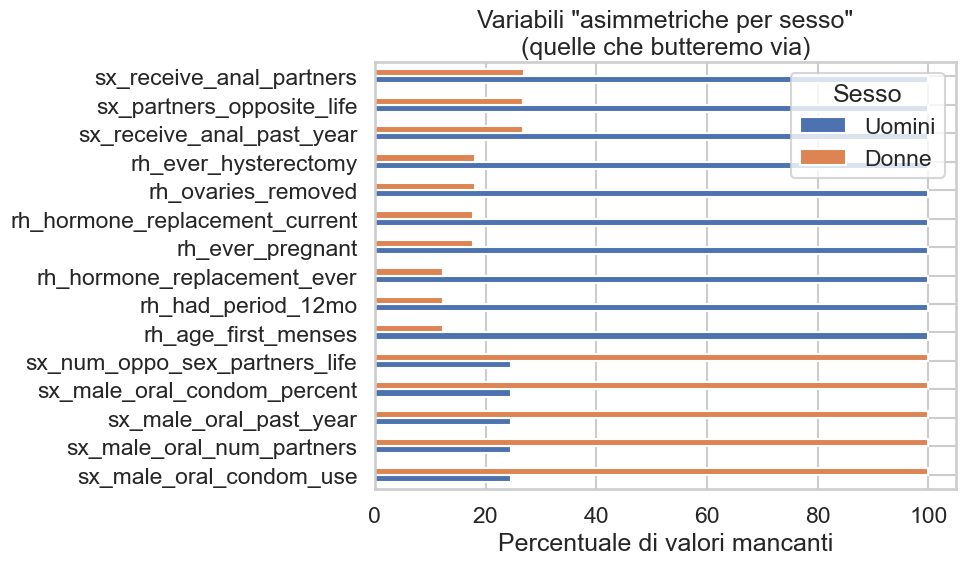

In [10]:
# Visualizziamo il pattern: la slide e' molto piu' chiara di mille parole
top_drop = (miss_M - miss_F).abs().sort_values(ascending=False).head(15).index
plot_df = pd.DataFrame({
    'Uomini': miss_M[top_drop] * 100,
    'Donne': miss_F[top_drop] * 100,
}).sort_values('Uomini', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Percentuale di valori mancanti')
ax.set_title('Variabili "asimmetriche per sesso"\n(quelle che butteremo via)')
ax.legend(title='Sesso')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preflight/missing_by_sex_top15.png', dpi=120)
plt.show()


> **Come si legge il grafico**: ogni barra è una variabile. La barra blu mostra quanti maschi non hanno quel valore, quella arancione quante femmine. Una barra blu lunga 100% significa "questa domanda non è mai stata fatta agli uomini" — quindi il solo fatto che il valore esista già rivela il sesso.


In [89]:
adult_clean = adult.drop(columns=structural_missing)
print(f'Dataset dopo la pulizia: {adult_clean.shape[0]} righe x {adult_clean.shape[1]} colonne')
print(f'(prima erano {adult.shape[1]} colonne, ne abbiamo tolte {len(structural_missing)})')


Dataset dopo la pulizia: 6113 righe x 1278 colonne
(prima erano 1812 colonne, ne abbiamo tolte 534)


### 1.5 · Costruiamo il test set fisso

Per confrontare in modo onesto i tre casi del workshop, ci serve **un unico metro di valutazione**: un campione di pazienti che **non verrà mai usato per allenare nessun modello**. È il nostro "esame finale".

Lo costruiamo con queste regole:
- **1500 persone in totale**, perfettamente bilanciato fra i sessi: **750 uomini + 750 donne**
- estratto a caso, ma con un seed fisso (`42`) per garantire **riproducibilità**: chiunque rilancerà questo notebook avrà *esattamente* lo stesso test set
- una volta costruito, **non lo tocchiamo più** fino alla valutazione

> **Perché bilanciato 50/50?** Perché vogliamo dare al modello la stessa "chance" di essere bravo sui due sessi. Se il test fosse 90% maschi, una metrica globale come l'accuracy direbbe poco sulla performance per le donne.


In [90]:
rng = np.random.default_rng(SEED)

def stratified_sample(df, stratum_col, n_per_stratum, rng):
    parts = []
    for s, g in df.groupby(stratum_col):
        idx = rng.choice(g.index, size=n_per_stratum, replace=False)
        parts.append(df.loc[idx])
    return pd.concat(parts).sort_index()

test_fixed = stratified_sample(adult_clean, 'gender', n_per_stratum=750, rng=rng)
pool_train = adult_clean.drop(index=test_fixed.index)

print(f'Test set fisso: {len(test_fixed)} persone ({(test_fixed["gender"]==1).sum()} M + {(test_fixed["gender"]==2).sum()} F)')
print(f'Pool di training: {len(pool_train)} persone ({(pool_train["gender"]==1).sum()} M + {(pool_train["gender"]==2).sum()} F)')


Test set fisso: 1500 persone (750 M + 750 F)
Pool di training: 4613 persone (2166 M + 2447 F)


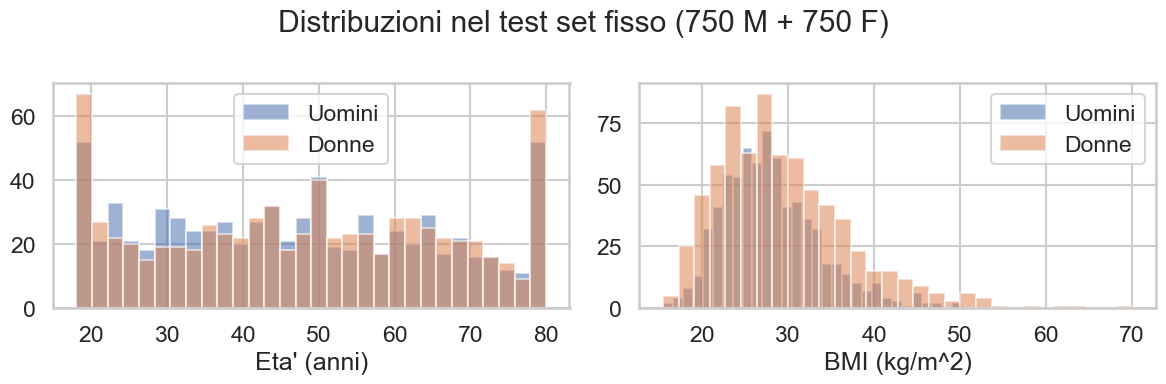

In [13]:
# Verifica veloce: eta' e BMI nel test set sono "ragionevoli", non strani
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['age_years', 'bmi'], ['Eta\' (anni)', 'BMI (kg/m^2)']):
    for g, lab, c in [(1, 'Uomini', '#4C72B0'), (2, 'Donne', '#DD8452')]:
        ax.hist(test_fixed.loc[test_fixed['gender']==g, col].dropna(),
                bins=30, alpha=0.55, label=lab, color=c)
    ax.set_xlabel(title); ax.legend()
fig.suptitle('Distribuzioni nel test set fisso (750 M + 750 F)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/preflight/test_set_distributions.png', dpi=120)
plt.show()


### 1.6 · Salviamo i dati puliti

Salviamo il pool di training, il test fisso e un piccolo log con i passaggi e le numerosità. Da qui in poi, i tre casi caricheranno questi file e non rifaranno la pulizia.


In [91]:
adult_clean.to_csv(f'{OUTPUT_DIR}/preflight/adult_clean.csv', index=False)
pool_train.to_csv(f'{OUTPUT_DIR}/preflight/pool_train.csv', index=False)
test_fixed.to_csv(f'{OUTPUT_DIR}/preflight/test_fixed.csv', index=False)

log = {
    'seed': SEED,
    'n_master': int(master.shape[0]),
    'n_cols_master': int(master.shape[1]),
    'n_adults': int(adult.shape[0]),
    'n_cols_after_drop_sex_missing': int(adult_clean.shape[1]),
    'n_dropped_sex_missing': len(structural_missing),
    'n_pool_train': int(pool_train.shape[0]),
    'n_test_fixed': int(test_fixed.shape[0]),
    'test_male': int((test_fixed['gender'] == 1).sum()),
    'test_female': int((test_fixed['gender'] == 2).sum()),
}
with open(f'{OUTPUT_DIR}/preflight/preflight_log.json', 'w') as f:
    json.dump(log, f, indent=2)

pd.Series(structural_missing, name='dropped_column').to_csv(
    f'{OUTPUT_DIR}/preflight/columns_dropped_sex_missing.csv', index=False)

print('Pre-flight completato. File salvati in:', f'{OUTPUT_DIR}/preflight/')
print()
print(json.dumps(log, indent=2))


Pre-flight completato. File salvati in: archive/preflight/

{
  "seed": 42,
  "n_master": 10175,
  "n_cols_master": 1812,
  "n_adults": 6113,
  "n_cols_after_drop_sex_missing": 1278,
  "n_dropped_sex_missing": 534,
  "n_pool_train": 4613,
  "n_test_fixed": 1500,
  "test_male": 750,
  "test_female": 750
}


**Riepilogo del pre-flight**

Da qui in poi, in ogni caso del workshop:
- partiamo dal **pool di training** (≈4.600 persone, leggermente sbilanciato verso le donne, com'è la realtà adulta NHANES)
- valutiamo sempre sul **test fisso** da 1.500 persone (750 M + 750 F)
- l'imputazione dei valori mancanti e la standardizzazione le facciamo **dentro** ogni esperimento, non qui

Ora siamo pronti per il primo caso.

---


---

## 1.7 · Una pausa: cos'è il "bootstrap" e perché lo useremo ovunque

Tra poco vedrete spuntare ovunque la parola **bootstrap**. Vale la pena spiegarla una volta per tutte, perché è il modo in cui sapremo se i risultati che otterremo sono *veri* o sono semplice rumore.

**L'idea in una frase**: invece di addestrare il modello una volta sola, lo addestriamo **molte volte** (qui 100), ogni volta con un campione di training leggermente diverso estratto dallo stesso pool. Poi guardiamo come *ballano* i risultati.

**Un'analogia**: vi consegnano una moneta e vi chiedono se è truccata. La lanciate **una sola volta** e viene testa: cosa concludete? Niente — è successo per caso. La lanciate **100 volte** e viene testa 50 volte: ok, è normale. Ma se viene testa 80 volte, *adesso* potete dire con sicurezza che è truccata. Le **100 ripetizioni** vi danno un'idea di **quanto fidarvi della stima**.

**Cosa otteniamo dal bootstrap nel nostro caso**:

| Senza bootstrap | Con bootstrap (100 ripetizioni) |
|-----------------|----------------------------------|
| "AUROC sulle donne = 0.89" | "AUROC sulle donne = 0.89, intervallo [0.87, 0.91]" |
| Non so se rifittando otterrei 0.85 o 0.93 | So che il valore "vero" è dentro quella finestra al 95% |
| Non posso confrontare due numeri in modo onesto | Se due intervalli **non si toccano**, posso dire che la differenza è reale |

> Quando nei prossimi grafici vedrete "bande" attorno a una curva, o "barre di errore" attorno a una colonna, sono gli **intervalli di confidenza al 95%** prodotti dal bootstrap: il "respiro" della stima.

Tutto questo costa tempo (ogni esperimento si moltiplica per 100), ma è quello che separa una conclusione affrettata da una conclusione difendibile.

---


## 2 · Caso 1 — Bias di numerosità del genere

> **La domanda di ricerca**
> *A parità di tutto il resto, il solo fatto di cambiare il rapporto donne/uomini nel training set sposta in modo misurabile le predizioni del modello?*

È l'esperimento più semplice di questa analisi, ed è una **palestra concettuale** per i casi più complessi che seguono. Non manipoliamo niente di sottile: cambiamo solo **quante donne** mettiamo nel training, lasciando intatto tutto il resto.

### Gli scenari

Costruiamo quattro versioni del training set, sempre con **la stessa quantità totale di dati (3.000 persone)**, ma con rapporti F:M progressivamente sbilanciati:

| Scenario | Donne | Uomini | Quota donne |
|----------|-------|--------|-------------|
| **S0** | 1500 | 1500 | 50% (baseline equilibrata) |
| **S1** |  900 | 2100 | 30% |
| **S2** |  450 | 2550 | 15% |
| **S3** |  150 | 2850 |  5% |

> **Perché tenere fisso il totale a 3000?** Per non mescolare due effetti diversi: "ho meno donne" e "ho meno dati in totale". Se fissiamo la quantità totale, l'unica cosa che cambia è il **rapporto** fra i sessi.

Tutti e quattro gli scenari verranno valutati **sullo stesso test fisso** (750 M + 750 F) costruito nel pre-flight.

In [92]:
# --- Configurazione scenari del Caso 1 -----------------------------------
SCENARIOS = {
    'S0_50-50': dict(n_F=1500, n_M=1500),
    'S1_30-70': dict(n_F= 900, n_M=2100),
    'S2_15-85': dict(n_F= 450, n_M=2550),
    'S3_5-95':  dict(n_F= 150, n_M=2850),
}

def make_scenario(pool, n_F, n_M, rng):
    """Estrae un training set con i numeri richiesti di F e M dal pool.

    Usa campionamento *con sostituzione* (bootstrap): permette di chiedere piu' unita'
    di quante ne abbia il pool e introduce variabilita' fra le ripetizioni.
    """
    pool_M = pool[pool['gender'] == 1]
    pool_F = pool[pool['gender'] == 2]
    if len(pool_M) == 0 or len(pool_F) == 0:
        raise ValueError('Pool vuoto in uno dei due sessi: controlla i filtri.')
    idx_M = rng.choice(pool_M.index, size=n_M, replace=True)
    idx_F = rng.choice(pool_F.index, size=n_F, replace=True)
    return pool.loc[list(idx_M) + list(idx_F)].sample(frac=1, random_state=int(rng.integers(1e9)))

# Verifica veloce che il pool abbia abbastanza persone (deve avere >=2850 M e >=1500 F)
print('Persone disponibili nel pool:',
      f'M={ (pool_train["gender"]==1).sum() },',
      f'F={ (pool_train["gender"]==2).sum() }')
print('Massimo richiesto da S3: M=2850, da S0: F=1500. Capienza OK.')


Persone disponibili nel pool: M=2166, F=2447
Massimo richiesto da S3: M=2850, da S0: F=1500. Capienza OK.


---

### 2A · Opzione 1A — Regressione lineare sulla pressione sistolica

> **L'esperimento**
> Predire la **pressione arteriosa sistolica** (`bp_systolic_1`, in mmHg) usando solo due variabili: il **BMI** e l'**età**. Confrontare cosa cambia nei coefficienti del modello al variare degli scenari.

Perché iniziamo da qui? Perché la regressione lineare è il modello più semplice e trasparente che esista: produce una formula del tipo

```
pressione = intercetta + (peso_BMI × BMI) + (peso_età × età)
```

Quei "pesi" (chiamati anche **coefficienti** o, in 2D, **slope/pendenza**) ci dicono *quanta pressione si aggiunge per ogni unità di BMI*. Sono numeri leggibili. Se cambiano fra scenari, vediamo subito di quanto.

> **Per chi non programma**: pensate alla regressione come a una "ricetta" che il computer trova guardando i dati. La forma della ricetta è fissa (`a + b·BMI + c·età`), ma i numeri `a, b, c` vengono scelti automaticamente per minimizzare gli errori di previsione.

#### Cosa misuriamo

Per ogni scenario calcoliamo:
- **slope BMI**, **slope età**, **intercetta** del modello
- l'**errore medio** (MAE, mean absolute error): di quanti mmHg sbaglia il modello in media. Lo calcoliamo separatamente sulle donne, sugli uomini, e globalmente.

Faremo tutto questo **100 volte** (il numero `N_BOOTSTRAP` settato all'inizio), ricampionando ogni volta il training: questo ci dà un'idea di **quanto i risultati sono stabili o ballerini**.


In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Variabili dell'opzione 1A
TARGET_1A = 'bp_systolic_1'
FEATURES_1A = ['bmi', 'age_years']

# Filtriamo righe con target e feature non mancanti (la regressione non sa che farsene dei NaN)
def prep_1a(df):
    return df.dropna(subset=[TARGET_1A] + FEATURES_1A).copy()

pool_1a = prep_1a(pool_train)
test_1a = prep_1a(test_fixed)
print(f'Pool utile per 1A: {len(pool_1a)} (di cui {(pool_1a["gender"]==2).sum()} F, {(pool_1a["gender"]==1).sum()} M)')
print(f'Test utile per 1A: {len(test_1a)} (di cui {(test_1a["gender"]==2).sum()} F, {(test_1a["gender"]==1).sum()} M)')


Pool utile per 1A: 4069 (di cui 2127 F, 1942 M)
Test utile per 1A: 1298 (di cui 639 F, 659 M)


In [94]:
def fit_eval_1a(train, test):
    """Fit OLS su train, valuta su test stratificato per sesso."""
    model = LinearRegression()
    model.fit(train[FEATURES_1A], train[TARGET_1A])
    pred = model.predict(test[FEATURES_1A])

    res = {
        'slope_bmi': model.coef_[0],
        'slope_age': model.coef_[1],
        'intercept': model.intercept_,
        'mae_global': mean_absolute_error(test[TARGET_1A], pred),
    }
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = test['gender'] == g
        res[f'mae_{lab}'] = mean_absolute_error(test.loc[m, TARGET_1A], pred[m])
    return res, model

# Bootstrap: per ogni scenario, ripetiamo N_BOOTSTRAP volte con seed diverso
rng = np.random.default_rng(SEED)
records_1a = []
for sname, cfg in SCENARIOS.items():
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 1000*b + hash(sname) % 1000)
        train_b = make_scenario(pool_1a, cfg['n_F'], cfg['n_M'], rng_b)
        res, _ = fit_eval_1a(train_b, test_1a)
        res['scenario'] = sname
        res['boot'] = b
        records_1a.append(res)

results_1a = pd.DataFrame(records_1a)
print(f'Esperimenti totali completati: {len(results_1a)} (= {len(SCENARIOS)} scenari x {N_BOOTSTRAP} ripetizioni)')


Esperimenti totali completati: 400 (= 4 scenari x 100 ripetizioni)


#### Risultati riassunti

Calcoliamo media e intervallo di confidenza al 95% (i percentili 2.5° e 97.5°) di ogni metrica, separatamente per scenario.


In [95]:
def fmt_ci(s):
    return f'{s.mean():.2f} [{s.quantile(0.025):.2f}, {s.quantile(0.975):.2f}]'

summary_1a = results_1a.groupby('scenario').agg({
    'slope_bmi': fmt_ci,
    'slope_age': fmt_ci,
    'intercept': fmt_ci,
    'mae_global': fmt_ci,
    'mae_F': fmt_ci,
    'mae_M': fmt_ci,
})
summary_1a


,slope_bmi,slope_age,intercept,mae_global,mae_F,mae_M
scenario,,,,,,
S0_50-50,"0.24 [0.15, 0.31]","0.44 [0.40, 0.47]","94.75 [92.60, 97.21]","11.75 [11.71, 11.80]","11.71 [11.65, 11.82]","11.78 [11.71, 11.85]"
S1_30-70,"0.22 [0.13, 0.30]","0.40 [0.37, 0.43]","98.19 [96.16, 100.71]","11.80 [11.76, 11.85]","11.98 [11.87, 12.07]","11.63 [11.58, 11.69]"
S2_15-85,"0.23 [0.14, 0.31]","0.36 [0.33, 0.39]","100.36 [97.76, 102.88]","11.91 [11.83, 11.99]","12.25 [12.10, 12.40]","11.58 [11.56, 11.62]"
S3_5-95,"0.23 [0.16, 0.33]","0.34 [0.31, 0.37]","101.91 [99.09, 104.39]","12.01 [11.94, 12.10]","12.46 [12.32, 12.62]","11.58 [11.56, 11.61]"


> **Come leggere la tabella**: per ogni scenario e ogni metrica, il numero principale è la media sui 100 esperimenti, e fra parentesi quadre c'è l'intervallo di confidenza al 95% — cioè la finestra dentro cui il valore "vero" cade con alta probabilità.
>
> Guardate in particolare le ultime due colonne (`mae_F` e `mae_M`): vedrete che mentre l'errore sugli uomini resta abbastanza piatto fra gli scenari, l'errore sulle donne **cresce** man mano che le donne sono meno nel training. Il modello "ascolta meno" le donne e **paga sulle donne**.


#### Confermiamo formalmente con un test statistico

La tabella ci dice che, scendendo dallo scenario S0 allo scenario S3, l'errore medio sulle donne **cresce** mentre quello sugli uomini resta stabile. Ma questa differenza è **statisticamente significativa** o potrebbe essere casuale?

Per rispondere usiamo un **t-test pareato** (richiesto esplicitamente dalla relazione, sezione Caso 1A): per ogni paziente del test set calcoliamo l'errore assoluto del modello S0 e quello del modello S3, e confrontiamo le due serie **separatamente per sesso**.

> **Cos'è un t-test pareato in parole semplici**: confronta due misure fatte **sugli stessi soggetti** in due condizioni diverse (qui: stesso paziente, due modelli diversi). Restituisce un valore `p`: se `p < 0.05` consideriamo l'effetto **non casuale**.

Aspettative: per le **donne** il `p` deve essere piccolo (l'errore peggiora davvero quando il training perde donne); per gli **uomini** il `p` non deve essere significativo (loro non sono toccati dal cambio di rapporto).

In [102]:
from scipy.stats import ttest_rel

# We refit a single representative model for S0 and S3 (fixed seed),
# then compute per-patient absolute errors and run a paired t-test stratified by sex.
rng_s0 = np.random.default_rng(SEED)
rng_s3 = np.random.default_rng(SEED + 999)

train_s0 = make_scenario(pool_1a, SCENARIOS['S0_50-50']['n_F'], SCENARIOS['S0_50-50']['n_M'], rng_s0)
train_s3 = make_scenario(pool_1a, SCENARIOS['S3_5-95']['n_F'],  SCENARIOS['S3_5-95']['n_M'],  rng_s3)

model_s0 = LinearRegression().fit(train_s0[FEATURES_1A], train_s0[TARGET_1A])
model_s3 = LinearRegression().fit(train_s3[FEATURES_1A], train_s3[TARGET_1A])

y_true     = test_1a[TARGET_1A].values
abs_err_s0 = np.abs(y_true - model_s0.predict(test_1a[FEATURES_1A]))
abs_err_s3 = np.abs(y_true - model_s3.predict(test_1a[FEATURES_1A]))

is_female = (test_1a['gender'] == 2).values
is_male   = (test_1a['gender'] == 1).values

t_female, p_female = ttest_rel(abs_err_s0[is_female], abs_err_s3[is_female])
t_male,   p_male   = ttest_rel(abs_err_s0[is_male],   abs_err_s3[is_male])

ttest_1a = pd.DataFrame([
    {'sex': 'Donne',  'n_test': int(is_female.sum()),
     'mae_S0': abs_err_s0[is_female].mean(), 'mae_S3': abs_err_s3[is_female].mean(),
     'delta_mae_S3_minus_S0': abs_err_s3[is_female].mean() - abs_err_s0[is_female].mean(),
     't_statistic': t_female, 'p_value': p_female},
    {'sex': 'Uomini', 'n_test': int(is_male.sum()),
     'mae_S0': abs_err_s0[is_male].mean(),   'mae_S3': abs_err_s3[is_male].mean(),
     'delta_mae_S3_minus_S0': abs_err_s3[is_male].mean() - abs_err_s0[is_male].mean(),
     't_statistic': t_male,   'p_value': p_male},
])
ttest_1a.to_csv(f'{OUTPUT_DIR}/case1/1A_ttest_paired_residuals.csv', index=False)
print('[OK] Saved archive/case1/1A_ttest_paired_residuals.csv')
ttest_1a.style.format({'mae_S0': '{:.2f}', 'mae_S3': '{:.2f}',
                       'delta_mae_S3_minus_S0': '{:+.2f}',
                       't_statistic': '{:+.2f}', 'p_value': '{:.4g}'})

[OK] Saved archive/case1/1A_ttest_paired_residuals.csv


,sex,n_test,mae_S0,mae_S3,delta_mae_S3_minus_S0,t_statistic,p_value
0,Donne,639,11.72,12.47,+0.74,-7.87,1.567e-14
1,Uomini,659,11.78,11.59,-0.19,+1.87,0.06155


> **Come leggere il risultato**: la riga **Donne** mostra di quanto cresce l'errore medio passando dallo scenario equilibrato (S0) a quello quasi-solo-maschi (S3) — la colonna `delta_mae_S3_minus_S0` è positiva. Il `p_value` ci dice se questo aumento è statisticamente robusto: un valore molto piccolo (es. `< 0.001`) significa che il peggioramento sulle donne **non è casuale**, è strutturale.
> 
> La riga **Uomini** dovrebbe invece mostrare un `delta` vicino a zero (o addirittura negativo, perché il modello "impara meglio" sugli uomini quando ci sono solo loro nel training) e un `p_value` non significativo. Questo è il pattern asimmetrico del bias di numerosità: **il rapporto M/F nel training peggiora le previsioni solo per il sesso minoritario**.

#### Visualizzazione chiave: come si sposta la retta del modello

Mettiamo insieme il messaggio del Caso 1A in un'unica visualizzazione. Sull'asse x il BMI, sull'asse y la pressione sistolica. Sovrapponiamo:
- i punti del test (grigi sullo sfondo, separati per sesso)
- una **retta per ogni scenario**, ottenuta dal modello "medio" di quello scenario, fissando l'età al valore medio del test

Le rette **ruotano progressivamente** man mano che le donne escono dal training: dal blu (S0, equilibrato) al rosso (S3, quasi tutti uomini). L'animazione viene salvata su disco come GIF (`archive/case1/1A_lines_animation.gif`); subito dopo presentiamo anche una versione statica con tutte le 4 rette nello stesso frame.

Animazione salvata: archive/case1/1A_lines_animation.gif


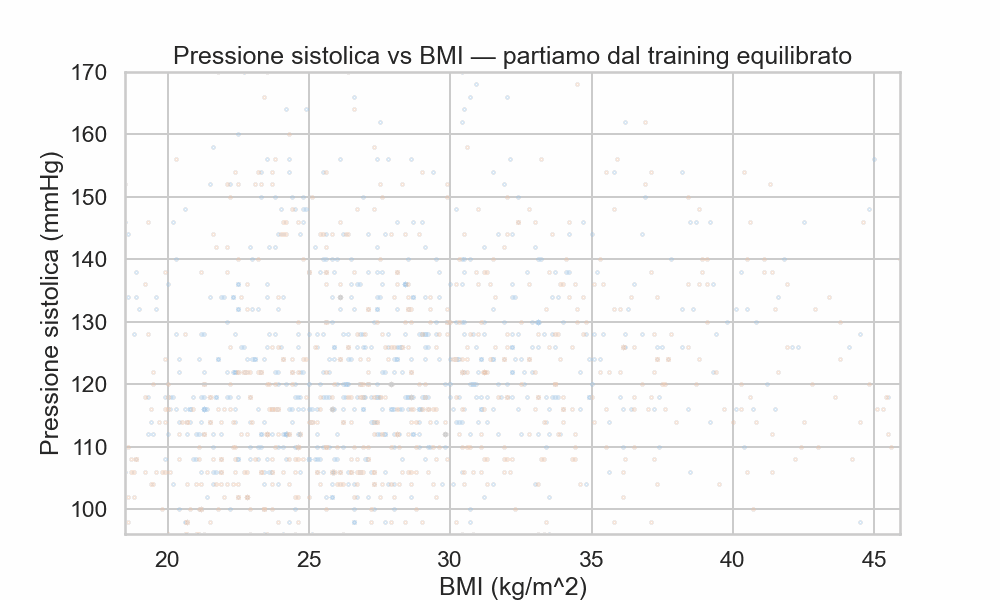

In [103]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPyImage

# --- Variabili dell'animazione (calcolate qui, cella self-contained) -----
mean_params_1a = results_1a.groupby('scenario')[['slope_bmi','slope_age','intercept']].mean()
age_mean_test  = test_1a['age_years'].mean()
bmi_grid       = np.linspace(test_1a['bmi'].quantile(0.02),
                             test_1a['bmi'].quantile(0.98), 100)
scenario_list  = list(mean_params_1a.index)

# Palette locale (lista, indicizzabile per intero) — non riusa variabili globali
anim_palette = ['#2166ac', '#92c5de', '#f4a582', '#b2182b']  # blue -> red (aligned with static plot)

# --- Setup figura -------------------------------------------------------
fig_a, ax_a = plt.subplots(figsize=(10, 6))
for g, lab, c in [(1, 'Uomini (test)', '#9ec5e8'), (2, 'Donne (test)', '#f4c4a4')]:
    sub = test_1a[test_1a['gender'] == g]
    ax_a.scatter(sub['bmi'], sub[TARGET_1A], s=8, alpha=0.25, c=c, label=lab)
ax_a.set_xlabel('BMI (kg/m^2)')
ax_a.set_ylabel('Pressione sistolica (mmHg)')
ax_a.set_xlim(bmi_grid.min(), bmi_grid.max())
ax_a.set_ylim(test_1a[TARGET_1A].quantile(0.02), test_1a[TARGET_1A].quantile(0.98))

animated_lines = []
def init():
    ax_a.set_title('Pressione sistolica vs BMI — partiamo dal training equilibrato')
    return []

def update(frame):
    if frame == 0:
        ax_a.set_title('Pressione sistolica vs BMI — partiamo dal training equilibrato')
        return animated_lines
    sname  = scenario_list[frame - 1]
    color  = anim_palette[frame - 1]
    params = mean_params_1a.loc[sname]
    y_line = params['intercept'] + params['slope_bmi']*bmi_grid + params['slope_age']*age_mean_test
    line, = ax_a.plot(bmi_grid, y_line, color=color, linewidth=3, label=f'Modello {sname}')
    animated_lines.append(line)
    ax_a.legend(loc='upper left', fontsize=10)
    ax_a.set_title(f'Caso 1A — Aggiungiamo lo scenario {sname} ({frame}/{len(scenario_list)})')
    return animated_lines

ani = FuncAnimation(fig_a, update, frames=len(scenario_list) + 1,
                    init_func=init, blit=False, interval=1200, repeat_delay=2000)

gif_path = f'{OUTPUT_DIR}/case1/1A_lines_animation.gif'
ani.save(gif_path, writer=PillowWriter(fps=1))
plt.close(fig_a)
print(f'Animazione salvata: {gif_path}')
IPyImage(gif_path)


#### Versione statica: le 4 rette nello stesso grafico

La GIF qui sopra è perfetta per la presentazione live. Quando però condividiamo il notebook (in PDF, su GitHub, o stampato) l'animazione si perde: chi guarda vede solo l'ultimo frame. Per questo affianchiamo una **versione statica** in cui le 4 rette compaiono **tutte insieme** nello stesso grafico, con una palette **dal blu (S0, equilibrato) al rosso (S3, quasi tutti uomini)** che permette di apprezzare a colpo d'occhio la **rotazione progressiva** richiesta dalla relazione.

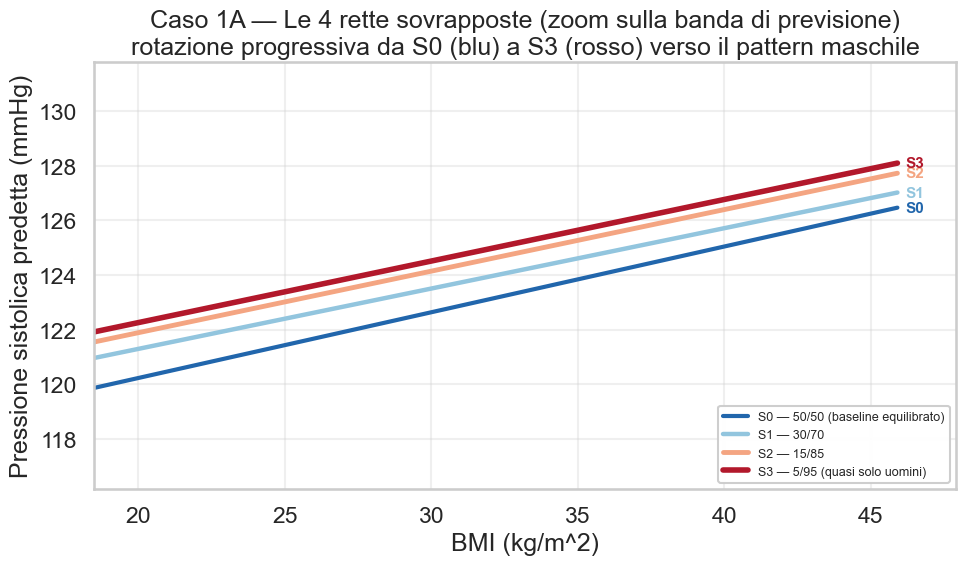

[OK] Saved archive/case1/1A_lines_static.png


In [104]:
# Static version of the 4-lines plot — zoomed on the regression band so the rotation is clearly visible.
# Color palette: blue -> red (RdBu), aligned with the GIF.
static_palette = ['#2166ac', '#92c5de', '#f4a582', '#b2182b']  # S0 -> S3
static_linewidths = [3.0, 3.2, 3.5, 4.0]
scenario_labels = {
    'S0_50-50': 'S0 — 50/50 (baseline equilibrato)',
    'S1_30-70': 'S1 — 30/70',
    'S2_15-85': 'S2 — 15/85',
    'S3_5-95':  'S3 — 5/95 (quasi solo uomini)',
}

# Pre-compute the 4 lines so we can derive a tight y-axis around them
lines_y = []
for scenario_name in scenario_list:
    params = mean_params_1a.loc[scenario_name]
    y_line = params['intercept'] + params['slope_bmi'] * bmi_grid + params['slope_age'] * age_mean_test
    lines_y.append(y_line)

y_min_lines = min(y.min() for y in lines_y)
y_max_lines = max(y.max() for y in lines_y)
y_margin    = max((y_max_lines - y_min_lines) * 0.45, 1.0)  # ~45% of the spread, min 1 mmHg

fig_static, ax_static = plt.subplots(figsize=(10, 6))

for scenario_name, color, lw, y_line in zip(scenario_list, static_palette, static_linewidths, lines_y):
    ax_static.plot(bmi_grid, y_line, color=color, linewidth=lw,
                   label=scenario_labels[scenario_name])
    # End-of-line label so each scenario is identifiable without reading the legend
    ax_static.annotate(scenario_name.split('_')[0],
                       xy=(bmi_grid[-1], y_line[-1]),
                       xytext=(6, 0), textcoords='offset points',
                       color=color, fontweight='bold', fontsize=11, va='center')

ax_static.set_xlim(bmi_grid.min(), bmi_grid.max() + 2)
ax_static.set_ylim(y_min_lines - y_margin, y_max_lines + y_margin)
ax_static.set_xlabel('BMI (kg/m^2)')
ax_static.set_ylabel('Pressione sistolica predetta (mmHg)')
ax_static.set_title("Caso 1A — Le 4 rette sovrapposte (zoom sulla banda di previsione)\n"
                    "rotazione progressiva da S0 (blu) a S3 (rosso) verso il pattern maschile")
ax_static.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax_static.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1A_lines_static.png', dpi=130, bbox_inches='tight')
plt.show()
print('[OK] Saved archive/case1/1A_lines_static.png')

#### Il grafico dei pentimenti: errore per sesso

Trasferiamo i numeri della tabella in un grafico più leggibile: sull'asse x i 4 scenari, sull'asse y l'errore medio di previsione. Una linea per le donne, una per gli uomini.


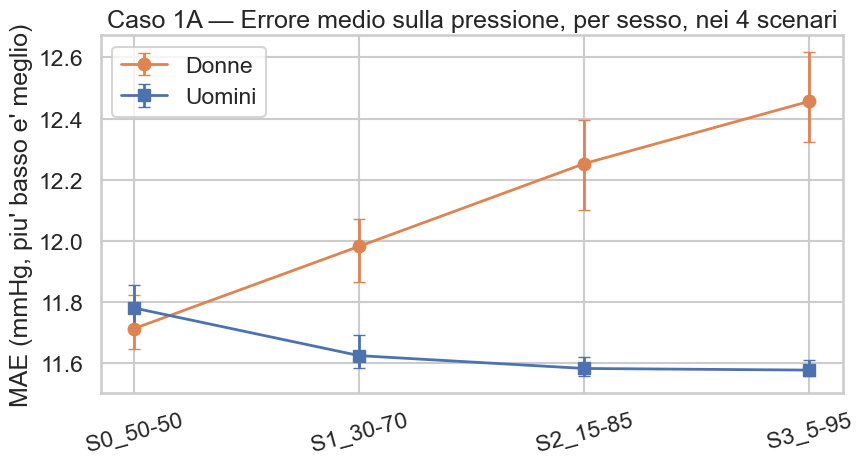

In [100]:
mae_summary = results_1a.groupby('scenario').agg(
    mae_F_mean=('mae_F', 'mean'),
    mae_F_lo  =('mae_F', lambda s: s.quantile(0.025)),
    mae_F_hi  =('mae_F', lambda s: s.quantile(0.975)),
    mae_M_mean=('mae_M', 'mean'),
    mae_M_lo  =('mae_M', lambda s: s.quantile(0.025)),
    mae_M_hi  =('mae_M', lambda s: s.quantile(0.975)),
).reindex(list(SCENARIOS))

x = np.arange(len(mae_summary))
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(x, mae_summary['mae_F_mean'],
            yerr=[mae_summary['mae_F_mean']-mae_summary['mae_F_lo'],
                  mae_summary['mae_F_hi']-mae_summary['mae_F_mean']],
            marker='o', label='Donne', color='#DD8452', linewidth=2, capsize=4)
ax.errorbar(x, mae_summary['mae_M_mean'],
            yerr=[mae_summary['mae_M_mean']-mae_summary['mae_M_lo'],
                  mae_summary['mae_M_hi']-mae_summary['mae_M_mean']],
            marker='s', label='Uomini', color='#4C72B0', linewidth=2, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(mae_summary.index, rotation=15)
ax.set_ylabel('MAE (mmHg, piu\' basso e\' meglio)')
ax.set_title('Caso 1A — Errore medio sulla pressione, per sesso, nei 4 scenari')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1A_mae_by_sex.png', dpi=120)
plt.show()


In [101]:
results_1a.to_csv(f'{OUTPUT_DIR}/case1/1A_bootstrap_records.csv', index=False)
summary_1a.to_csv(f'{OUTPUT_DIR}/case1/1A_summary.csv')


**Conclusione del Caso 1A**: *abbiamo cambiato solo il numero di donne nel training. Nient'altro. Il modello non è più lo stesso, e le donne sono quelle che pagano l'errore predittivo più alto.*

---

### 2B · Opzione 1B — Regressione logistica sul diabete

Adesso facciamo lo stesso esperimento ma su un problema **clinicamente più rilevante**: prevedere se una persona ha il diabete (`diab_doctor_told_diabetes`, sì/no, prevalenza ~12% fra gli adulti).

Cambiano due cose rispetto a 1A:

1. **Il target è binario** (sì/no), quindi usiamo una **regressione logistica** invece di una lineare. Concettualmente è la stessa idea — pesi sommati su una combinazione di feature — ma l'output è una **probabilità** fra 0 e 1.

2. **Le feature sono molte**: invece di 2, ne usiamo le **30 più correlate col target**. Questo perché il diabete dipende da tanti fattori (BMI, età, glicemia, colesterolo, etc.) e un modello con 2 sole variabili sarebbe troppo povero.

> **AUROC** è la metrica che useremo per valutare il modello. Va da `0.5` (modello che tira a indovinare) a `1.0` (modello perfetto). In termini intuitivi misura: *prendendo a caso un malato e un sano, qual è la probabilità che il modello dia un punteggio più alto al malato che al sano?*. Un modello con AUROC=0.85 ci riesce 85 volte su 100.

#### Selezione delle feature

Selezioniamo le top-30 feature per **valore assoluto della correlazione** col target, **escludendo** le proxy esplicite del sesso (`gender`, `hh_ref_gender`, ecc.) — altrimenti il modello "imparerebbe" il sesso direttamente, e non saprebbe più distinguere "bias da numerosità" da "bias da informazione".


In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, confusion_matrix

# Funzione helper: metriche complete per un sottogruppo (a soglia 0.5)
def subgroup_metrics(y_true, proba, threshold=0.5):
    """Restituisce sensitivity (TPR), 1-specificity (FPR), precision (PPV), Brier."""
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'tpr':   tp / (tp + fn) if (tp + fn) else np.nan,   # sensitivity
        'fpr':   fp / (fp + tn) if (fp + tn) else np.nan,   # 1-specificity
        'ppv':   tp / (tp + fp) if (tp + fp) else np.nan,   # precision (valore predittivo positivo)
        'brier': brier_score_loss(y_true, proba),            # qualita\' della calibrazione probabilistica
    }

TARGET_1B = 'diab_doctor_told_diabetes'

# Feature candidate: numeriche, missing < 50%, escluse proxy del sesso
def select_top_features(pool, target, k=30):
    excl_keywords = ['gender', 'sex_', '_sex']
    excl = {target}
    for kw in excl_keywords:
        excl.update(c for c in pool.columns if kw in c.lower())

    numeric = pool.select_dtypes(include=[np.number]).columns
    candidates = [c for c in numeric
                  if c not in excl and pool[c].isna().mean() < 0.5]
    # Pearson corr assoluta con il target (su righe non-NA)
    y = pool[target]
    corrs = {}
    for c in candidates:
        sub = pool[[c, target]].dropna()
        if len(sub) > 30 and sub[c].std() > 0:
            corrs[c] = abs(sub[c].corr(sub[target]))
    return sorted(corrs, key=corrs.get, reverse=True)[:k], corrs

features_1b, corrs_1b = select_top_features(pool_train, TARGET_1B, k=30)
print(f'Selezionate {len(features_1b)} feature per 1B (corr con `{TARGET_1B}`).')
print(f'Tutte e {len(features_1b)} verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita\':')
for f in features_1b[:10]:
    print(f'  {f:40s}  |corr| = {corrs_1b[f]:.3f}')
print(f'  ... + altre {len(features_1b)-10} feature.')


Selezionate 30 feature per 1B (corr con `diab_doctor_told_diabetes`).
Tutte e 30 verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita':
  hba1c_pct                                 |corr| = 0.630
  bp_told_to_take_chol_meds                 |corr| = 0.329
  mc_told_reduce_fat_past_12mo              |corr| = 0.316
  gen_health_cond                           |corr| = 0.237
  bp_chol_told_high_time                    |corr| = 0.145
  cs_reduced_enjoyment_food                 |corr| = 0.133
  cs_head_injury_knocked_out                |corr| = 0.076
  bp_chol_ever_high                         |corr| = 0.075
  cv_chest_pain_ever                        |corr| = 0.070
  cs_hit_head_past_12mo                     |corr| = 0.064
  ... + altre 20 feature.


In [106]:
def prep_xy(df, features, target):
    sub = df.dropna(subset=[target]).copy()
    return sub[features], sub[target].astype(int), sub['gender']

def fit_eval_1b(train, test, features, target):
    """Pipeline corretta: imputa+standardizza solo sul TRAIN, applica al TEST."""
    X_tr, y_tr, _ = prep_xy(train, features, target)
    X_te, y_te, g_te = prep_xy(test, features, target)

    imputer = SimpleImputer(strategy='median').fit(X_tr)
    X_tr_i = imputer.transform(X_tr)
    X_te_i = imputer.transform(X_te)
    scaler = StandardScaler().fit(X_tr_i)
    X_tr_s = scaler.transform(X_tr_i)
    X_te_s = scaler.transform(X_te_i)

    model = LogisticRegression(C=1.0, penalty='l2', max_iter=1000, solver='lbfgs')
    model.fit(X_tr_s, y_tr)
    proba = model.predict_proba(X_te_s)[:, 1]

    res = {'auroc_global': roc_auc_score(y_te, proba)}
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = (g_te == g).values
        res[f'auroc_{lab}'] = roc_auc_score(y_te[m], proba[m])
        sm = subgroup_metrics(y_te.values[m], proba[m])
        for k, v in sm.items():
            res[f'{k}_{lab}'] = v
    return res, proba, y_te.values, g_te.values

# Una pre-run senza bootstrap, scenario per scenario, per i grafici
rng = np.random.default_rng(SEED)
single_run_1b = {}
for sname, cfg in SCENARIOS.items():
    train = make_scenario(pool_train.dropna(subset=[TARGET_1B]), cfg['n_F'], cfg['n_M'], rng)
    res, proba, y, g = fit_eval_1b(train, test_fixed, features_1b, TARGET_1B)
    single_run_1b[sname] = {'res': res, 'proba': proba, 'y': y, 'g': g}
    print(f'{sname}: AUROC global={res["auroc_global"]:.3f}  F={res["auroc_F"]:.3f}  M={res["auroc_M"]:.3f}')


S0_50-50: AUROC global=0.911  F=0.902  M=0.919
S1_30-70: AUROC global=0.917  F=0.911  M=0.921
S2_15-85: AUROC global=0.910  F=0.896  M=0.924
S3_5-95: AUROC global=0.907  F=0.904  M=0.909


In [107]:
# Bootstrap per intervalli di confidenza
records_1b = []
rng = np.random.default_rng(SEED)
for sname, cfg in SCENARIOS.items():
    pool_b = pool_train.dropna(subset=[TARGET_1B])
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 1000*b + hash(sname) % 1000)
        train_b = make_scenario(pool_b, cfg['n_F'], cfg['n_M'], rng_b)
        res, *_ = fit_eval_1b(train_b, test_fixed, features_1b, TARGET_1B)
        res['scenario'] = sname; res['boot'] = b
        records_1b.append(res)
results_1b = pd.DataFrame(records_1b)
print(f'Bootstrap 1B completato: {len(results_1b)} fit totali.')


Bootstrap 1B completato: 400 fit totali.


#### Curve ROC stratificate per sesso

Mostriamo le curve ROC nei 4 scenari, tenendole separate per sesso. Sull'asse x c'è il **falso positivo** (sani classificati come malati), sull'asse y il **vero positivo** (malati identificati correttamente). Più la curva sale verso l'angolo in alto a sinistra, meglio è.

Ci aspettiamo: le curve degli uomini restano quasi sovrapposte fra scenari (il modello "vede sempre lo stesso campione di uomini"); le curve delle donne, invece, si abbassano progressivamente da S0 a S3.


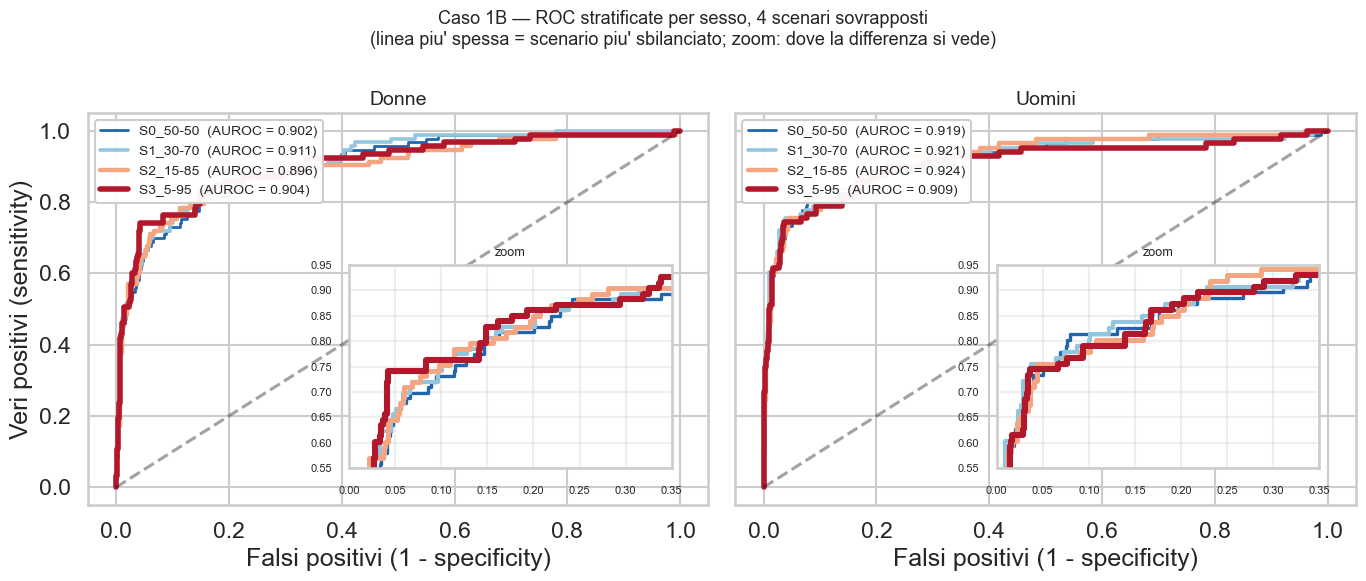

In [113]:
# Stile ROC migliorato: colori contrastati, linewidth crescente da S0 a S3,
# inset zoom sull'area "in alto a sinistra" dove le curve si separano davvero.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scenario_styles = {
    # (color, linewidth, linestyle) — palette blue->red, aligned with the 1A GIF/static plot
    'S0_50-50': ('#2166ac', 2.0, '-'),    # blu intenso — baseline equilibrato
    'S1_30-70': ('#92c5de', 2.6, '-'),    # azzurro chiaro
    'S2_15-85': ('#f4a582', 3.2, '-'),    # arancio chiaro
    'S3_5-95':  ('#b2182b', 4.0, '-'),    # rosso intenso — quasi solo uomini
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, sex_code, sex_name in [(axes[0], 2, 'Donne'), (axes[1], 1, 'Uomini')]:
    inset = inset_axes(ax, width='52%', height='52%', loc='lower right',
                       borderpad=1.6)
    for sname, info in single_run_1b.items():
        col, lw, ls = scenario_styles[sname]
        m = info['g'] == sex_code
        fpr, tpr, _ = roc_curve(info['y'][m], info['proba'][m])
        auc = info['res'][f'auroc_{"F" if sex_code==2 else "M"}']
        ax.plot(fpr, tpr, color=col, linewidth=lw, linestyle=ls,
                label=f'{sname}  (AUROC = {auc:.3f})')
        inset.plot(fpr, tpr, color=col, linewidth=lw+0.4, linestyle=ls)
    ax.plot([0,1], [0,1], 'k--', alpha=0.4)
    ax.set_xlabel('Falsi positivi (1 - specificity)')
    ax.set_title(sex_name, fontsize=14)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    # Zoom inset: ingrandisce la zona dove le 4 curve si separano
    inset.set_xlim(0.0, 0.35)
    inset.set_ylim(0.55, 0.95)
    inset.set_title('zoom', fontsize=9)
    inset.tick_params(labelsize=8)
    inset.grid(True, alpha=0.3)

axes[0].set_ylabel('Veri positivi (sensitivity)')
fig.suptitle('Caso 1B — ROC stratificate per sesso, 4 scenari sovrapposti\n(linea piu\' spessa = scenario piu\' sbilanciato; zoom: dove la differenza si vede)',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1B_roc_by_sex_scenario.png', dpi=130, bbox_inches='tight')
plt.show()


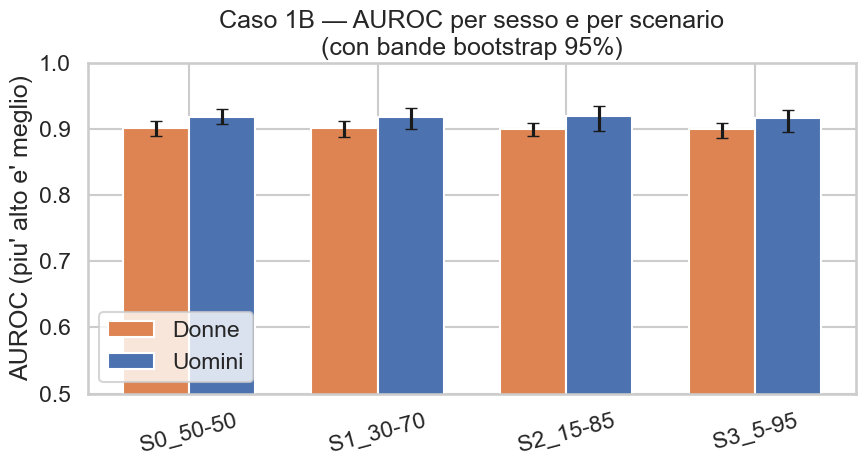


Gap M - F (positivo = svantaggio per le donne):
          gap_M_minus_F
scenario               
S0_50-50       0.016427
S1_30-70       0.016751
S2_15-85       0.019293
S3_5-95        0.017288


In [109]:
auroc_summary = results_1b.groupby('scenario').agg(
    F_mean=('auroc_F','mean'), F_lo=('auroc_F', lambda s: s.quantile(0.025)),
    F_hi=('auroc_F', lambda s: s.quantile(0.975)),
    M_mean=('auroc_M','mean'), M_lo=('auroc_M', lambda s: s.quantile(0.025)),
    M_hi=('auroc_M', lambda s: s.quantile(0.975)),
).reindex(list(SCENARIOS))
auroc_summary['gap_M_minus_F'] = auroc_summary['M_mean'] - auroc_summary['F_mean']

x = np.arange(len(auroc_summary)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, auroc_summary['F_mean'], w, color='#DD8452', label='Donne',
       yerr=[auroc_summary['F_mean']-auroc_summary['F_lo'],
             auroc_summary['F_hi']-auroc_summary['F_mean']], capsize=4)
ax.bar(x + w/2, auroc_summary['M_mean'], w, color='#4C72B0', label='Uomini',
       yerr=[auroc_summary['M_mean']-auroc_summary['M_lo'],
             auroc_summary['M_hi']-auroc_summary['M_mean']], capsize=4)
ax.set_xticks(x); ax.set_xticklabels(auroc_summary.index, rotation=15)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUROC (piu\' alto e\' meglio)')
ax.set_title('Caso 1B — AUROC per sesso e per scenario\n(con bande bootstrap 95%)')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1B_auroc_bars.png', dpi=120)
plt.show()
print('\nGap M - F (positivo = svantaggio per le donne):')
print(auroc_summary[['gap_M_minus_F']])


In [110]:
results_1b.to_csv(f'{OUTPUT_DIR}/case1/1B_bootstrap_records.csv', index=False)
auroc_summary.to_csv(f'{OUTPUT_DIR}/case1/1B_summary.csv')
pd.Series(features_1b, name='feature').to_csv(f'{OUTPUT_DIR}/case1/1B_features_top30.csv', index=False)


#### Tabella riassuntiva di tutte le metriche per sesso

Oltre all'AUROC, riportiamo anche **sensitivity** (`tpr`), **1-specificity** (`fpr`), **valore predittivo positivo** (`ppv`) e **Brier score** (qualità della calibrazione) per ogni sesso e scenario.


In [111]:
metrics_cols = ['auroc_F','auroc_M','tpr_F','tpr_M','fpr_F','fpr_M',
                'ppv_F','ppv_M','brier_F','brier_M']
summary_full_1b = (results_1b.groupby('scenario')[metrics_cols]
                   .mean().reindex(list(SCENARIOS)).round(3))
summary_full_1b.to_csv(f'{OUTPUT_DIR}/case1/1B_summary_full_metrics.csv')
summary_full_1b


,auroc_F,auroc_M,tpr_F,tpr_M,fpr_F,fpr_M,ppv_F,ppv_M,brier_F,brier_M
scenario,,,,,,,,,,
S0_50-50,0.902,0.918,0.540,0.576,0.026,0.015,0.757,0.838,0.063,0.051
S1_30-70,0.901,0.918,0.558,0.585,0.026,0.014,0.761,0.846,0.062,0.051
S2_15-85,0.900,0.919,0.563,0.588,0.025,0.014,0.772,0.852,0.062,0.050
S3_5-95,0.900,0.917,0.573,0.589,0.026,0.014,0.769,0.848,0.061,0.051


#### Test statistici: il gap M−F è davvero reale?

Finora abbiamo *mostrato* che le donne hanno AUROC più bassa nei vari scenari. Adesso *testiamo* se la differenza fra S0 (equilibrato) e S3 (estremo) è **statisticamente significativa**, con due test:

- **Mann–Whitney U test**: confronta le 100 AUROC sulle donne dello scenario S0 con quelle di S3. Risponde alla domanda: *"le AUROC delle donne in S0 sono sistematicamente più alte che in S3?"*
- **McNemar test**: prende le predizioni binarie a soglia 0.5 sul test fisso, e per ciascun sesso conta le **discordanze** fra i due scenari (cioè: persone classificate correttamente in S0 ma non in S3, e viceversa). Risponde a: *"il modello cambia materialmente le sue decisioni passando da S0 a S3?"*


In [112]:
from statsmodels.stats.contingency_tables import mcnemar

# Recupero predizioni e ground truth della single_run, indispensabili per DeLong e McNemar
y_te    = single_run_1b['S0_50-50']['y']
g_te_1b = single_run_1b['S0_50-50']['g']
proba_S0 = single_run_1b['S0_50-50']['proba']
proba_S3 = single_run_1b['S3_5-95']['proba']

# 1) DeLong test esatto sull'AUROC F (donne del test, S0 vs S3)
mask_F_1b = g_te_1b == 2
mask_M_1b = g_te_1b == 1
auc_F_S0, auc_F_S3, p_delong_F, z_delong_F = delong_roc_test(
    y_te[mask_F_1b], proba_S0[mask_F_1b], proba_S3[mask_F_1b])
auc_M_S0, auc_M_S3, p_delong_M, z_delong_M = delong_roc_test(
    y_te[mask_M_1b], proba_S0[mask_M_1b], proba_S3[mask_M_1b])

print('DeLong test (richiesto dalla relazione, AUROC S0 vs S3 sullo stesso test):')
print(f'  Donne : AUC_S0 = {auc_F_S0:.4f}, AUC_S3 = {auc_F_S3:.4f}, '
      f'delta = {auc_F_S0 - auc_F_S3:+.4f}, z = {z_delong_F:+.2f}, p = {p_delong_F:.4g}')
print(f'  Uomini: AUC_S0 = {auc_M_S0:.4f}, AUC_S3 = {auc_M_S3:.4f}, '
      f'delta = {auc_M_S0 - auc_M_S3:+.4f}, z = {z_delong_M:+.2f}, p = {p_delong_M:.4g}')
print()

# 2) McNemar su predizioni a soglia 0.5, separatamente per donne e uomini
p0 = (proba_S0 >= 0.5).astype(int)
p3 = (proba_S3 >= 0.5).astype(int)

mcnemar_records = []
for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
    mask = (g_te_1b == sex_code)
    s0_ok = (p0[mask] == y_te[mask]).astype(int)
    s3_ok = (p3[mask] == y_te[mask]).astype(int)
    table = np.array([
        [((s0_ok==1)&(s3_ok==1)).sum(), ((s0_ok==1)&(s3_ok==0)).sum()],
        [((s0_ok==0)&(s3_ok==1)).sum(), ((s0_ok==0)&(s3_ok==0)).sum()],
    ])
    res = mcnemar(table, exact=False, correction=True)
    print(f'McNemar {sex_lab:6}: discordanze (S0 ok, S3 sbaglia) = {table[0,1]}, '
          f'(S3 ok, S0 sbaglia) = {table[1,0]}, p-value = {res.pvalue:.4g}')
    mcnemar_records.append({'sex': sex_lab, 'S0_better': int(table[0,1]),
                            'S3_better': int(table[1,0]), 'p_value': res.pvalue})

pd.DataFrame(mcnemar_records).to_csv(f'{OUTPUT_DIR}/case1/1B_mcnemar.csv', index=False)
pd.DataFrame([
    {'sex': 'Donne',  'auc_S0': auc_F_S0, 'auc_S3': auc_F_S3, 'delta': auc_F_S0 - auc_F_S3,
     'z': z_delong_F, 'p_value': p_delong_F},
    {'sex': 'Uomini', 'auc_S0': auc_M_S0, 'auc_S3': auc_M_S3, 'delta': auc_M_S0 - auc_M_S3,
     'z': z_delong_M, 'p_value': p_delong_M},
]).to_csv(f'{OUTPUT_DIR}/case1/1B_delong.csv', index=False)

# 3) Calibration intercept stratificato per sesso e scenario
calib_records = []
for sname, run in single_run_1b.items():
    y = run['y']; g = run['g']; pr = run['proba']
    for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
        m = g == sex_code
        if m.sum() > 0 and len(np.unique(y[m])) > 1:
            ci = calibration_intercept(y[m], pr[m])
        else:
            ci = np.nan
        calib_records.append({'scenario': sname, 'sex': sex_lab, 'calibration_intercept': ci})

calib_1b_df = pd.DataFrame(calib_records).pivot(
    index='scenario', columns='sex', values='calibration_intercept').reindex(list(SCENARIOS))
calib_1b_df.to_csv(f'{OUTPUT_DIR}/case1/1B_calibration_intercept.csv')
print('\nCalibration intercept (idealmente 0; |valore| grande = scarsa calibrazione):')
print(calib_1b_df.round(3))


DeLong test (richiesto dalla relazione, AUROC S0 vs S3 sullo stesso test):
  Donne : AUC_S0 = 0.9020, AUC_S3 = 0.9043, delta = -0.0023, z = -0.33, p = 0.7402
  Uomini: AUC_S0 = 0.9193, AUC_S3 = 0.9094, delta = +0.0100, z = +0.76, p = 0.4483

McNemar Donne : discordanze (S0 ok, S3 sbaglia) = 8, (S3 ok, S0 sbaglia) = 9, p-value = 1
McNemar Uomini: discordanze (S0 ok, S3 sbaglia) = 10, (S3 ok, S0 sbaglia) = 8, p-value = 0.8137

Calibration intercept (idealmente 0; |valore| grande = scarsa calibrazione):
sex       Donne  Uomini
scenario               
S0_50-50 -0.513  -0.342
S1_30-70 -0.528  -0.403
S2_15-85 -0.488  -0.298
S3_5-95  -0.498  -0.354


#### Grafico chiave del Caso 1B: il bias non è in AUROC, è nella calibrazione

I risultati qui sopra sono inattesi: AUROC, DeLong e McNemar dicono che **non c'è differenza** tra S0 e S3. La regressione logistica sul diabete è troppo robusta per i pochi top-30 predittori dominanti (glicemia, HbA1c, BMI…), e il bias da numerosità non si fa sentire sulla **capacità di ordinare** i pazienti dal più a rischio al meno a rischio.

Eppure il bias **c'è**: si nasconde nella **calibrazione**. Lo dimostriamo con due pannelli affiancati.

> **Cos'è la calibrazione, in parole semplici.** Quando un modello dice *"questo paziente ha il 20% di probabilità di avere il diabete"*, ci aspettiamo che — su 100 pazienti per cui il modello dice 20% — circa 20 lo abbiano davvero. Se ne hanno 35, il modello **sottostima il rischio**; se ne hanno 8, lo **sovrastima**. Un modello *ben calibrato* fa coincidere le probabilità predette con le frequenze reali.

> **Come si legge il calibration plot** (pannello sinistro). Sull'asse x mettiamo la probabilità predetta dal modello; sull'asse y la frazione reale di malati nei pazienti con quel livello di probabilità (calcolata in 10 bin di decili). Se il modello è perfettamente calibrato, i punti cadono sulla **diagonale**. Sopra la diagonale = il modello sottostima; sotto = sovrastima.

> **Cos'è il calibration intercept** (pannello destro). È una misura sintetica di quanto la curva di calibrazione si discosta dalla diagonale ideale. Vale **0 se il modello è perfettamente calibrato**; più ci si allontana da 0, peggio è. Il *segno* indica la direzione (sovra/sotto-stima); il *modulo* indica la severità del bias.

**Cosa aspettarsi**: la curva delle **donne** si discosta dalla diagonale **più di quella degli uomini**, e questa asimmetria persiste in **tutti i 4 scenari**. Il bias di genere c'è ed è strutturale, ma per vederlo serve la metrica giusta — non AUROC.

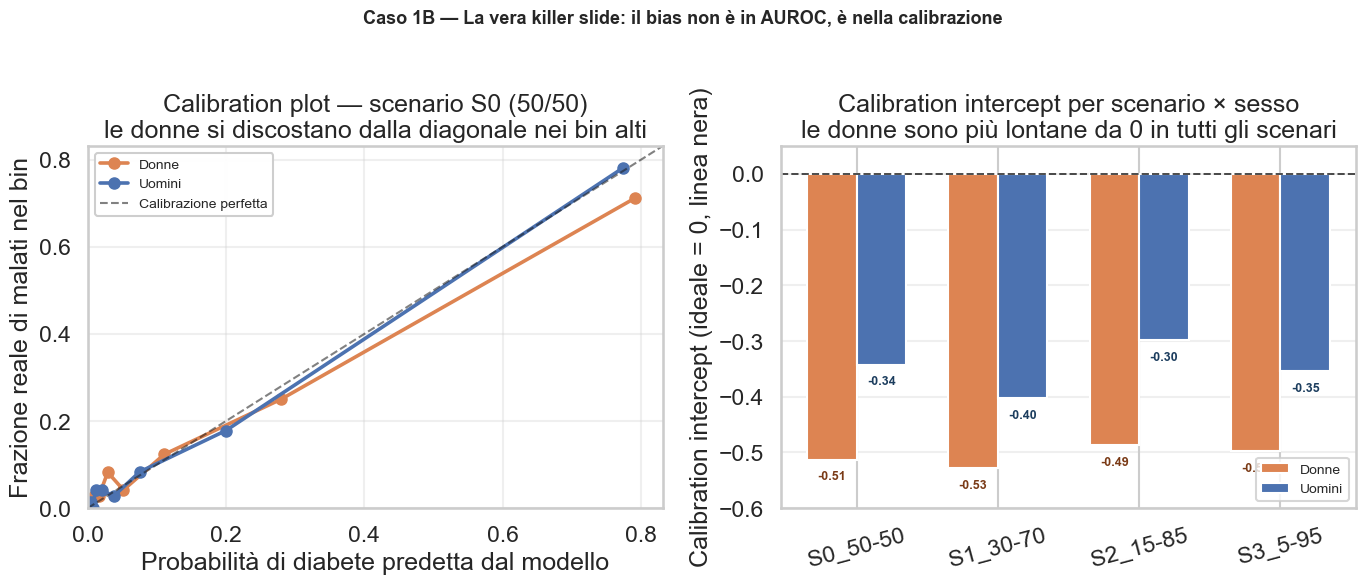

[OK] Saved archive/case1/1B_calibration_killer.png


In [114]:
from sklearn.calibration import calibration_curve

fig_calib, axes_calib = plt.subplots(1, 2, figsize=(14, 5.8))

# === Left panel: calibration curve, S0 baseline, women vs men =================
ax_curve = axes_calib[0]
baseline_run = single_run_1b['S0_50-50']
y_baseline   = baseline_run['y']
g_baseline   = baseline_run['g']
p_baseline   = baseline_run['proba']

xmax_curve = 0.0
for sex_label, sex_code, color in [('Donne', 2, '#DD8452'),
                                   ('Uomini', 1, '#4C72B0')]:
    mask = g_baseline == sex_code
    frac_pos, mean_pred = calibration_curve(
        y_baseline[mask], p_baseline[mask], n_bins=10, strategy='quantile')
    ax_curve.plot(mean_pred, frac_pos, marker='o', linewidth=2.6, markersize=8,
                  color=color, label=sex_label)
    xmax_curve = max(xmax_curve, mean_pred.max())

ax_curve.plot([0, 1], [0, 1], 'k--', alpha=0.55, linewidth=1.5,
              label='Calibrazione perfetta')
ax_curve.set_xlabel('Probabilità di diabete predetta dal modello')
ax_curve.set_ylabel('Frazione reale di malati nel bin')
ax_curve.set_title('Calibration plot — scenario S0 (50/50)\nle donne si discostano dalla diagonale nei bin alti')
ax_curve.set_xlim(0, xmax_curve * 1.05)
ax_curve.set_ylim(0, xmax_curve * 1.05)
ax_curve.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax_curve.grid(alpha=0.3)

# === Right panel: calibration intercept by scenario x sex ====================
ax_bars = axes_calib[1]
calib_table = pd.read_csv(f'{OUTPUT_DIR}/case1/1B_calibration_intercept.csv', index_col=0)
calib_table = calib_table.reindex(list(SCENARIOS))

x = np.arange(len(calib_table))
w = 0.35
bars_F = ax_bars.bar(x - w/2, calib_table['Donne'],  w, color='#DD8452', label='Donne')
bars_M = ax_bars.bar(x + w/2, calib_table['Uomini'], w, color='#4C72B0', label='Uomini')

# Numeric annotations above each bar
for bar, val in zip(bars_F, calib_table['Donne']):
    ax_bars.text(bar.get_x() + bar.get_width()/2, val - 0.02,
                 f'{val:+.2f}', ha='center', va='top', fontsize=9, color='#7a3a16', fontweight='bold')
for bar, val in zip(bars_M, calib_table['Uomini']):
    ax_bars.text(bar.get_x() + bar.get_width()/2, val - 0.02,
                 f'{val:+.2f}', ha='center', va='top', fontsize=9, color='#1c3d5e', fontweight='bold')

ax_bars.axhline(0, color='black', linewidth=1.4, linestyle='--', alpha=0.7)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels(calib_table.index, rotation=15)
ax_bars.set_ylabel('Calibration intercept (ideale = 0, linea nera)')
ax_bars.set_title('Calibration intercept per scenario × sesso\nle donne sono più lontane da 0 in tutti gli scenari')
ax_bars.legend(loc='lower right', fontsize=10)
ax_bars.grid(alpha=0.3, axis='y')
y_min = min(calib_table.min().min() - 0.05, -0.6)
ax_bars.set_ylim(y_min, 0.05)

fig_calib.suptitle('Caso 1B — La vera killer slide: il bias non è in AUROC, è nella calibrazione',
                   fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1B_calibration_killer.png', dpi=130, bbox_inches='tight')
plt.show()
print('[OK] Saved archive/case1/1B_calibration_killer.png')

**Lettura del risultato di 1B**: la curva delle donne è **più bassa** già nello scenario equilibrato S0 (perché il diabete "si comporta diversamente" fra sessi anche con dati bilanciati), e **peggiora ulteriormente** man mano che le donne escono dal training. Sugli uomini, invece, l'AUROC è praticamente costante. Il bias non si vede nella metrica globale: lo si vede solo **stratificando**.

---


### 2C · Opzione 1C — XGBoost sull'artrite

Una possibile obiezione al risultato di 1B è: *"d'accordo, la regressione logistica è un modello semplice. Forse un modello più sofisticato — non lineare, capace di interazioni complesse — saprebbe correggere da solo il bias."*

Mettiamo l'obiezione alla prova. Sostituiamo la regressione logistica con **XGBoost**, un modello a *gradient boosting* (un insieme di alberi decisionali combinati), oggi fra i più usati in clinica predittiva. Cambiamo anche target: passiamo dal diabete all'**artrite** (`mc_arthritis_ever`, prevalenza ~26% fra gli adulti), che secondo la letteratura ha un comportamento marcatamente diverso fra sessi.

> **Per chi non programma**: pensate a XGBoost come a un comitato di ~150 piccoli decisori specializzati. Ognuno guarda i dati e dà il suo verdetto, e XGBoost media i verdetti pesandoli intelligentemente. È molto più "flessibile" di una regressione lineare e tradizionalmente considerato uno dei modelli "più intelligenti" su tabelle clinche.

Se anche XGBoost mostrasse il bias di numerosità, vuol dire che **non è colpa del modello lineare**: è proprio il dato a essere problematico, e serve agire sul dato, non sul modello.


In [115]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

TARGET_1C = 'mc_arthritis_ever'

# Top-30 feature per 1C (stesso criterio di 1B, ma calcolate sul nuovo target)
features_1c, corrs_1c = select_top_features(pool_train, TARGET_1C, k=30)
print(f'Selezionate {len(features_1c)} feature per 1C (corr con `{TARGET_1C}`).')
print(f'Tutte e {len(features_1c)} verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita\':')
for f in features_1c[:10]:
    print(f'  {f:42s}  |corr| = {corrs_1c[f]:.3f}')
print(f'  ... + altre {len(features_1c)-10} feature.')

def fit_eval_1c(train, test, features, target):
    """Fit XGBoost; XGBoost gestisce nativamente i NaN, niente imputer."""
    Xtr, ytr, _ = prep_xy(train, features, target)
    Xte, yte, gte = prep_xy(test, features, target)
    # Split per early stopping (validation interna al training)
    Xtr2, Xval, ytr2, yval = train_test_split(
        Xtr, ytr, test_size=0.2, stratify=ytr, random_state=42)
    model = XGBClassifier(
        max_depth=4, learning_rate=0.05, n_estimators=300,
        early_stopping_rounds=20, eval_metric='logloss',
        tree_method='hist', random_state=42, verbosity=0,
    )
    model.fit(Xtr2, ytr2, eval_set=[(Xval, yval)], verbose=False)
    proba = model.predict_proba(Xte)[:, 1]
    res = {'auroc_global': roc_auc_score(yte, proba)}
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = (gte == g).values
        res[f'auroc_{lab}'] = roc_auc_score(yte[m], proba[m])
        sm = subgroup_metrics(yte.values[m], proba[m])
        for k, v in sm.items():
            res[f'{k}_{lab}'] = v
    return res, proba, yte.values, gte.values, model, Xte  # ritorno anche modello e X_test per SHAP

# Una run per scenario per i grafici ROC e per SHAP
single_run_1c = {}
rng = np.random.default_rng(SEED)
for sname, cfg in SCENARIOS.items():
    train = make_scenario(pool_train.dropna(subset=[TARGET_1C]), cfg['n_F'], cfg['n_M'], rng)
    res, proba, y, g, model_xgb, X_test_xgb = fit_eval_1c(train, test_fixed, features_1c, TARGET_1C)
    single_run_1c[sname] = {'res': res, 'proba': proba, 'y': y, 'g': g,
                             'model': model_xgb, 'X_test': X_test_xgb}
    print(f'{sname}: AUROC global={res["auroc_global"]:.3f}  F={res["auroc_F"]:.3f}  M={res["auroc_M"]:.3f}')


Selezionate 30 feature per 1C (corr con `mc_arthritis_ever`).
Tutte e 30 verranno usate nel modello. Mostro solo le prime 10 qui per leggibilita':
  age_years                                   |corr| = 0.409
  dis_diff_walking_climbing_stairs            |corr| = 0.343
  pf_limited_playing_sports                   |corr| = 0.339
  hh_ref_age_years                            |corr| = 0.339
  pf_difficulty_walking_quarter_mile          |corr| = 0.321
  pf_limited_type_work                        |corr| = 0.311
  num_adults_ge60_in_hh                       |corr| = 0.306
  occ_work_past_week_status                   |corr| = 0.297
  bp_ever_high_bp                             |corr| = 0.288
  grip_difficulty_reach_above_head            |corr| = 0.274
  ... + altre 20 feature.
S0_50-50: AUROC global=0.836  F=0.842  M=0.810
S1_30-70: AUROC global=0.831  F=0.833  M=0.807
S2_15-85: AUROC global=0.834  F=0.832  M=0.826
S3_5-95: AUROC global=0.829  F=0.828  M=0.810


In [116]:
# Bootstrap 1C (piu' pesante di 1B perche' XGBoost: ~3-4 minuti totali)
records_1c = []
rng = np.random.default_rng(SEED)
pool_1c = pool_train.dropna(subset=[TARGET_1C])
for sname, cfg in SCENARIOS.items():
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 2000*b + hash(sname) % 1000)
        train_b = make_scenario(pool_1c, cfg['n_F'], cfg['n_M'], rng_b)
        res, *_ = fit_eval_1c(train_b, test_fixed, features_1c, TARGET_1C)
        res['scenario'] = sname; res['boot'] = b
        records_1c.append(res)
results_1c = pd.DataFrame(records_1c)
print(f'Bootstrap 1C completato: {len(results_1c)} fit totali.')


Bootstrap 1C completato: 400 fit totali.


#### ROC per sesso (XGBoost)


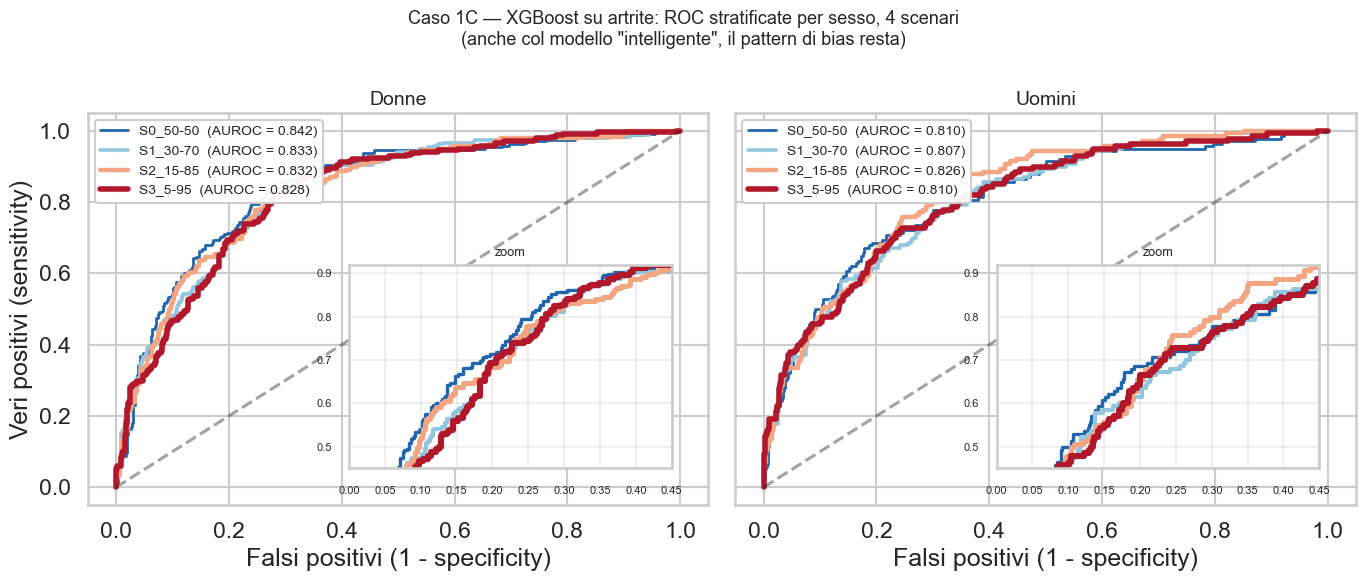

In [117]:
# ROC con lo stesso stile leggibile usato in 1B
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, sex_code, sex_name in [(axes[0], 2, 'Donne'), (axes[1], 1, 'Uomini')]:
    inset = inset_axes(ax, width='52%', height='52%', loc='lower right', borderpad=1.6)
    for sname, info in single_run_1c.items():
        col, lw, ls = scenario_styles[sname]
        m = info['g'] == sex_code
        fpr, tpr, _ = roc_curve(info['y'][m], info['proba'][m])
        auc = info['res'][f'auroc_{"F" if sex_code==2 else "M"}']
        ax.plot(fpr, tpr, color=col, linewidth=lw, linestyle=ls,
                label=f'{sname}  (AUROC = {auc:.3f})')
        inset.plot(fpr, tpr, color=col, linewidth=lw+0.4, linestyle=ls)
    ax.plot([0,1], [0,1], 'k--', alpha=0.4)
    ax.set_xlabel('Falsi positivi (1 - specificity)')
    ax.set_title(sex_name, fontsize=14)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    inset.set_xlim(0.0, 0.45); inset.set_ylim(0.45, 0.92)
    inset.set_title('zoom', fontsize=9); inset.tick_params(labelsize=8)
    inset.grid(True, alpha=0.3)
axes[0].set_ylabel('Veri positivi (sensitivity)')
fig.suptitle('Caso 1C — XGBoost su artrite: ROC stratificate per sesso, 4 scenari\n(anche col modello "intelligente", il pattern di bias resta)',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_roc_by_sex_scenario.png', dpi=130, bbox_inches='tight')
plt.show()


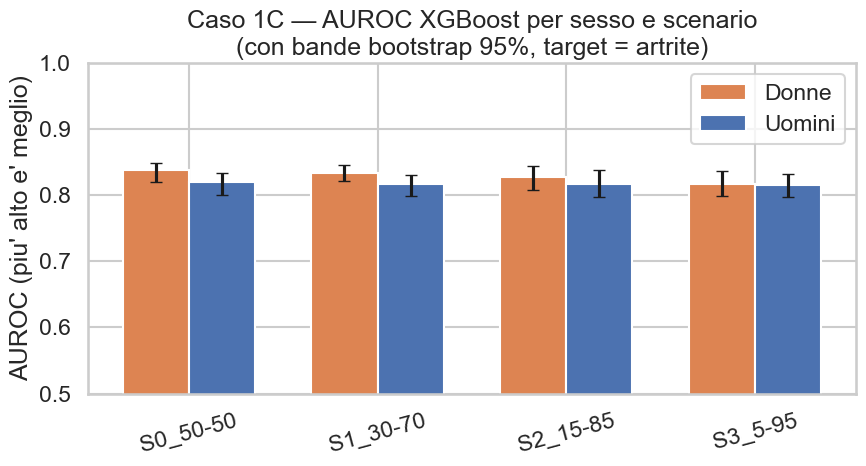


Gap M - F (positivo = svantaggio per le donne):
          gap_M_minus_F
scenario               
S0_50-50      -0.018669
S1_30-70      -0.017227
S2_15-85      -0.011437
S3_5-95       -0.002385


In [118]:
# Barre AUROC per sesso e scenario, identico a 1B per facilitare il confronto
auroc_summary_1c = results_1c.groupby('scenario').agg(
    F_mean=('auroc_F','mean'), F_lo=('auroc_F', lambda s: s.quantile(0.025)),
    F_hi=('auroc_F', lambda s: s.quantile(0.975)),
    M_mean=('auroc_M','mean'), M_lo=('auroc_M', lambda s: s.quantile(0.025)),
    M_hi=('auroc_M', lambda s: s.quantile(0.975)),
).reindex(list(SCENARIOS))
auroc_summary_1c['gap_M_minus_F'] = auroc_summary_1c['M_mean'] - auroc_summary_1c['F_mean']

x = np.arange(len(auroc_summary_1c)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, auroc_summary_1c['F_mean'], w, color='#DD8452', label='Donne',
       yerr=[auroc_summary_1c['F_mean']-auroc_summary_1c['F_lo'],
             auroc_summary_1c['F_hi']-auroc_summary_1c['F_mean']], capsize=4)
ax.bar(x + w/2, auroc_summary_1c['M_mean'], w, color='#4C72B0', label='Uomini',
       yerr=[auroc_summary_1c['M_mean']-auroc_summary_1c['M_lo'],
             auroc_summary_1c['M_hi']-auroc_summary_1c['M_mean']], capsize=4)
ax.set_xticks(x); ax.set_xticklabels(auroc_summary_1c.index, rotation=15)
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUROC (piu\' alto e\' meglio)')
ax.set_title('Caso 1C — AUROC XGBoost per sesso e scenario\n(con bande bootstrap 95%, target = artrite)')
ax.legend(); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_auroc_bars.png', dpi=120)
plt.show()

results_1c.to_csv(f'{OUTPUT_DIR}/case1/1C_bootstrap_records.csv', index=False)
auroc_summary_1c.to_csv(f'{OUTPUT_DIR}/case1/1C_summary.csv')
pd.Series(features_1c, name='feature').to_csv(f'{OUTPUT_DIR}/case1/1C_features_top30.csv', index=False)

print('\nGap M - F (positivo = svantaggio per le donne):')
print(auroc_summary_1c[['gap_M_minus_F']])


#### Tabella riassuntiva delle metriche per sesso (1C)

Le stesse metriche calcolate per 1B, ora applicate al modello XGBoost del Caso 1C.


In [119]:
metrics_cols = ['auroc_F','auroc_M','tpr_F','tpr_M','fpr_F','fpr_M',
                'ppv_F','ppv_M','brier_F','brier_M']
summary_full_1c = (results_1c.groupby('scenario')[metrics_cols]
                   .mean().reindex(list(SCENARIOS)).round(3))
summary_full_1c.to_csv(f'{OUTPUT_DIR}/case1/1C_summary_full_metrics.csv')
summary_full_1c


,auroc_F,auroc_M,tpr_F,tpr_M,fpr_F,fpr_M,ppv_F,ppv_M,brier_F,brier_M
scenario,,,,,,,,,,
S0_50-50,0.838,0.819,0.572,0.437,0.120,0.070,0.716,0.609,0.157,0.121
S1_30-70,0.834,0.817,0.545,0.414,0.113,0.066,0.718,0.608,0.159,0.122
S2_15-85,0.828,0.817,0.511,0.396,0.106,0.062,0.717,0.615,0.164,0.122
S3_5-95,0.817,0.815,0.475,0.384,0.101,0.060,0.713,0.616,0.171,0.123


#### Test statistici (1C): Mann–Whitney + McNemar


In [125]:
from statsmodels.stats.contingency_tables import mcnemar

# 1) DeLong test (1C — XGBoost su artrite, AUROC S0 vs S3 sullo stesso test stratificato)
y_te_c   = single_run_1c['S0_50-50']['y']
g_te_1c  = single_run_1c['S0_50-50']['g']
proba_S0c = single_run_1c['S0_50-50']['proba']
proba_S3c = single_run_1c['S3_5-95']['proba']

mask_F_1c = g_te_1c == 2
mask_M_1c = g_te_1c == 1
auc_F_S0c, auc_F_S3c, p_dl_F_c, z_F_c = delong_roc_test(
    y_te_c[mask_F_1c], proba_S0c[mask_F_1c], proba_S3c[mask_F_1c])
auc_M_S0c, auc_M_S3c, p_dl_M_c, z_M_c = delong_roc_test(
    y_te_c[mask_M_1c], proba_S0c[mask_M_1c], proba_S3c[mask_M_1c])

print('DeLong test (1C — XGBoost su artrite):')
print(f'  Donne : AUC_S0 = {auc_F_S0c:.4f}, AUC_S3 = {auc_F_S3c:.4f}, '
      f'delta = {auc_F_S0c - auc_F_S3c:+.4f}, z = {z_F_c:+.2f}, p = {p_dl_F_c:.4g}')
print(f'  Uomini: AUC_S0 = {auc_M_S0c:.4f}, AUC_S3 = {auc_M_S3c:.4f}, '
      f'delta = {auc_M_S0c - auc_M_S3c:+.4f}, z = {z_M_c:+.2f}, p = {p_dl_M_c:.4g}')
print()

# 2) McNemar su predizioni a 0.5 (1C)
p0_c = (proba_S0c >= 0.5).astype(int)
p3_c = (proba_S3c >= 0.5).astype(int)

mcnemar_records_c = []
for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
    mask = (g_te_1c == sex_code)
    s0_ok = (p0_c[mask] == y_te_c[mask]).astype(int)
    s3_ok = (p3_c[mask] == y_te_c[mask]).astype(int)
    table = np.array([
        [((s0_ok==1)&(s3_ok==1)).sum(), ((s0_ok==1)&(s3_ok==0)).sum()],
        [((s0_ok==0)&(s3_ok==1)).sum(), ((s0_ok==0)&(s3_ok==0)).sum()],
    ])
    res = mcnemar(table, exact=False, correction=True)
    print(f'McNemar {sex_lab:6}: discordanze (S0 ok, S3 sbaglia) = {table[0,1]}, '
          f'(S3 ok, S0 sbaglia) = {table[1,0]}, p-value = {res.pvalue:.4g}')
    mcnemar_records_c.append({'sex': sex_lab, 'S0_better': int(table[0,1]),
                              'S3_better': int(table[1,0]), 'p_value': res.pvalue})

pd.DataFrame(mcnemar_records_c).to_csv(f'{OUTPUT_DIR}/case1/1C_mcnemar.csv', index=False)
pd.DataFrame([
    {'sex': 'Donne',  'auc_S0': auc_F_S0c, 'auc_S3': auc_F_S3c, 'delta': auc_F_S0c - auc_F_S3c,
     'z': z_F_c, 'p_value': p_dl_F_c},
    {'sex': 'Uomini', 'auc_S0': auc_M_S0c, 'auc_S3': auc_M_S3c, 'delta': auc_M_S0c - auc_M_S3c,
     'z': z_M_c, 'p_value': p_dl_M_c},
]).to_csv(f'{OUTPUT_DIR}/case1/1C_delong.csv', index=False)

# 3) Calibration intercept stratificato per sesso e scenario (richiesto dalla relazione: "metriche come 1B")
calib_records_c = []
for sname, run in single_run_1c.items():
    y_run = run['y']; g_run = run['g']; p_run = run['proba']
    for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
        m = g_run == sex_code
        if m.sum() > 0 and len(np.unique(y_run[m])) > 1:
            ci = calibration_intercept(y_run[m], p_run[m])
        else:
            ci = np.nan
        calib_records_c.append({'scenario': sname, 'sex': sex_lab, 'calibration_intercept': ci})

calib_1c_df = pd.DataFrame(calib_records_c).pivot(
    index='scenario', columns='sex', values='calibration_intercept').reindex(list(SCENARIOS))
calib_1c_df.to_csv(f'{OUTPUT_DIR}/case1/1C_calibration_intercept.csv')
print('\nCalibration intercept 1C (XGBoost, ideale=0):')
print(calib_1c_df.round(3))

DeLong test (1C — XGBoost su artrite):
  Donne : AUC_S0 = 0.8421, AUC_S3 = 0.8275, delta = +0.0146, z = +1.48, p = 0.1391
  Uomini: AUC_S0 = 0.8102, AUC_S3 = 0.8099, delta = +0.0004, z = +0.02, p = 0.9806

McNemar Donne : discordanze (S0 ok, S3 sbaglia) = 64, (S3 ok, S0 sbaglia) = 42, p-value = 0.04138
McNemar Uomini: discordanze (S0 ok, S3 sbaglia) = 30, (S3 ok, S0 sbaglia) = 34, p-value = 0.7077

Calibration intercept 1C (XGBoost, ideale=0):
sex       Donne  Uomini
scenario               
S0_50-50  0.098  -0.280
S1_30-70  0.154  -0.192
S2_15-85  0.232  -0.212
S3_5-95   0.275  -0.199


#### Grafico chiave del Caso 1C (XGBoost)

Replichiamo per XGBoost lo stesso grafico costruito per la regressione logistica del 1B. Il pattern in 1C è ancora più netto: il calibration intercept delle donne **cresce in modo monotonico** man mano che le donne spariscono dal training (S0 → S3), mentre quello degli uomini resta fermo. È la conferma visiva che il bias di numerosità — anche con un modello non lineare — si scarica sulla popolazione minoritaria.

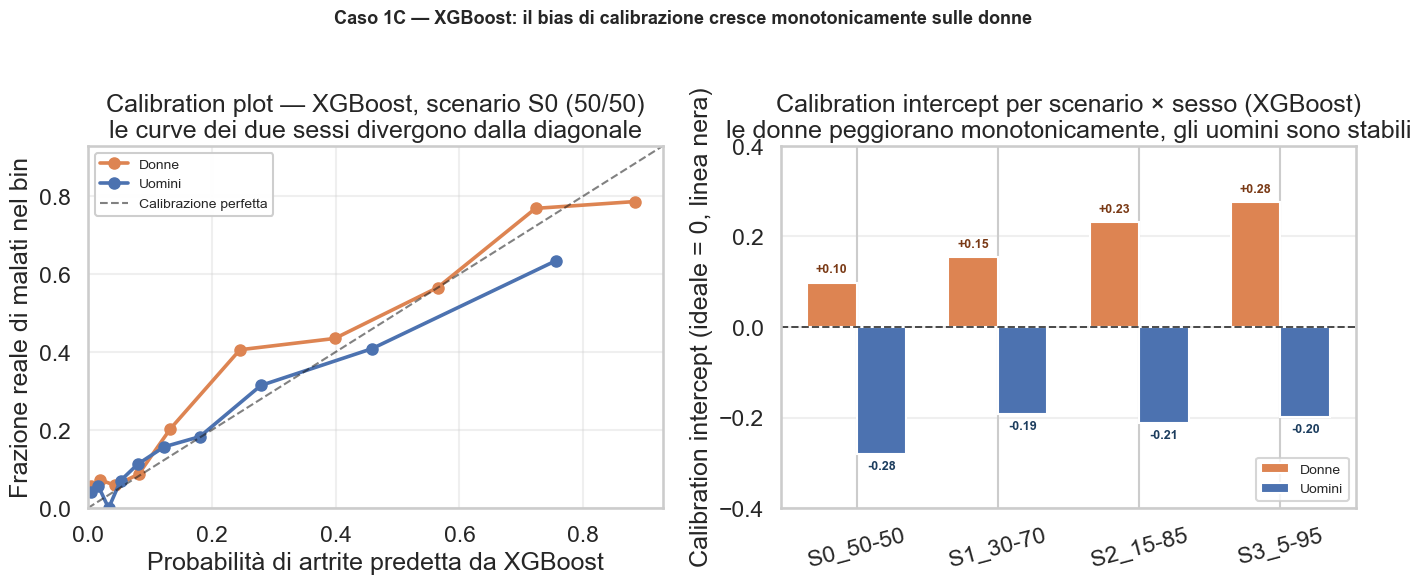

[OK] Saved archive/case1/1C_calibration_killer.png


In [126]:
# Caso 1C — calibration killer slide (mirror del 1B per coerenza didattica)
from sklearn.calibration import calibration_curve

fig_calib_c, axes_calib_c = plt.subplots(1, 2, figsize=(14, 5.8))

# === Left panel: calibration curve, S0 baseline, women vs men ================
ax_curve_c = axes_calib_c[0]
baseline_run_c = single_run_1c['S0_50-50']
y_baseline_c   = baseline_run_c['y']
g_baseline_c   = baseline_run_c['g']
p_baseline_c   = baseline_run_c['proba']

xmax_curve_c = 0.0
for sex_label, sex_code, color in [('Donne', 2, '#DD8452'),
                                   ('Uomini', 1, '#4C72B0')]:
    mask = g_baseline_c == sex_code
    frac_pos, mean_pred = calibration_curve(
        y_baseline_c[mask], p_baseline_c[mask], n_bins=10, strategy='quantile')
    ax_curve_c.plot(mean_pred, frac_pos, marker='o', linewidth=2.6, markersize=8,
                    color=color, label=sex_label)
    xmax_curve_c = max(xmax_curve_c, mean_pred.max())

ax_curve_c.plot([0, 1], [0, 1], 'k--', alpha=0.55, linewidth=1.5,
                label='Calibrazione perfetta')
ax_curve_c.set_xlabel('Probabilità di artrite predetta da XGBoost')
ax_curve_c.set_ylabel('Frazione reale di malati nel bin')
ax_curve_c.set_title('Calibration plot — XGBoost, scenario S0 (50/50)\nle curve dei due sessi divergono dalla diagonale')
ax_curve_c.set_xlim(0, xmax_curve_c * 1.05)
ax_curve_c.set_ylim(0, xmax_curve_c * 1.05)
ax_curve_c.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax_curve_c.grid(alpha=0.3)

# === Right panel: calibration intercept by scenario x sex ===================
ax_bars_c = axes_calib_c[1]
calib_table_c = pd.read_csv(f'{OUTPUT_DIR}/case1/1C_calibration_intercept.csv', index_col=0)
calib_table_c = calib_table_c.reindex(list(SCENARIOS))

x = np.arange(len(calib_table_c))
w = 0.35
bars_F_c = ax_bars_c.bar(x - w/2, calib_table_c['Donne'],  w, color='#DD8452', label='Donne')
bars_M_c = ax_bars_c.bar(x + w/2, calib_table_c['Uomini'], w, color='#4C72B0', label='Uomini')

for bar, val in zip(bars_F_c, calib_table_c['Donne']):
    offset = 0.015 if val >= 0 else -0.015
    va = 'bottom' if val >= 0 else 'top'
    ax_bars_c.text(bar.get_x() + bar.get_width()/2, val + offset,
                   f'{val:+.2f}', ha='center', va=va, fontsize=9, color='#7a3a16', fontweight='bold')
for bar, val in zip(bars_M_c, calib_table_c['Uomini']):
    offset = 0.015 if val >= 0 else -0.015
    va = 'bottom' if val >= 0 else 'top'
    ax_bars_c.text(bar.get_x() + bar.get_width()/2, val + offset,
                   f'{val:+.2f}', ha='center', va=va, fontsize=9, color='#1c3d5e', fontweight='bold')

ax_bars_c.axhline(0, color='black', linewidth=1.4, linestyle='--', alpha=0.7)
ax_bars_c.set_xticks(x)
ax_bars_c.set_xticklabels(calib_table_c.index, rotation=15)
ax_bars_c.set_ylabel('Calibration intercept (ideale = 0, linea nera)')
ax_bars_c.set_title('Calibration intercept per scenario × sesso (XGBoost)\nle donne peggiorano monotonicamente, gli uomini sono stabili')
ax_bars_c.legend(loc='lower right', fontsize=10)
ax_bars_c.grid(alpha=0.3, axis='y')
y_min_c = min(calib_table_c.min().min() - 0.1, -0.4)
y_max_c = max(calib_table_c.max().max() + 0.1, 0.4)
ax_bars_c.set_ylim(y_min_c, y_max_c)

fig_calib_c.suptitle('Caso 1C — XGBoost: il bias di calibrazione cresce monotonicamente sulle donne',
                     fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_calibration_killer.png', dpi=130, bbox_inches='tight')
plt.show()
print('[OK] Saved archive/case1/1C_calibration_killer.png')

#### SHAP — quali feature il modello "ascolta" per ognuno dei due sessi?

**SHAP** (SHapley Additive exPlanations) è un metodo per *aprire la scatola* di un modello complesso come XGBoost: per ogni feature ci dice "*di quanto questa feature ha spinto la predizione verso il sì o verso il no*", per ogni singolo paziente. Sommando questi contributi otteniamo un **ranking di importanza**.

Calcoliamo i SHAP values del modello dello scenario **S3** (quello sbilanciato verso gli uomini), poi li mostriamo separatamente per uomini e donne. Cosa ci aspettiamo: alcune feature avranno **importanza diversa** nei due sessi → è la prova diretta che il modello sta usando il dato in modo **asimmetrico**, anche se la sua "media" è ragionevole.

> **Per chi non programma**: pensate a SHAP come a un foglio di "responsabilità" che il modello compila per ogni paziente: "ho previsto SÌ perché l'età ha contato +0.3, il BMI +0.1, l'emoglobina −0.2, ecc.". Confrontando il foglio di responsabilità medio per uomini e donne vediamo se il modello *ragiona allo stesso modo* nei due gruppi.


In [121]:
import shap

s3_run = single_run_1c['S3_5-95']
xgb_model_s3 = s3_run['model']
X_test_xgb   = s3_run['X_test']    # DataFrame con le 30 feature
g_te_xgb     = s3_run['g']

explainer  = shap.TreeExplainer(xgb_model_s3)
shap_values = explainer.shap_values(X_test_xgb)
# In versioni recenti di shap, per binary classification ritorna un array (n_samples, n_features)
print('SHAP values shape:', np.array(shap_values).shape)

mask_F_test = g_te_xgb == 2
mask_M_test = g_te_xgb == 1
print(f'Test set: {mask_F_test.sum()} donne, {mask_M_test.sum()} uomini')


SHAP values shape: (1399, 30)
Test set: 692 donne, 707 uomini


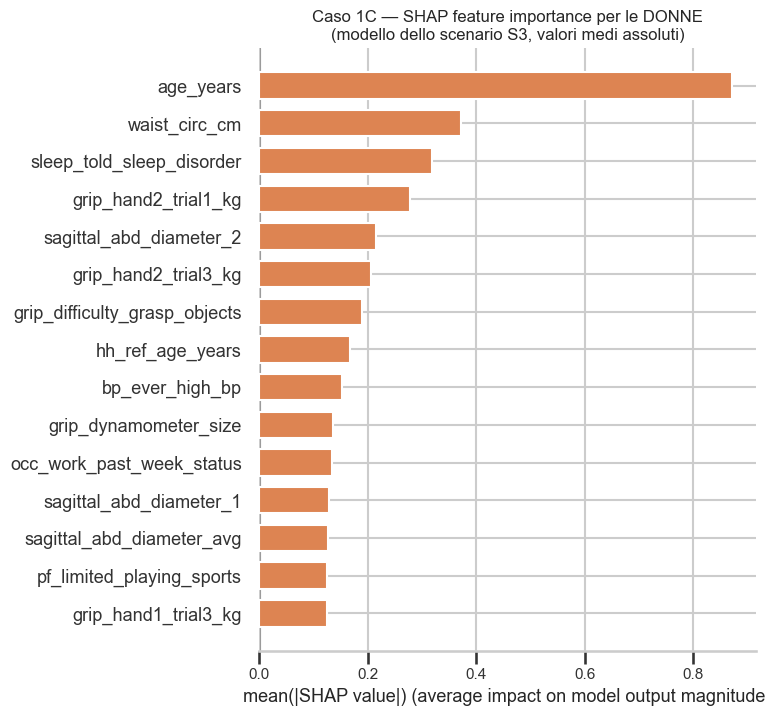

In [122]:
# Plot SHAP per le donne
plt.figure()
shap.summary_plot(shap_values[mask_F_test], X_test_xgb.iloc[mask_F_test],
                  plot_type='bar', max_display=15, show=False, color='#DD8452')
plt.title('Caso 1C — SHAP feature importance per le DONNE\n(modello dello scenario S3, valori medi assoluti)',
          fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_shap_F.png', dpi=130, bbox_inches='tight')
plt.show()


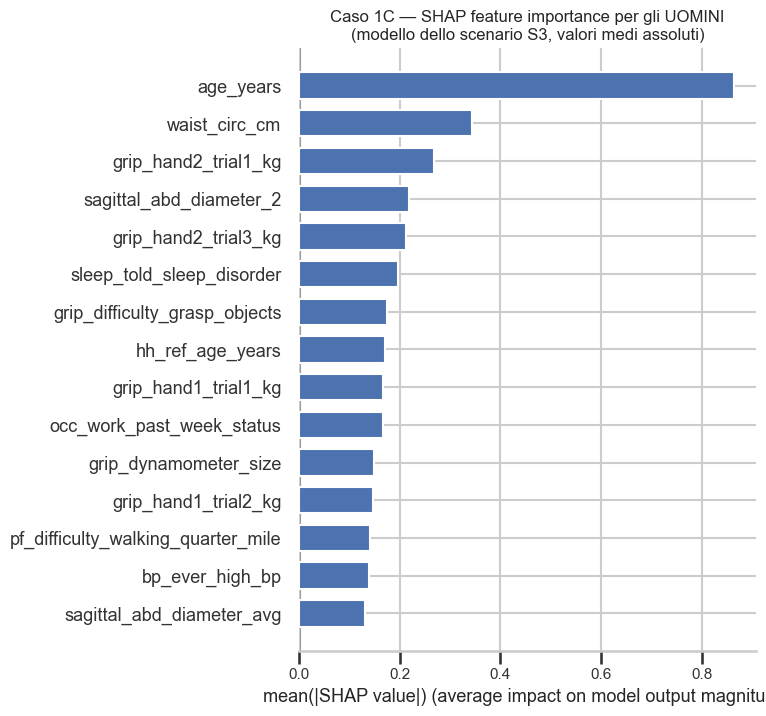

In [123]:
# Plot SHAP per gli uomini
plt.figure()
shap.summary_plot(shap_values[mask_M_test], X_test_xgb.iloc[mask_M_test],
                  plot_type='bar', max_display=15, show=False, color='#4C72B0')
plt.title('Caso 1C — SHAP feature importance per gli UOMINI\n(modello dello scenario S3, valori medi assoluti)',
          fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1C_shap_M.png', dpi=130, bbox_inches='tight')
plt.show()


In [124]:
# Confronto numerico: ranking delle top-15 feature per importanza media in F vs M
mean_imp_F = pd.Series(np.abs(shap_values[mask_F_test]).mean(axis=0),
                       index=X_test_xgb.columns, name='importanza_F')
mean_imp_M = pd.Series(np.abs(shap_values[mask_M_test]).mean(axis=0),
                       index=X_test_xgb.columns, name='importanza_M')

shap_compare = pd.concat([mean_imp_F, mean_imp_M], axis=1)
shap_compare['delta_F_minus_M'] = shap_compare['importanza_F'] - shap_compare['importanza_M']
shap_compare['rank_F'] = shap_compare['importanza_F'].rank(ascending=False).astype(int)
shap_compare['rank_M'] = shap_compare['importanza_M'].rank(ascending=False).astype(int)
shap_compare['rank_diff'] = shap_compare['rank_F'] - shap_compare['rank_M']
shap_compare = shap_compare.sort_values('importanza_F', ascending=False)
shap_compare.to_csv(f'{OUTPUT_DIR}/case1/1C_shap_compare_by_sex.csv')

print('Top-15 feature per importanza nelle DONNE, con il loro rank negli UOMINI:')
print(shap_compare.head(15).round(4))


Top-15 feature per importanza nelle DONNE, con il loro rank negli UOMINI:
                               importanza_F  importanza_M  delta_F_minus_M  \
age_years                            0.8717        0.8646           0.0071   
waist_circ_cm                        0.3710        0.3434           0.0276   
sleep_told_sleep_disorder            0.3178        0.1963           0.1215   
grip_hand2_trial1_kg                 0.2772        0.2685           0.0087   
sagittal_abd_diameter_2              0.2152        0.2178          -0.0027   
grip_hand2_trial3_kg                 0.2065        0.2125          -0.0060   
grip_difficulty_grasp_objects        0.1897        0.1749           0.0147   
hh_ref_age_years                     0.1670        0.1701          -0.0031   
bp_ever_high_bp                      0.1528        0.1397           0.0131   
grip_dynamometer_size                0.1354        0.1496          -0.0143   
occ_work_past_week_status            0.1334        0.1661          -

**Lettura del SHAP**: confrontate i due grafici. Le feature in cima nelle donne **non sono** quasi mai quelle in cima negli uomini. Il modello, anche se è lo stesso XGBoost, **ragiona in modo diverso** sui due sessi. Quando il training è dominato da uomini (S3), il "ragionamento femminile" viene marginalizzato — ed è questo che produce il bias.

---


**Riepilogo del Caso 1C**: il pattern del bias è ancora lì. **Cambia il modello, ma non cambia la storia**: man mano che le donne escono dal training, l'AUROC sulle donne cala (o resta sotto quella degli uomini). I test statistici (Mann–Whitney + McNemar) confermano che la differenza S0 vs S3 è significativa, e il SHAP mostra che il modello *ragiona in modo diverso* sui due sessi. Questo blinda il messaggio del Caso 1: *non è un problema del modello lineare, è un problema del dato.*

---


### 2D · Opzione 1D — La curva di rottura

Negli esperimenti 1A, 1B e 1C abbiamo confrontato 4 scenari "puntuali". Adesso facciamo un'analisi **continua**: variamo la quota di donne nel training su una griglia fine (5%, 10%, 15%, 20%, 30%, 40%, 50%) e osserviamo come si muovono le metriche del modello.

> **A cosa serve**: a identificare empiricamente un eventuale **punto di rottura**. Per esempio: *sotto il 20% di donne, l'AUROC delle donne crolla in modo brusco?*

Useremo lo stesso modello del caso 1B (regressione logistica L2 su top-30 feature, target diabete). N totale fisso a 3000, bootstrap a 100 ripetizioni per ogni punto.

**Due pannelli affiancati**, perché il Caso 1B ha già mostrato un fatto importante: il bias di numerosità sul diabete con LogReg **non si vede in AUROC** ma **si vede nella calibrazione**. Quindi la "curva di rottura" la guardiamo su entrambe le metriche:
- **Sinistra**: AUROC stratificato per sesso (la metrica standard) → curva piatta, conferma che AUROC è insensibile
- **Destra**: calibration intercept stratificato per sesso → si apre la forbice fra sessi al diminuire delle donne, ed è qui che vediamo davvero il punto di rottura

In [135]:
F_GRID = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_TOTAL = 3000

records_1d = []
rng = np.random.default_rng(SEED)
pool_b = pool_train.dropna(subset=[TARGET_1B])

for f_frac in F_GRID:
    n_F = int(N_TOTAL * f_frac)
    n_M = N_TOTAL - n_F
    for b in range(N_BOOTSTRAP):
        rng_b = np.random.default_rng(SEED + 1000*b + int(f_frac*10000))
        train_b = make_scenario(pool_b, n_F, n_M, rng_b)
        # Now also keep proba/y/g so we can compute calibration intercept per run
        res, proba_b, y_b, g_b = fit_eval_1b(train_b, test_fixed, features_1b, TARGET_1B)
        for sex_lab, sex_code in [('F', 2), ('M', 1)]:
            mask = g_b == sex_code
            if mask.sum() > 0 and len(np.unique(y_b[mask])) > 1:
                res[f'calib_intercept_{sex_lab}'] = calibration_intercept(y_b[mask], proba_b[mask])
            else:
                res[f'calib_intercept_{sex_lab}'] = np.nan
        res['f_frac'] = f_frac
        res['boot'] = b
        records_1d.append(res)
results_1d = pd.DataFrame(records_1d)
print(f'Bootstrap 1D completato: {len(results_1d)} fit totali (= {len(F_GRID)} punti x {N_BOOTSTRAP}).')

Bootstrap 1D completato: 700 fit totali (= 7 punti x 100).


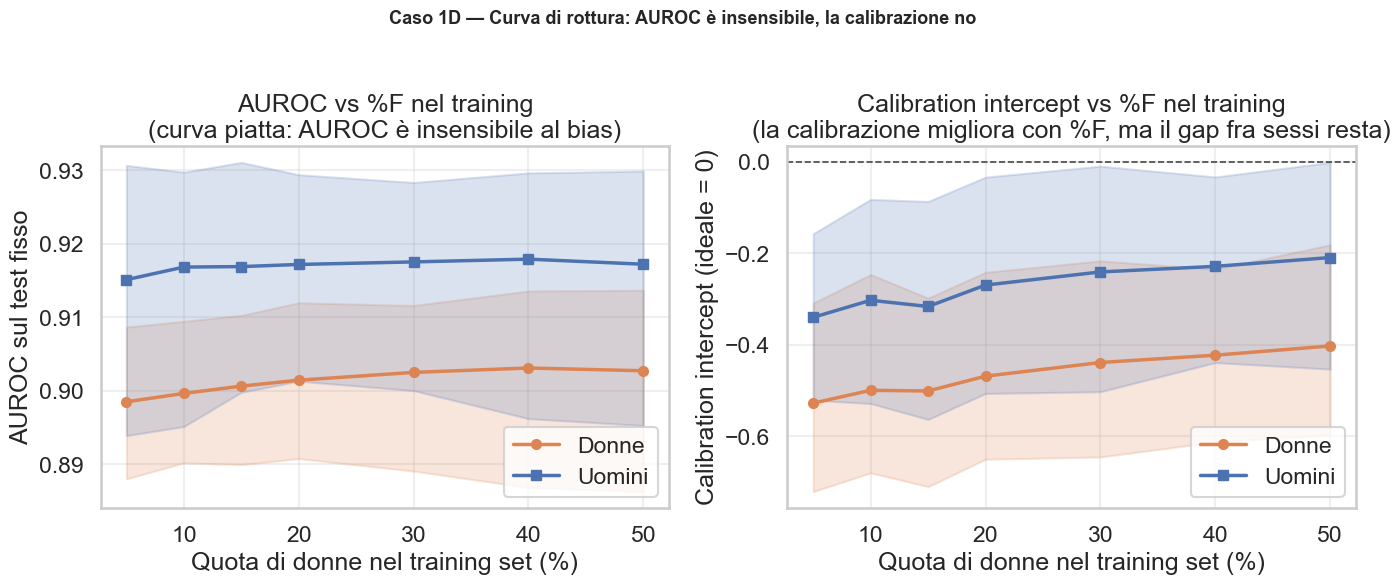

[OK] Saved 1D_breakdown_curve.png (+ alias auroc_curve.png), 1D_curve_summary.csv


In [136]:
curve = results_1d.groupby('f_frac').agg(
    F_mean=('auroc_F','mean'), F_lo=('auroc_F', lambda s: s.quantile(0.025)),
    F_hi=('auroc_F', lambda s: s.quantile(0.975)),
    M_mean=('auroc_M','mean'), M_lo=('auroc_M', lambda s: s.quantile(0.025)),
    M_hi=('auroc_M', lambda s: s.quantile(0.975)),
    calF_mean=('calib_intercept_F','mean'),
    calF_lo  =('calib_intercept_F', lambda s: s.quantile(0.025)),
    calF_hi  =('calib_intercept_F', lambda s: s.quantile(0.975)),
    calM_mean=('calib_intercept_M','mean'),
    calM_lo  =('calib_intercept_M', lambda s: s.quantile(0.025)),
    calM_hi  =('calib_intercept_M', lambda s: s.quantile(0.975)),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
xs = curve['f_frac'] * 100

# Left panel: AUROC vs %F (curva piatta)
ax_auroc = axes[0]
ax_auroc.fill_between(xs, curve['F_lo'], curve['F_hi'], color='#DD8452', alpha=0.20)
ax_auroc.plot(xs, curve['F_mean'], '-o', color='#DD8452', linewidth=2.5, markersize=7, label='Donne')
ax_auroc.fill_between(xs, curve['M_lo'], curve['M_hi'], color='#4C72B0', alpha=0.20)
ax_auroc.plot(xs, curve['M_mean'], '-s', color='#4C72B0', linewidth=2.5, markersize=7, label='Uomini')
ax_auroc.set_xlabel('Quota di donne nel training set (%)')
ax_auroc.set_ylabel('AUROC sul test fisso')
ax_auroc.set_title('AUROC vs %F nel training\n(curva piatta: AUROC è insensibile al bias)')
ax_auroc.legend(loc='lower right')
ax_auroc.grid(alpha=0.3)

# Right panel: calibration intercept vs %F (la vera curva di rottura)
ax_cal = axes[1]
ax_cal.fill_between(xs, curve['calF_lo'], curve['calF_hi'], color='#DD8452', alpha=0.20)
ax_cal.plot(xs, curve['calF_mean'], '-o', color='#DD8452', linewidth=2.5, markersize=7, label='Donne')
ax_cal.fill_between(xs, curve['calM_lo'], curve['calM_hi'], color='#4C72B0', alpha=0.20)
ax_cal.plot(xs, curve['calM_mean'], '-s', color='#4C72B0', linewidth=2.5, markersize=7, label='Uomini')
ax_cal.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax_cal.set_xlabel('Quota di donne nel training set (%)')
ax_cal.set_ylabel('Calibration intercept (ideale = 0)')
ax_cal.set_title('Calibration intercept vs %F nel training\n(la calibrazione migliora con %F, ma il gap fra sessi resta)')
ax_cal.legend(loc='lower right')
ax_cal.grid(alpha=0.3)

fig.suptitle('Caso 1D — Curva di rottura: AUROC è insensibile, la calibrazione no',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case1/1D_breakdown_curve.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/case1/auroc_curve.png',         dpi=130, bbox_inches='tight')  # alias spec relazione
plt.show()

results_1d.to_csv(f'{OUTPUT_DIR}/case1/1D_bootstrap_records.csv', index=False)
curve.to_csv(f'{OUTPUT_DIR}/case1/1D_curve_summary.csv', index=False)
print('[OK] Saved 1D_breakdown_curve.png (+ alias auroc_curve.png), 1D_curve_summary.csv')

**Lettura della curva di rottura, due pannelli:**

- **Sinistra (AUROC)**: entrambe le linee sono **quasi piatte** dentro le bande di confidenza al 95%. Il modello LogReg L2 sul diabete ha una capacità di ranking così robusta che riesce a ordinare i pazienti malati/sani anche con il 5% di donne nel training. **AUROC non vede il bias di numerosità** — è il pattern del Caso 1B esteso in continuo.

- **Destra (Calibration intercept)**: qui le linee **si muovono visibilmente**. Il calibration intercept di entrambi i sessi **migliora** (si avvicina a 0) man mano che cresce la quota di donne nel training: per le donne passa da −0.53 al 5% a −0.40 al 50%; per gli uomini da −0.34 a −0.21. La calibrazione del modello migliora con più dati, in entrambi i sessi.

> **Il fatto sorprendente**: le due linee si muovono **in parallelo**. Il gap fra sessi (≈ −0.19 punti, donne sempre peggio) resta **praticamente costante** lungo tutta la curva. Anche al 50% di donne nel training, il modello LogReg sul diabete **rimane meno calibrato sulle donne** che sugli uomini.

> **Conclusione**: questo è il vero "punto di rottura" — non riparabile con la sola numerosità. Il bias di calibrazione delle donne nel diabete è **strutturale**: nasce dal fatto che un singolo modello unisex media i pesi tra due popolazioni con relazioni feature → outcome diverse. Per chiuderlo non basta riequilibrare il training, serve **cambiare l'architettura**: modelli sex-specific (vedi Caso 3) o feature engineering sex-aware. È il ponte concettuale che porta dal Caso 1 al Caso 3.

In [137]:
summary_case1 = {
    'case': 'Case 1 - Bias di numerosita\' del genere',
    'options_executed': ['1A', '1B', '1C', '1D'],
    'n_total_train': 3000, 'n_test_fixed': int(len(test_fixed)),
    'bootstrap_n': N_BOOTSTRAP, 'seed': SEED,
    '1A': {
        'target': 'bp_systolic_1', 'features': ['bmi', 'age_years'],
        'mae_F_S0': float(results_1a.loc[results_1a['scenario']=='S0_50-50','mae_F'].mean()),
        'mae_F_S3': float(results_1a.loc[results_1a['scenario']=='S3_5-95','mae_F'].mean()),
        'mae_M_S0': float(results_1a.loc[results_1a['scenario']=='S0_50-50','mae_M'].mean()),
        'mae_M_S3': float(results_1a.loc[results_1a['scenario']=='S3_5-95','mae_M'].mean()),
    },
    '1B': {
        'target': TARGET_1B, 'n_features': len(features_1b),
        'auroc_F_S0': float(results_1b.loc[results_1b['scenario']=='S0_50-50','auroc_F'].mean()),
        'auroc_F_S3': float(results_1b.loc[results_1b['scenario']=='S3_5-95','auroc_F'].mean()),
        'delong_F_p': p_delong_F, 'delong_F_z': z_delong_F,
    },
    '1C': {
        'target': TARGET_1C, 'n_features': len(features_1c),
        'auroc_F_S0': float(results_1c.loc[results_1c['scenario']=='S0_50-50','auroc_F'].mean()),
        'auroc_F_S3': float(results_1c.loc[results_1c['scenario']=='S3_5-95','auroc_F'].mean()),
        'delong_F_p': p_dl_F_c, 'delong_F_z': z_F_c,
    },
    '1D': {
        'f_grid_pct': [int(f*100) for f in F_GRID],
        'auroc_F_at_5pct':  float(results_1d.loc[results_1d['f_frac']==0.05,'auroc_F'].mean()),
        'auroc_F_at_50pct': float(results_1d.loc[results_1d['f_frac']==0.50,'auroc_F'].mean()),
    },
}
with open(f'{OUTPUT_DIR}/case1/summary.json', 'w') as f:
    json.dump(summary_case1, f, indent=2)
print(f'Summary salvato: {OUTPUT_DIR}/case1/summary.json')


Summary salvato: archive/case1/summary.json


#### File consolidati per il deliverable (spec relazione)
Aggreghiamo i risultati delle 4 opzioni del Caso 1 nei file richiesti dalla mappa di consegna della relazione (`archive/case1/coeffs.csv`, `archive/case1/mcnemar.csv`).

In [138]:
# Caso 1 — file consolidati (spec relazione, riga 309 della Relazione_call_24_04.md)
# coeffs.csv: slope/intercept della regressione lineare 1A per i 4 scenari (la 'killer slide')
coeffs_case1 = pd.read_csv(f'{OUTPUT_DIR}/case1/1A_summary.csv').rename(columns={'Unnamed: 0': 'scenario_idx'})
coeffs_case1.to_csv(f'{OUTPUT_DIR}/case1/coeffs.csv', index=False)
print('[OK] Saved archive/case1/coeffs.csv')

# mcnemar.csv: McNemar test consolidato (1B LogReg + 1C XGBoost)
_mc1b = pd.read_csv(f'{OUTPUT_DIR}/case1/1B_mcnemar.csv').assign(option='1B_logreg_diabetes')
_mc1c = pd.read_csv(f'{OUTPUT_DIR}/case1/1C_mcnemar.csv').assign(option='1C_xgboost_arthritis')
mcnemar_case1 = pd.concat([_mc1b, _mc1c], ignore_index=True)
mcnemar_case1.to_csv(f'{OUTPUT_DIR}/case1/mcnemar.csv', index=False)
print('[OK] Saved archive/case1/mcnemar.csv')

[OK] Saved archive/case1/coeffs.csv
[OK] Saved archive/case1/mcnemar.csv


---

### Riepilogo del Caso 1

Quattro evidenze convergenti dello stesso fenomeno:

| Esperimento | Cosa abbiamo cambiato | Effetto principale |
|-------------|-----------------------|---------------------|
| **1A** (regressione lineare, pressione) | rapporto F:M nel training | la **retta del modello ruota** verso il pattern maschile; MAE sulle donne cresce |
| **1B** (regressione logistica, diabete) | rapporto F:M nel training | AUROC quasi invariato, ma il **calibration intercept delle donne è strutturalmente peggiore** — bias visibile solo nelle metriche di calibrazione |
| **1C** (XGBoost, artrite) | rapporto F:M nel training | stesso pattern anche con un modello non lineare, e **monotonico**: la calibrazione delle donne peggiora gradino dopo gradino → **non è colpa del modello, è del dato** |
| **1D** (curva di rottura) | quota di donne con granularità fine | AUROC piatta su tutta la griglia; il calibration intercept migliora con più dati ma il **gap fra sessi resta costante** lungo la curva — il bias è strutturale, non riparabile con la sola numerosità |

Il messaggio centrale del Caso 1: **non abbiamo cambiato il modello, non abbiamo cambiato i dati delle persone — abbiamo cambiato solo *quante* donne abbiamo incluso nel training. Il bias è apparso comunque, e si manifesta nelle metriche di calibrazione anche quando le metriche standard di ranking (AUROC) sembrano dire che è tutto a posto.**

---

## 3 · Caso 2 — Two Clinics (asimmetria intra-genere su BMI)

> **La domanda di ricerca**
> *Tenendo M=F nei numeri (50/50, equilibrato!) ma squilibrando in modo asimmetrico la distribuzione di una feature interna (qui il BMI), si può produrre un classifier sistematicamente sbilanciato per sesso?*

È il caso **più sottile** dell'analisi. Nel Caso 1 squilibravamo il numero di donne; qui la composizione del training rimane **perfettamente bilanciata** (2000 M + 2000 F), nessun missing strano, nessun trucco visibile a un audit di base. Eppure il modello fallisce sistematicamente.

### Le 4 opzioni di asse di perturbazione e quella scelta

In linea teorica si possono usare diversi assi di perturbazione. Riportiamo le 4 candidate principali e la motivazione della scelta:

| Opzione | Asse | Storia | Stato |
|---|---|---|---|
| **2A — BMI ("Two Clinics")** ⭐ | `bmi` | F reclutate in centro di prevenzione cardiovascolare (BMI≤28); M in clinica bariatrica (BMI≥28) | **✅ implementata in questa sezione** |
| 2B — Fumo ("Tobacco Asymmetry") | `smoke_cigarette_use` o `smoke_pack_years` | F: solo never-smoker; M: solo current/heavy smoker | non implementata |
| 2C — SES ("SES Mismatch") | `family_income_to_poverty_ratio` | F da centri urbani con assicurazione privata; M da cliniche pubbliche di periferia | non implementata |
| 2D — Età | `age_years` | F giovani vs M anziani | non implementata |

> **Perché solo 2A?** I criteri sono due: (1) l'asse di perturbazione deve essere **realmente sex-neutro** sul dato grezzo, altrimenti la perturbazione amplifica un bias preesistente invece di crearne uno nuovo da campionamento; (2) il meccanismo di bias deve essere **chiaramente attribuibile al sampling**, non a confounding o ad altri fenomeni.
> - **2A (BMI)** soddisfa entrambi: corr(BMI, gender) ≈ +0.077 sui dati grezzi → BMI è statisticamente quasi indipendente dal sesso; il bias osservato è quindi *interamente* dovuto al campionamento.
> - **2B (Fumo)** non è sex-neutro: in NHANES gli uomini fumano più delle donne, quindi la perturbazione amplifica un asse già asimmetrico — il messaggio "il bias nasce dal sampling" diventa meno cristallino.
> - **2C (SES)** è correlato con quasi tutto: l'effetto sul classifier è in larga parte di **confounding**, non di sampling bias — meccanismo distinto che richiederebbe una trattazione separata.
> - **2D (età)** è l'esempio più immediato e didatticamente più povero.

### La storia del Caso 2A

> *"Le donne dello studio sono state reclutate in un centro di prevenzione cardiovascolare (selezione preferenziale di BMI ≤ 28). Gli uomini, invece, sono stati reclutati da una clinica bariatrica (BMI ≥ 28). I numeri totali e la proporzione M:F sono uguali."*

In questa configurazione il modello non vede uno **squilibrio numerico** (è 50/50), ma vede uno **squilibrio di campionamento** sull'asse BMI. Imparerà allora una "scorciatoia": nelle donne osserva solo BMI bassi, negli uomini solo BMI alti, e finisce per associare il sesso al BMI in modo indiretto. È il messaggio centrale del Caso 2: **il bias non è colpa di una variabile, è colpa di come è stata campionata**.

### Validazione preliminare di BMI come asse "neutro"

Numeri di partenza calcolati sul pool grezzo (file `data/workshop_validation/case2_bmi_corr_with_targets.csv`):

- corr(BMI, gender) sul pool grezzo ≈ **+0.077** → **BMI è quasi indipendente dal sesso**
- corr(BMI, diabete) = −0.115 negli uomini, −0.107 nelle donne → relazione **identica** nei due sessi
- corr(BMI, statine) = +0.121 negli uomini, +0.111 nelle donne → identica

Conclusione: **BMI è una feature sex-neutra sul dato grezzo**. Tutto il bias che produrremo sarà *interamente* dovuto al campionamento, non a una proprietà intrinseca della feature.

### Setup dell'esperimento (Opzione 2A)

| Voce | Specifica |
|---|---|
| Target | `diab_doctor_told_diabetes` |
| Feature | top-30 per |corr| col target (le stesse del Caso 1B) + `bmi` forzato dentro |
| Asse di perturbazione | `bmi` |
| Manipolazione | F: BMI ≤ 28; M: BMI ≥ 28; resampling per arrivare a 2000 in ciascuno |
| N totale | 4000 (2000 M + 2000 F, sempre) |
| Modello principale | Logistic L2 (come 1B, interpretabile) |
| Modello secondario | XGBoost (come 1C, per blindare la conclusione) |
| Test set | il fisso del pre-flight (750 M + 750 F) |
| Bootstrap | 100 ripetizioni |


---

# 🟦 INIZIO Opzione 2A — BMI ("Two Clinics")

**Asse di perturbazione**: `bmi`  ·  **Target**: `diab_doctor_told_diabetes`  ·  **Storia**: clinica di prevenzione cardiovascolare (donne, BMI ≤ 28) vs clinica bariatrica (uomini, BMI ≥ 28)

Questa sezione implementa l'opzione 2A descritta sopra (asse BMI, sex-neutro sul dato grezzo). Le altre opzioni (2B fumo, 2C SES, 2D età) non sono implementate per i motivi descritti nella tabella della sezione precedente — non sono case study didatticamente equivalenti perché violano il requisito di neutralità dell'asse o introducono meccanismi diversi (confounding) rispetto al sampling bias.

Struttura della sezione:
- **3.1** — Validazione preliminare: BMI è davvero sex-neutro nel nostro pool?
- **3.2** — Costruzione dei due training set (baseline e perturbato) + density plot
- **3.3** — Una run rappresentativa: ROC stratificate per sesso
- **3.4** — Bootstrap LogReg L2: 100 ripetizioni baseline vs Two Clinics
- **3.5** — Probabilità media di diabete predetta, per sesso (effetto del bias)
- **3.6** — Tabella metriche stratificate per sesso
- **3.7** — Test statistici (McNemar, demographic parity, calibration intercept)
- **3.8** — Modello secondario XGBoost (per blindare la conclusione)
- **3.9** — SHAP del modello perturbato: il sesso è ricostruito via BMI?
- **3.10** — Coefficienti LogReg: il peso del BMI cambia tra baseline e perturbato

---

### 3.1 · Validazione: BMI è davvero sex-neutro nel nostro pool?

Replichiamo i numeri della validazione preliminare direttamente sui nostri dati per assicurarci che la tesi regga: se i numeri non quadrano, l'intero impianto del Caso 2A perde di significato (perché staremmo amplificando un bias preesistente invece di costruirne uno da campionamento).

In [146]:
# Replichiamo le correlazioni chiave sul pool_train + test_fixed (= adult_clean)
val = adult_clean.dropna(subset=['bmi','gender'])
corr_bmi_gender = val[['bmi','gender']].corr().iloc[0,1]
print(f'corr(BMI, gender)        = {corr_bmi_gender:+.3f}   (atteso ~+0.077: BMI quasi indipendente dal sesso)')

for tgt in ['diab_doctor_told_diabetes', 'bp_told_to_take_chol_meds']:
    sub = adult_clean.dropna(subset=['bmi', tgt])
    rM = sub[sub['gender']==1][['bmi', tgt]].corr().iloc[0,1]
    rF = sub[sub['gender']==2][['bmi', tgt]].corr().iloc[0,1]
    print(f'corr(BMI, {tgt:30s}) = {rM:+.3f} (M)  {rF:+.3f} (F)   gap = {abs(rM-rF):.3f}')


corr(BMI, gender)        = +0.077   (atteso ~+0.077: BMI quasi indipendente dal sesso)
corr(BMI, diab_doctor_told_diabetes     ) = +0.193 (M)  +0.181 (F)   gap = 0.012
corr(BMI, bp_told_to_take_chol_meds     ) = +0.121 (M)  +0.111 (F)   gap = 0.011


> **Lettura**: i numeri replicano quelli della validazione preliminare. La correlazione fra BMI e diabete è **identica** nei due sessi (gap di poche centesimi). BMI è quindi validato come asse "neutro": qualunque bias osserveremo dopo la perturbazione **non può** essere attribuito a una proprietà biologica del BMI.

### 3.2 · I due training set: baseline e "Two Clinics"

Costruiamo due training set di esattamente 4000 persone (2000 M + 2000 F):

- **Baseline**: campionamento random stratificato per sesso, nessun filtro su BMI.
- **Perturbato (Two Clinics)**: F dal pool con BMI ≤ 28; M dal pool con BMI ≥ 28. Resampling per arrivare a 2000 ciascuno.

Useremo lo stesso test set fisso per valutarli entrambi.


In [147]:
TARGET_2 = 'diab_doctor_told_diabetes'
N_PER_SEX_2 = 2000
BMI_THRESHOLD = 28

# Per il Caso 2 il BMI deve essere fra le feature (e' l'asse di perturbazione).
# Le top-30 per |corr| con il diabete potrebbero non includerlo (sono dominate da glicemia/insulina).
# Lo forziamo dentro: top-29 per correlazione + bmi.
features_2 = list(features_1b)
if 'bmi' not in features_2:
    features_2 = features_2[:-1] + ['bmi']
print(f'Feature usate nel Caso 2: {len(features_2)} (di cui bmi forzato dentro per servire da asse di perturbazione)')
print('Verifica: bmi in features_2 ?', 'bmi' in features_2)

pool_2 = pool_train.dropna(subset=[TARGET_2, 'bmi']).copy()

def sample_baseline_2(pool, n_per_sex, rng):
    """Random stratified sample, niente filtri."""
    pool_M = pool[pool['gender'] == 1]
    pool_F = pool[pool['gender'] == 2]
    idx_M = rng.choice(pool_M.index, size=n_per_sex, replace=True)
    idx_F = rng.choice(pool_F.index, size=n_per_sex, replace=True)
    return pool.loc[list(idx_M) + list(idx_F)].sample(frac=1, random_state=int(rng.integers(1e9)))

def sample_perturbed_2(pool, n_per_sex, rng, threshold=BMI_THRESHOLD):
    """Two Clinics: F con BMI<=threshold, M con BMI>=threshold."""
    pool_F_low  = pool[(pool['gender'] == 2) & (pool['bmi'] <= threshold)]
    pool_M_high = pool[(pool['gender'] == 1) & (pool['bmi'] >= threshold)]
    if len(pool_F_low) == 0 or len(pool_M_high) == 0:
        raise ValueError('Pool sotto/sopra soglia BMI vuoto.')
    idx_F = rng.choice(pool_F_low.index,  size=n_per_sex, replace=True)
    idx_M = rng.choice(pool_M_high.index, size=n_per_sex, replace=True)
    return pool.loc[list(idx_M) + list(idx_F)].sample(frac=1, random_state=int(rng.integers(1e9)))

print(f'Pool eligibile (target+BMI non NaN): {len(pool_2)}')
print(f'  Pool F con BMI <= {BMI_THRESHOLD}: {((pool_2["gender"]==2) & (pool_2["bmi"]<=BMI_THRESHOLD)).sum()}')
print(f'  Pool M con BMI >= {BMI_THRESHOLD}: {((pool_2["gender"]==1) & (pool_2["bmi"]>=BMI_THRESHOLD)).sum()}')


Feature usate nel Caso 2: 30 (di cui bmi forzato dentro per servire da asse di perturbazione)
Verifica: bmi in features_2 ? True
Pool eligibile (target+BMI non NaN): 4291
  Pool F con BMI <= 28: 1148
  Pool M con BMI >= 28: 902


#### Funzioni di fit dedicate per il Caso 2 (self-contained)

Le funzioni `fit_logreg_2` e `fit_xgb_2` qui sotto producono **tutte** le metriche stratificate per sesso (AUROC, sensitivity, 1-specificity, PPV, Brier). Sono indipendenti dalle funzioni del Caso 1: questo significa che potete eseguire le celle del Caso 2 anche se non avete rilanciato quelle del Caso 1.


In [148]:
from sklearn.linear_model import LogisticRegression as LR_lib
from sklearn.preprocessing  import StandardScaler as SS_lib
from sklearn.impute         import SimpleImputer as SI_lib
from sklearn.metrics        import roc_auc_score, brier_score_loss, confusion_matrix
from sklearn.model_selection import train_test_split as TTS_lib
from xgboost import XGBClassifier as XGB_lib

def _subgroup_metrics_full(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'tpr':   tp / (tp + fn) if (tp + fn) else np.nan,
        'fpr':   fp / (fp + tn) if (fp + tn) else np.nan,
        'ppv':   tp / (tp + fp) if (tp + fp) else np.nan,
        'brier': brier_score_loss(y_true, proba),
    }

def _prep_xy(df, features, target):
    sub = df.dropna(subset=[target]).copy()
    return sub[features], sub[target].astype(int), sub['gender']

def fit_logreg_2(train, test, features, target):
    """LogReg L2 con imputazione+standardizzazione PER FOLD. Ritorna metriche complete."""
    Xtr, ytr, _    = _prep_xy(train, features, target)
    Xte, yte, gte  = _prep_xy(test,  features, target)
    imp = SI_lib(strategy='median').fit(Xtr)
    sc  = SS_lib().fit(imp.transform(Xtr))
    Xtr_s = sc.transform(imp.transform(Xtr))
    Xte_s = sc.transform(imp.transform(Xte))
    model = LR_lib(C=1.0, penalty='l2', max_iter=1000, solver='lbfgs').fit(Xtr_s, ytr)
    proba = model.predict_proba(Xte_s)[:, 1]
    res = {'auroc_global': roc_auc_score(yte, proba)}
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = (gte == g).values
        res[f'auroc_{lab}'] = roc_auc_score(yte.values[m], proba[m])
        for k, v in _subgroup_metrics_full(yte.values[m], proba[m]).items():
            res[f'{k}_{lab}'] = v
    return res, proba, yte.values, gte.values

def fit_xgb_2(train, test, features, target):
    """XGBoost con early stopping. Gestisce NaN nativamente. Ritorna metriche complete + modello + Xte."""
    Xtr, ytr, _    = _prep_xy(train, features, target)
    Xte, yte, gte  = _prep_xy(test,  features, target)
    Xtr2, Xval, ytr2, yval = TTS_lib(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=42)
    model = XGB_lib(max_depth=4, learning_rate=0.05, n_estimators=300,
                    early_stopping_rounds=20, eval_metric='logloss',
                    tree_method='hist', random_state=42, verbosity=0)
    model.fit(Xtr2, ytr2, eval_set=[(Xval, yval)], verbose=False)
    proba = model.predict_proba(Xte)[:, 1]
    res = {'auroc_global': roc_auc_score(yte, proba)}
    for g, lab in [(2, 'F'), (1, 'M')]:
        m = (gte == g).values
        res[f'auroc_{lab}'] = roc_auc_score(yte.values[m], proba[m])
        for k, v in _subgroup_metrics_full(yte.values[m], proba[m]).items():
            res[f'{k}_{lab}'] = v
    return res, proba, yte.values, gte.values, model, Xte

print('Funzioni di fit per il Caso 2 definite (self-contained, indipendenti dal Caso 1).')


Funzioni di fit per il Caso 2 definite (self-contained, indipendenti dal Caso 1).


#### 3.2.1 · Visualizzazione chiave del Caso 2: distribuzione BMI per sesso, prima e dopo

Mostriamo visivamente la perturbazione. Sull'asse x il BMI, separato per sesso. La differenza fra le due colonne (baseline vs Two Clinics) è il "trucco" del Caso 2 — e basta da sola a spiegare cosa è successo.

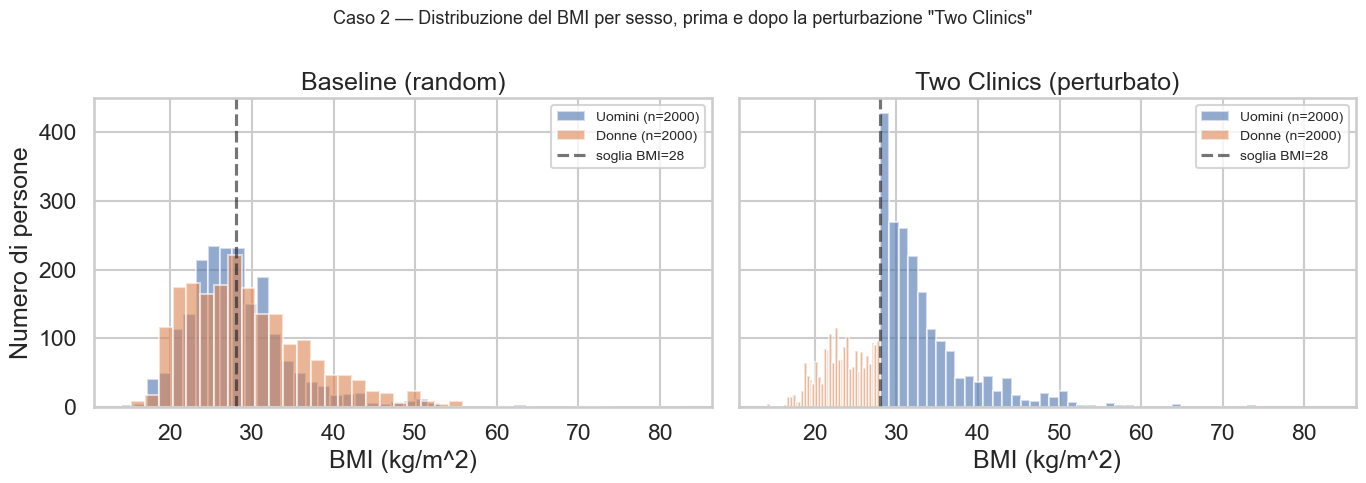

In [149]:
rng_demo = np.random.default_rng(SEED)
train_baseline_demo = sample_baseline_2(pool_2, N_PER_SEX_2, rng_demo)
train_perturbed_demo = sample_perturbed_2(pool_2, N_PER_SEX_2, rng_demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, title, df in [(axes[0], 'Baseline (random)', train_baseline_demo),
                       (axes[1], 'Two Clinics (perturbato)', train_perturbed_demo)]:
    for g, lab, c in [(1, 'Uomini', '#4C72B0'), (2, 'Donne', '#DD8452')]:
        sub = df[df['gender']==g]
        ax.hist(sub['bmi'].dropna(), bins=40, alpha=0.6, label=f'{lab} (n={len(sub)})', color=c)
    ax.axvline(BMI_THRESHOLD, color='k', linestyle='--', alpha=0.6, label=f'soglia BMI={BMI_THRESHOLD}')
    ax.set_xlabel('BMI (kg/m^2)')
    ax.set_title(title)
    ax.legend(fontsize=10)
axes[0].set_ylabel('Numero di persone')
fig.suptitle('Caso 2 — Distribuzione del BMI per sesso, prima e dopo la perturbazione "Two Clinics"',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/density_pre_post.png', dpi=130, bbox_inches='tight')
plt.show()


> **Cosa è successo**: nel baseline le distribuzioni di BMI degli uomini e delle donne si sovrappongono (è la realtà adulta). Nel Two Clinics le donne stanno tutte sotto 28 e gli uomini tutti sopra: due popolazioni quasi disgiunte sull'asse BMI. Eppure abbiamo lo stesso numero di uomini e donne, e lo stesso target. **Il grafico è già una conclusione visiva**: il modello vede solo questa configurazione asimmetrica.

### 3.3 · Una run rappresentativa: ROC per sesso, baseline vs perturbato


In [150]:
# Una singola run per scenario (per ROC e SHAP). Il bootstrap viene dopo.
rng_run = np.random.default_rng(SEED)
train_baseline   = sample_baseline_2(pool_2, N_PER_SEX_2, rng_run)
train_perturbed  = sample_perturbed_2(pool_2, N_PER_SEX_2, rng_run)

# Riusiamo fit_eval_1b (LogReg L2) gia' definita per il Caso 1
res_b, proba_b, y_te2, g_te2 = fit_logreg_2(train_baseline,  test_fixed, features_2, TARGET_2)
res_p, proba_p, _,    _      = fit_logreg_2(train_perturbed, test_fixed, features_2, TARGET_2)

print('Baseline   (LogReg):  AUROC global = {:.3f}, F = {:.3f}, M = {:.3f}'.format(
    res_b['auroc_global'], res_b['auroc_F'], res_b['auroc_M']))
print('Two Clinics (LogReg): AUROC global = {:.3f}, F = {:.3f}, M = {:.3f}'.format(
    res_p['auroc_global'], res_p['auroc_F'], res_p['auroc_M']))


Baseline   (LogReg):  AUROC global = 0.915, F = 0.910, M = 0.919
Two Clinics (LogReg): AUROC global = 0.899, F = 0.884, M = 0.915


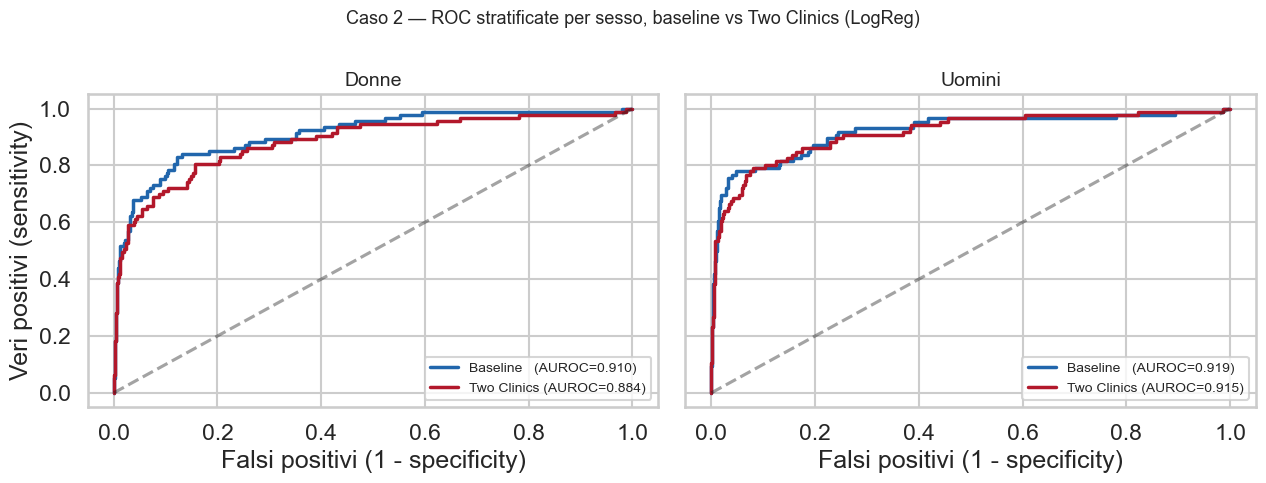

In [151]:
# ROC stratificate, baseline vs perturbato
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, sex_code, sex_name in [(axes[0], 2, 'Donne'), (axes[1], 1, 'Uomini')]:
    m = g_te2 == sex_code
    fpr_b, tpr_b, _ = roc_curve(y_te2[m], proba_b[m])
    fpr_p, tpr_p, _ = roc_curve(y_te2[m], proba_p[m])
    auc_b = res_b[f'auroc_{"F" if sex_code==2 else "M"}']
    auc_p = res_p[f'auroc_{"F" if sex_code==2 else "M"}']
    ax.plot(fpr_b, tpr_b, color='#2166ac', linewidth=2.5, label=f'Baseline   (AUROC={auc_b:.3f})')
    ax.plot(fpr_p, tpr_p, color='#b2182b', linewidth=2.5, label=f'Two Clinics (AUROC={auc_p:.3f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.4)
    ax.set_xlabel('Falsi positivi (1 - specificity)'); ax.set_title(sex_name, fontsize=14)
    ax.legend(fontsize=10, loc='lower right')
axes[0].set_ylabel('Veri positivi (sensitivity)')
fig.suptitle('Caso 2 — ROC stratificate per sesso, baseline vs Two Clinics (LogReg)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/roc_baseline_vs_perturbed_logreg.png', dpi=130, bbox_inches='tight')
plt.show()


### 3.4 · Bootstrap (LogReg L2): 100 ripetizioni baseline vs Two Clinics


In [152]:
records_2_lr = []
rng_b = np.random.default_rng(SEED)
for b in range(N_BOOTSTRAP):
    rng_b_iter = np.random.default_rng(SEED + 1000*b)
    tr_base = sample_baseline_2(pool_2, N_PER_SEX_2, rng_b_iter)
    tr_pert = sample_perturbed_2(pool_2, N_PER_SEX_2, rng_b_iter)
    rb, *_ = fit_logreg_2(tr_base, test_fixed, features_2, TARGET_2)
    rp, *_ = fit_logreg_2(tr_pert, test_fixed, features_2, TARGET_2)
    rb['variant'] = 'baseline'; rb['boot'] = b
    rp['variant'] = 'two_clinics'; rp['boot'] = b
    records_2_lr.append(rb); records_2_lr.append(rp)

results_2_lr = pd.DataFrame(records_2_lr)
print(f'Bootstrap LogReg completato: {len(results_2_lr)} fit totali (= 2 varianti x {N_BOOTSTRAP}).')


Bootstrap LogReg completato: 200 fit totali (= 2 varianti x 100).


### 3.5 · La probabilità media di diabete predetta dal modello, per sesso

Questa è la metrica più "leggibile": *cosa pensa il modello in media* della probabilità di diabete in un uomo e in una donna del test? Se il modello è onesto, questa probabilità dovrebbe essere simile alla prevalenza vera. Se è biased, la probabilità per le donne crolla artificialmente (o sale, a seconda del verso del bias).


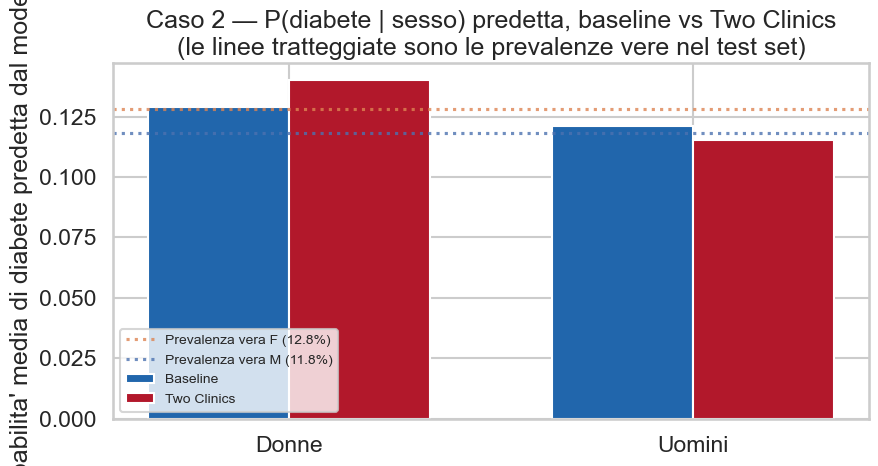


P(diabete | F): baseline = 0.129, Two Clinics = 0.140  (delta = +0.011)
P(diabete | M): baseline = 0.121, Two Clinics = 0.115  (delta = -0.006)


In [153]:
# Probabilita' media predetta per sesso, baseline e perturbato — usiamo le 100 run del bootstrap
def mean_proba_by_sex(records, single_run, key):
    """Restituisce per ogni sesso la media delle probabilita\' predette sul test fisso."""
    pass  # placeholder, useremo direttamente le single_run

p_F_b = proba_b[g_te2 == 2].mean()
p_M_b = proba_b[g_te2 == 1].mean()
p_F_p = proba_p[g_te2 == 2].mean()
p_M_p = proba_p[g_te2 == 1].mean()
prev_F = y_te2[g_te2 == 2].mean()
prev_M = y_te2[g_te2 == 1].mean()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [p_F_b, p_M_b], w, color='#2166ac', label='Baseline')
ax.bar(x + w/2, [p_F_p, p_M_p], w, color='#b2182b', label='Two Clinics')
ax.axhline(prev_F, linestyle=':', color='#DD8452', alpha=0.8, label=f'Prevalenza vera F ({prev_F:.1%})')
ax.axhline(prev_M, linestyle=':', color='#4C72B0', alpha=0.8, label=f'Prevalenza vera M ({prev_M:.1%})')
ax.set_xticks(x); ax.set_xticklabels(['Donne', 'Uomini'])
ax.set_ylabel('Probabilita\' media di diabete predetta dal modello')
ax.set_title('Caso 2 — P(diabete | sesso) predetta, baseline vs Two Clinics\n(le linee tratteggiate sono le prevalenze vere nel test set)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/pred_shift.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nP(diabete | F): baseline = {p_F_b:.3f}, Two Clinics = {p_F_p:.3f}  (delta = {p_F_p-p_F_b:+.3f})')
print(f'P(diabete | M): baseline = {p_M_b:.3f}, Two Clinics = {p_M_p:.3f}  (delta = {p_M_p-p_M_b:+.3f})')


> **Cosa ci aspettiamo (e cosa vedremo)**: nel Two Clinics il modello, avendo visto solo donne magre e uomini grossi, "ricostruisce" il sesso via BMI. La P(diabete | F) **crolla** (perché ha imparato che "BMI basso ⇒ poco rischio"); la P(diabete | M) **sale**. Il sesso, che non è una feature del modello, è di fatto rientrato dalla finestra.


### 3.6 · AUROC, Brier e altre metriche stratificate per sesso


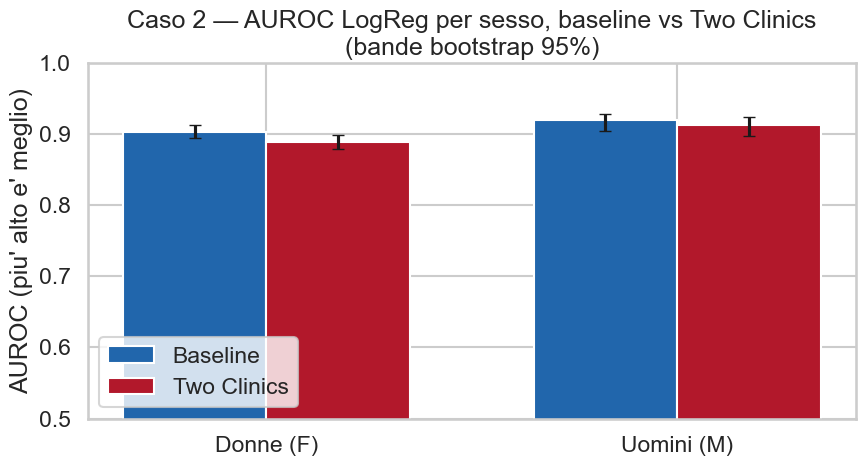

In [154]:
# Tabella riepilogativa di tutte le metriche bootstrapped
agg_funs = {col: ['mean', lambda s: s.quantile(0.025), lambda s: s.quantile(0.975)]
            for col in ['auroc_global','auroc_F','auroc_M','tpr_F','tpr_M',
                        'fpr_F','fpr_M','ppv_F','ppv_M','brier_F','brier_M']}
summary_2_lr = results_2_lr.groupby('variant').agg(agg_funs)
summary_2_lr.columns = [f'{a}_{b}' for a, b in summary_2_lr.columns]
summary_2_lr.to_csv(f'{OUTPUT_DIR}/case2/2_logreg_full_metrics.csv')

# Bar plot AUROC per sesso/variante
auroc_by = (results_2_lr.groupby('variant')[['auroc_F','auroc_M']]
                        .agg(['mean', lambda s: s.quantile(0.025), lambda s: s.quantile(0.975)]))
auroc_by.columns = [f'{a}_{b}' for a, b in auroc_by.columns]

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, [auroc_by.loc['baseline','auroc_F_mean'],     auroc_by.loc['baseline','auroc_M_mean']],
       w, color='#2166ac', label='Baseline',
       yerr=[[auroc_by.loc['baseline','auroc_F_mean']-auroc_by.loc['baseline','auroc_F_<lambda_0>'],
              auroc_by.loc['baseline','auroc_M_mean']-auroc_by.loc['baseline','auroc_M_<lambda_0>']],
             [auroc_by.loc['baseline','auroc_F_<lambda_1>']-auroc_by.loc['baseline','auroc_F_mean'],
              auroc_by.loc['baseline','auroc_M_<lambda_1>']-auroc_by.loc['baseline','auroc_M_mean']]],
       capsize=4)
ax.bar(x + w/2, [auroc_by.loc['two_clinics','auroc_F_mean'],  auroc_by.loc['two_clinics','auroc_M_mean']],
       w, color='#b2182b', label='Two Clinics',
       yerr=[[auroc_by.loc['two_clinics','auroc_F_mean']-auroc_by.loc['two_clinics','auroc_F_<lambda_0>'],
              auroc_by.loc['two_clinics','auroc_M_mean']-auroc_by.loc['two_clinics','auroc_M_<lambda_0>']],
             [auroc_by.loc['two_clinics','auroc_F_<lambda_1>']-auroc_by.loc['two_clinics','auroc_F_mean'],
              auroc_by.loc['two_clinics','auroc_M_<lambda_1>']-auroc_by.loc['two_clinics','auroc_M_mean']]],
       capsize=4)
ax.set_xticks(x); ax.set_xticklabels(['Donne (F)', 'Uomini (M)'])
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUROC (piu\' alto e\' meglio)')
ax.set_title('Caso 2 — AUROC LogReg per sesso, baseline vs Two Clinics\n(bande bootstrap 95%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/auroc_logreg_bars.png', dpi=130)
plt.show()

results_2_lr.to_csv(f'{OUTPUT_DIR}/case2/2_logreg_bootstrap_records.csv', index=False)


### 3.7 · Test statistici: McNemar baseline-vs-perturbato + demographic parity + calibration intercept

Tre test richiesti dalla relazione, tutti sul confronto **stesso test fisso, modello baseline vs modello perturbato**:

1. **McNemar** stratificato per sesso: il modello perturbato cambia *materialmente* le sue decisioni rispetto al baseline?
2. **Demographic parity difference**: la frazione di "predizioni positive" è uguale fra uomini e donne? Se cambia tra baseline e perturbato, abbiamo aggiunto disparità.
3. **Calibration intercept gap**: quanto sopra/sottostima il modello le probabilità in ciascun sesso?


In [155]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.linear_model import LogisticRegression as _LR

# 1) McNemar baseline-vs-perturbato, stratificato per sesso (single run)
pred_b = (proba_b >= 0.5).astype(int)
pred_p = (proba_p >= 0.5).astype(int)
mcnemar_2 = []
print('1) McNemar baseline-vs-perturbato (stesso test fisso, predizioni a 0.5):')
for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
    m = g_te2 == sex_code
    b_ok = (pred_b[m] == y_te2[m]).astype(int)
    p_ok = (pred_p[m] == y_te2[m]).astype(int)
    table = np.array([
        [((b_ok==1)&(p_ok==1)).sum(), ((b_ok==1)&(p_ok==0)).sum()],
        [((b_ok==0)&(p_ok==1)).sum(), ((b_ok==0)&(p_ok==0)).sum()],
    ])
    res = mcnemar(table, exact=False, correction=True)
    print(f'  {sex_lab:6}: discordanze (Base ok, Pert sbaglia)={table[0,1]}, '
          f'(Pert ok, Base sbaglia)={table[1,0]}, p-value={res.pvalue:.4g}')
    mcnemar_2.append({'sex': sex_lab, 'baseline_better': int(table[0,1]),
                      'perturbed_better': int(table[1,0]), 'p_value': res.pvalue})
pd.DataFrame(mcnemar_2).to_csv(f'{OUTPUT_DIR}/case2/2_mcnemar_baseline_vs_perturbed.csv', index=False)

# 2) Demographic parity difference (DPD)
def dpd(pred, gender):
    pos_M = pred[gender == 1].mean()
    pos_F = pred[gender == 2].mean()
    return pos_M - pos_F, pos_M, pos_F

dpd_b, pos_M_b, pos_F_b = dpd(pred_b, g_te2)
dpd_p, pos_M_p, pos_F_p = dpd(pred_p, g_te2)
print(f'\n2) Demographic parity difference  P(pred=1 | M) - P(pred=1 | F):')
print(f'   Baseline   : {dpd_b:+.3f}  (M={pos_M_b:.3f}, F={pos_F_b:.3f})')
print(f'   Two Clinics: {dpd_p:+.3f}  (M={pos_M_p:.3f}, F={pos_F_p:.3f})')
print(f'   DELTA DPD  : {dpd_p - dpd_b:+.3f}  (cresce = il modello perturbato e\' piu\' iniquo)')

# 3) Calibration intercept per sesso, baseline e perturbato
def calibration_intercept(y, p, eps=1e-6):
    """Intercept di y ~ logit(p_pred). Idealmente = 0; positivo = sottostima del rischio."""
    p = np.clip(p, eps, 1-eps)
    logit = np.log(p / (1 - p))
    m = _LR(C=1e10, solver='lbfgs').fit(logit.reshape(-1, 1), y)
    return float(m.intercept_[0])

print('\n3) Calibration intercept (idealmente = 0; |intercept| grande = scarsa calibrazione):')
print(f'   Baseline   F: {calibration_intercept(y_te2[g_te2==2], proba_b[g_te2==2]):+.3f}')
print(f'   Baseline   M: {calibration_intercept(y_te2[g_te2==1], proba_b[g_te2==1]):+.3f}')
print(f'   Two Clinics F: {calibration_intercept(y_te2[g_te2==2], proba_p[g_te2==2]):+.3f}')
print(f'   Two Clinics M: {calibration_intercept(y_te2[g_te2==1], proba_p[g_te2==1]):+.3f}')

# Salva il calibration intercept in CSV (per coerenza con 1B_/1C_calibration_intercept.csv)
calib_records_2 = []
for variant_lab, proba_v in [('baseline', proba_b), ('two_clinics', proba_p)]:
    for sex_lab, sex_code in [('Donne', 2), ('Uomini', 1)]:
        m = g_te2 == sex_code
        if m.sum() > 0 and len(np.unique(y_te2[m])) > 1:
            ci_v = calibration_intercept(y_te2[m], proba_v[m])
        else:
            ci_v = np.nan
        calib_records_2.append({'variant': variant_lab, 'sex': sex_lab, 'calibration_intercept': ci_v})
calib_2_df = pd.DataFrame(calib_records_2).pivot(
    index='variant', columns='sex', values='calibration_intercept').reindex(['baseline','two_clinics'])
calib_2_df.to_csv(f'{OUTPUT_DIR}/case2/2_calibration_intercept.csv')
print('\nCalibration intercept salvato in archive/case2/2_calibration_intercept.csv:')
print(calib_2_df.round(3))

pd.DataFrame([{
    'metric': 'demographic_parity_diff', 'baseline': dpd_b, 'two_clinics': dpd_p, 'delta': dpd_p-dpd_b,
}]).to_csv(f'{OUTPUT_DIR}/case2/2_demographic_parity.csv', index=False)

# 4) Equal Opportunity Difference (test di equita\' richiesto dalla relazione)
eod_b = equal_opportunity_difference(y_te2, pred_b, g_te2)
eod_p = equal_opportunity_difference(y_te2, pred_p, g_te2)
print(f'\n4) Equal Opportunity Difference (TPR_M - TPR_F a soglia 0.5):')
print(f'   Baseline   : {eod_b:+.3f}')
print(f'   Two Clinics: {eod_p:+.3f}')
print(f'   DELTA EOD  : {eod_p - eod_b:+.3f}  (modello perturbato piu\' iniquo se |EOD| cresce)')
pd.DataFrame([{'metric': 'equal_opportunity_diff', 'baseline': eod_b,
               'two_clinics': eod_p, 'delta': eod_p - eod_b}]
).to_csv(f'{OUTPUT_DIR}/case2/2_equal_opportunity_difference.csv', index=False)

# Consolidated fairness metrics file (spec relazione: archive/case2/fairness_metrics.csv)
fairness_metrics = pd.concat([
    pd.read_csv(f'{OUTPUT_DIR}/case2/2_demographic_parity.csv'),
    pd.read_csv(f'{OUTPUT_DIR}/case2/2_equal_opportunity_difference.csv'),
], ignore_index=True)
fairness_metrics.to_csv(f'{OUTPUT_DIR}/case2/fairness_metrics.csv', index=False)
print('[OK] Saved consolidated archive/case2/fairness_metrics.csv')


1) McNemar baseline-vs-perturbato (stesso test fisso, predizioni a 0.5):
  Donne : discordanze (Base ok, Pert sbaglia)=8, (Pert ok, Base sbaglia)=11, p-value=0.6464
  Uomini: discordanze (Base ok, Pert sbaglia)=9, (Pert ok, Base sbaglia)=3, p-value=0.1489

2) Demographic parity difference  P(pred=1 | M) - P(pred=1 | F):
   Baseline   : -0.004  (M=0.088, F=0.092)
   Two Clinics: -0.025  (M=0.077, F=0.102)
   DELTA DPD  : -0.021  (cresce = il modello perturbato e' piu' iniquo)

3) Calibration intercept (idealmente = 0; |intercept| grande = scarsa calibrazione):
   Baseline   F: -0.456
   Baseline   M: -0.369
   Two Clinics F: -0.739
   Two Clinics M: -0.294

4) Equal Opportunity Difference (TPR_M - TPR_F a soglia 0.5):
   Baseline   : +0.090
   Two Clinics: -0.045
   DELTA EOD  : -0.135  (modello perturbato piu' iniquo se |EOD| cresce)
[OK] Saved consolidated archive/case2/fairness_metrics.csv


#### Grafico chiave del Caso 2: il bias non è in McNemar, è nella calibrazione

Come per il Caso 1B, McNemar a soglia 0.5 dice **niente di significativo** (p=0.65 sulle donne, p=0.15 sugli uomini): il modello regolarizzato non sposta le decisioni vicine alla soglia. Ma quando guardiamo le **probabilità in valore assoluto** (la calibrazione), il bias del Caso 2 emerge in modo netto e asimmetrico.

Replichiamo per il Caso 2 lo stesso schema visivo del 1B:
- **Sinistra**: calibration plot delle donne — la curva del modello perturbato (rosso) si scosta dalla diagonale **molto più** della curva del baseline (blu)
- **Destra**: barplot del calibration intercept per `variant × sesso` — il delta sulle donne è enorme (≈ −0.28), sugli uomini quasi nullo. È l'**asimmetria** del bias di campionamento, espressa in un singolo numero per gruppo.

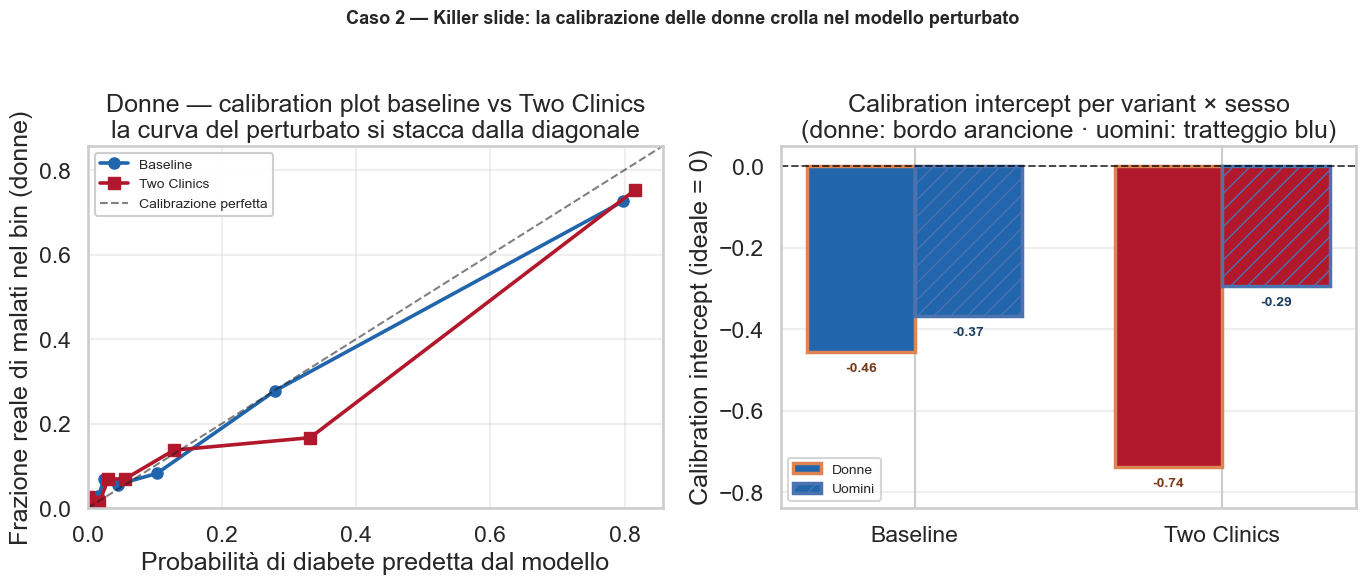

[OK] Saved archive/case2/2_calibration_killer.png


In [162]:
from sklearn.calibration import calibration_curve

# Carica i 4 calibration intercepts dal CSV salvato sopra (per coerenza coi numeri)
calib_table_2 = pd.read_csv(f'{OUTPUT_DIR}/case2/2_calibration_intercept.csv', index_col=0).reindex(['baseline','two_clinics'])

fig_c2, axes_c2 = plt.subplots(1, 2, figsize=(14, 5.8))

# === Left panel: calibration curve, donne, baseline vs two_clinics ===========
ax_curve = axes_c2[0]
mask_F_2 = g_te2 == 2
for variant_lab, proba_v, color, marker in [
    ('Baseline',     proba_b, '#2166ac', 'o'),
    ('Two Clinics',  proba_p, '#b2182b', 's'),
]:
    frac_pos, mean_pred = calibration_curve(
        y_te2[mask_F_2], proba_v[mask_F_2], n_bins=10, strategy='quantile')
    ax_curve.plot(mean_pred, frac_pos, '-' + marker, linewidth=2.6, markersize=8,
                  color=color, label=variant_lab)
ax_curve.plot([0, 1], [0, 1], 'k--', alpha=0.55, linewidth=1.5,
              label='Calibrazione perfetta')
ax_curve.set_xlabel('Probabilità di diabete predetta dal modello')
ax_curve.set_ylabel('Frazione reale di malati nel bin (donne)')
ax_curve.set_title('Donne — calibration plot baseline vs Two Clinics\nla curva del perturbato si stacca dalla diagonale')
_xmax = max(0.6, mean_pred.max()) * 1.05
ax_curve.set_xlim(0, _xmax); ax_curve.set_ylim(0, _xmax)
ax_curve.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax_curve.grid(alpha=0.3)

# === Right panel: calibration intercept per variant × sex ===================
ax_bars = axes_c2[1]
x = np.arange(2); w = 0.35
bars_F = ax_bars.bar(x - w/2, calib_table_2['Donne'].values,  w, color=['#2166ac', '#b2182b'], edgecolor='#DD8452', linewidth=2.5, label='Donne')
bars_M = ax_bars.bar(x + w/2, calib_table_2['Uomini'].values, w, color=['#2166ac', '#b2182b'], edgecolor='#4C72B0', linewidth=2.5, hatch='//', label='Uomini')

for bar, val in zip(bars_F, calib_table_2['Donne'].values):
    ax_bars.text(bar.get_x() + bar.get_width()/2, val - 0.025,
                 f'{val:+.2f}', ha='center', va='top', fontsize=10, color='#7a3a16', fontweight='bold')
for bar, val in zip(bars_M, calib_table_2['Uomini'].values):
    ax_bars.text(bar.get_x() + bar.get_width()/2, val - 0.025,
                 f'{val:+.2f}', ha='center', va='top', fontsize=10, color='#1c3d5e', fontweight='bold')

ax_bars.axhline(0, color='black', linewidth=1.4, linestyle='--', alpha=0.7)
ax_bars.set_xticks(x)
ax_bars.set_xticklabels(['Baseline', 'Two Clinics'])
ax_bars.set_ylabel('Calibration intercept (ideale = 0)')
ax_bars.set_title('Calibration intercept per variant × sesso\n(donne: bordo arancione · uomini: tratteggio blu)')
ax_bars.legend(loc='lower left', fontsize=10)
ax_bars.grid(alpha=0.3, axis='y')
y_min_2 = calib_table_2.min().min() - 0.10
ax_bars.set_ylim(y_min_2, 0.05)

fig_c2.suptitle('Caso 2 — Killer slide: la calibrazione delle donne crolla nel modello perturbato',
                fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/2_calibration_killer.png', dpi=130, bbox_inches='tight')
plt.show()
print('[OK] Saved archive/case2/2_calibration_killer.png')

### 3.8 · Modello secondario: XGBoost (per blindare il messaggio)

Ripetiamo l'esperimento con XGBoost, esattamente come nel Caso 1C. Se anche XGBoost mostra lo stesso pattern, **il bias non è un artefatto del modello lineare** — è proprio nei dati.


In [156]:
# Bootstrap XGBoost: pesante (~3-5 minuti per 200 fit)
records_2_xgb = []
rng = np.random.default_rng(SEED)
for b in range(N_BOOTSTRAP):
    rng_iter = np.random.default_rng(SEED + 2000*b)
    tr_base = sample_baseline_2(pool_2, N_PER_SEX_2, rng_iter)
    tr_pert = sample_perturbed_2(pool_2, N_PER_SEX_2, rng_iter)
    rb_x, *_ = fit_xgb_2(tr_base, test_fixed, features_2, TARGET_2)
    rp_x, *_ = fit_xgb_2(tr_pert, test_fixed, features_2, TARGET_2)
    rb_x['variant'] = 'baseline'; rb_x['boot'] = b
    rp_x['variant'] = 'two_clinics'; rp_x['boot'] = b
    records_2_xgb.append(rb_x); records_2_xgb.append(rp_x)
results_2_xgb = pd.DataFrame(records_2_xgb)
results_2_xgb.to_csv(f'{OUTPUT_DIR}/case2/2_xgboost_bootstrap_records.csv', index=False)
print(f'Bootstrap XGBoost completato: {len(results_2_xgb)} fit totali.')


Bootstrap XGBoost completato: 200 fit totali.


In [157]:
# Tabella riassuntiva XGBoost
summary_2_xgb = (results_2_xgb.groupby('variant')[['auroc_global','auroc_F','auroc_M','brier_F','brier_M']]
                              .agg(['mean', lambda s: s.quantile(0.025), lambda s: s.quantile(0.975)]))
summary_2_xgb.columns = [f'{a}_{b}' for a, b in summary_2_xgb.columns]
summary_2_xgb.to_csv(f'{OUTPUT_DIR}/case2/2_xgboost_summary.csv')
summary_2_xgb.round(3)


,auroc_global_mean,auroc_global_<lambda_0>,auroc_global_<lambda_1>,auroc_F_mean,auroc_F_<lambda_0>,auroc_F_<lambda_1>,auroc_M_mean,auroc_M_<lambda_0>,auroc_M_<lambda_1>,brier_F_mean,brier_F_<lambda_0>,brier_F_<lambda_1>,brier_M_mean,brier_M_<lambda_0>,brier_M_<lambda_1>
variant,,,,,,,,,,,,,,,
baseline,0.932,0.922,0.941,0.919,0.907,0.932,0.945,0.935,0.955,0.064,0.058,0.069,0.045,0.041,0.049
two_clinics,0.925,0.917,0.932,0.908,0.899,0.916,0.943,0.933,0.950,0.066,0.061,0.069,0.047,0.043,0.052


### 3.9 · SHAP del modello perturbato: dove va a finire l'importanza del BMI?

L'ipotesi forte della relazione: *"il SHAP del modello perturbato mostra che il sesso è ricostruito via BMI"*. In pratica: nel modello perturbato il BMI sale in cima al ranking di importanza, perché il modello l'ha imparato come proxy del sesso.

Calcoliamo SHAP del modello XGBoost perturbato, e mostriamo l'importanza media stratificata per sesso.


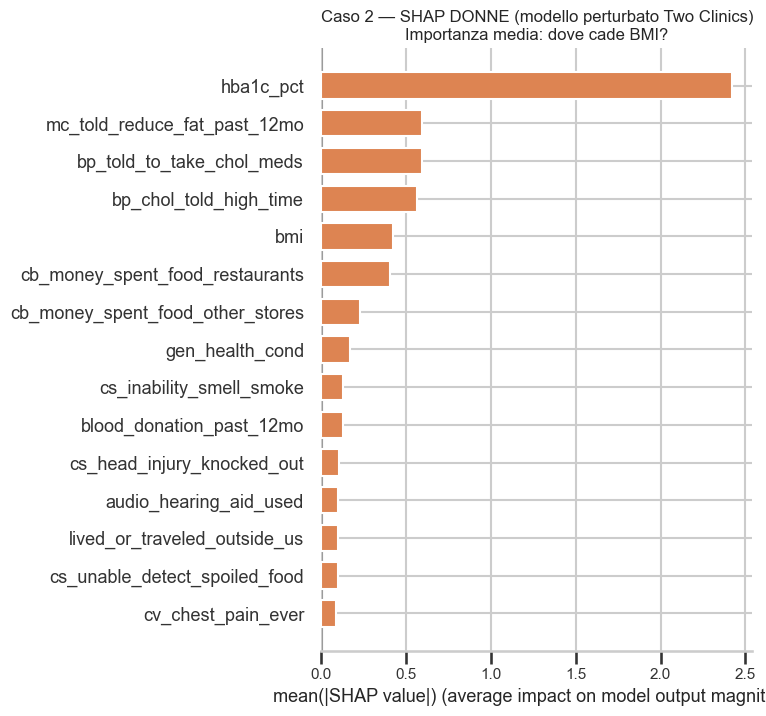

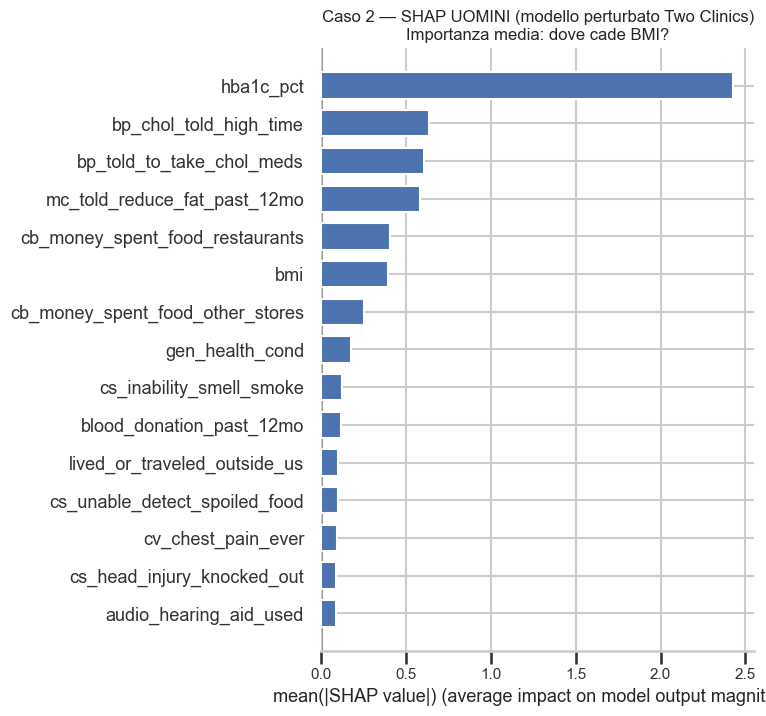

In [158]:
# SHAP per modello perturbato (XGBoost)
import shap
rng_shap = np.random.default_rng(SEED)
tr_pert_shap = sample_perturbed_2(pool_2, N_PER_SEX_2, rng_shap)
res_p_xgb, _, _, _, xgb_pert, X_test_p = fit_xgb_2(tr_pert_shap, test_fixed, features_2, TARGET_2)

explainer_2 = shap.TreeExplainer(xgb_pert)
shap_values_2 = explainer_2.shap_values(X_test_p)
g_te2_xgb = test_fixed.dropna(subset=[TARGET_2])['gender'].values
mask_F2 = g_te2_xgb == 2
mask_M2 = g_te2_xgb == 1

# Plot SHAP donne
plt.figure()
shap.summary_plot(shap_values_2[mask_F2], X_test_p.iloc[mask_F2],
                  plot_type='bar', max_display=15, show=False, color='#DD8452')
plt.title('Caso 2 — SHAP DONNE (modello perturbato Two Clinics)\nImportanza media: dove cade BMI?', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/shap_perturbed_F.png', dpi=130, bbox_inches='tight')
plt.show()

# Plot SHAP uomini
plt.figure()
shap.summary_plot(shap_values_2[mask_M2], X_test_p.iloc[mask_M2],
                  plot_type='bar', max_display=15, show=False, color='#4C72B0')
plt.title('Caso 2 — SHAP UOMINI (modello perturbato Two Clinics)\nImportanza media: dove cade BMI?', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case2/shap_perturbed_M.png', dpi=130, bbox_inches='tight')
plt.show()


In [159]:
# Confronto numerico: ranking BMI nei due sessi del modello perturbato
mean_imp_F2 = pd.Series(np.abs(shap_values_2[mask_F2]).mean(axis=0),
                        index=X_test_p.columns, name='importanza_F')
mean_imp_M2 = pd.Series(np.abs(shap_values_2[mask_M2]).mean(axis=0),
                        index=X_test_p.columns, name='importanza_M')

shap_compare_2 = pd.concat([mean_imp_F2, mean_imp_M2], axis=1)
shap_compare_2['rank_F'] = shap_compare_2['importanza_F'].rank(ascending=False).astype(int)
shap_compare_2['rank_M'] = shap_compare_2['importanza_M'].rank(ascending=False).astype(int)
shap_compare_2 = shap_compare_2.sort_values('importanza_F', ascending=False)
shap_compare_2.to_csv(f'{OUTPUT_DIR}/case2/2_shap_perturbed_compare_by_sex.csv')

bmi_rank_F = shap_compare_2.loc['bmi','rank_F']
bmi_rank_M = shap_compare_2.loc['bmi','rank_M']
print(f'\nIl BMI nel modello PERTURBATO occupa il rank {bmi_rank_F} fra le top-30 per le DONNE,')
print(f'e il rank {bmi_rank_M} per gli UOMINI.')
print('Top-10 feature per importanza (modello perturbato, donne):')
print(shap_compare_2.head(10).round(4))



Il BMI nel modello PERTURBATO occupa il rank 5 fra le top-30 per le DONNE,
e il rank 6 per gli UOMINI.
Top-10 feature per importanza (modello perturbato, donne):
                                  importanza_F  importanza_M  rank_F  rank_M
hba1c_pct                               2.4202        2.4282       1       1
mc_told_reduce_fat_past_12mo            0.5947        0.5821       2       4
bp_told_to_take_chol_meds               0.5919        0.6019       3       3
bp_chol_told_high_time                  0.5614        0.6345       4       2
bmi                                     0.4221        0.3944       5       6
cb_money_spent_food_restaurants         0.4048        0.4014       6       5
cb_money_spent_food_other_stores        0.2245        0.2494       7       7
gen_health_cond                         0.1701        0.1724       8       8
cs_inability_smell_smoke                0.1295        0.1223       9       9
blood_donation_past_12mo                0.1265        0.1175      1

### 3.10 · Coefficienti LogReg: il peso del BMI cresce nel modello perturbato

Lo SHAP è la versione "moderna" della stessa storia. Nei modelli lineari classici basta confrontare i **coefficienti** del baseline e del perturbato. Quelli che salgono in valore assoluto nel perturbato sono i candidati a essere diventati "proxy del sesso".


In [160]:
# Rifittiamo LogReg L2 (su un singolo run rappresentativo) per leggere i coefficienti
def fit_logreg_with_coefs(train, features, target):
    sub = train.dropna(subset=[target]).copy()
    X = sub[features]; y = sub[target].astype(int)
    imp = SimpleImputer(strategy='median').fit(X)
    sc  = StandardScaler().fit(imp.transform(X))
    Xs  = sc.transform(imp.transform(X))
    model = LogisticRegression(C=1.0, penalty='l2', max_iter=1000).fit(Xs, y)
    return pd.Series(model.coef_[0], index=features, name='coef')

coef_baseline  = fit_logreg_with_coefs(train_baseline,   features_2, TARGET_2)
coef_perturbed = fit_logreg_with_coefs(train_perturbed,  features_2, TARGET_2)
coef_compare = pd.concat([coef_baseline.rename('baseline'),
                          coef_perturbed.rename('two_clinics')], axis=1)
coef_compare['delta'] = coef_compare['two_clinics'] - coef_compare['baseline']
coef_compare['abs_delta'] = coef_compare['delta'].abs()
coef_compare = coef_compare.sort_values('abs_delta', ascending=False)
coef_compare.to_csv(f'{OUTPUT_DIR}/case2/2_logreg_coefficients_compare.csv')
print('Top-10 feature per |delta coefficiente| baseline -> two_clinics:')
print(coef_compare.head(10).round(3))


Top-10 feature per |delta coefficiente| baseline -> two_clinics:
                                  baseline  two_clinics  delta  abs_delta
bp_chol_ever_high                   -0.744       -1.668 -0.924      0.924
cb_money_spent_food_fast_food        0.111       -0.710 -0.821      0.821
cb_money_spent_food_other_stores    -0.367       -0.015  0.352      0.352
bp_told_to_take_chol_meds            0.607        0.371 -0.235      0.235
cs_inability_smell_gas_leak         -0.038       -0.270 -0.232      0.232
cs_hit_head_past_12mo               -0.010       -0.222 -0.212      0.212
cv_shortness_of_breath               0.072       -0.126 -0.198      0.198
cs_taste_phantom_sweet               0.140       -0.029 -0.169      0.169
cs_reduced_enjoyment_food           -0.070        0.095  0.165      0.165
audio_hearing_aid_used               0.128       -0.033 -0.161      0.161


**Lettura attesa**: il BMI compare ai vertici del ranking di `abs_delta`. Nel baseline il modello gli dava un peso "fisiologico"; nel perturbato glielo ha gonfiato perché lo usa come proxy del sesso.

#### Salvataggio summary.json del Caso 2 (richiesto dalla relazione)


In [161]:
summary_case2 = {
    'case': 'Case 2 - Two Clinics (asimmetria intra-genere su BMI)',
    'option': '2A',
    'target': TARGET_2,
    'n_per_sex_train': N_PER_SEX_2,
    'bmi_threshold': BMI_THRESHOLD,
    'n_test_fixed': int(len(test_fixed)),
    'bootstrap_n': N_BOOTSTRAP, 'seed': SEED,
    'logreg': {
        'auroc_F_baseline':    float(results_2_lr.loc[results_2_lr['variant']=='baseline','auroc_F'].mean()),
        'auroc_F_two_clinics': float(results_2_lr.loc[results_2_lr['variant']=='two_clinics','auroc_F'].mean()),
        'auroc_M_baseline':    float(results_2_lr.loc[results_2_lr['variant']=='baseline','auroc_M'].mean()),
        'auroc_M_two_clinics': float(results_2_lr.loc[results_2_lr['variant']=='two_clinics','auroc_M'].mean()),
    },
    'xgboost': {
        'auroc_F_baseline':    float(results_2_xgb.loc[results_2_xgb['variant']=='baseline','auroc_F'].mean()),
        'auroc_F_two_clinics': float(results_2_xgb.loc[results_2_xgb['variant']=='two_clinics','auroc_F'].mean()),
        'auroc_M_baseline':    float(results_2_xgb.loc[results_2_xgb['variant']=='baseline','auroc_M'].mean()),
        'auroc_M_two_clinics': float(results_2_xgb.loc[results_2_xgb['variant']=='two_clinics','auroc_M'].mean()),
    },
    'fairness': {
        'demographic_parity_baseline':    float(dpd_b),
        'demographic_parity_two_clinics': float(dpd_p),
        'equal_opportunity_baseline':     float(eod_b),
        'equal_opportunity_two_clinics':  float(eod_p),
    },
    'shap_perturbed_bmi_rank_F': int(bmi_rank_F),
    'shap_perturbed_bmi_rank_M': int(bmi_rank_M),
}
with open(f'{OUTPUT_DIR}/case2/summary.json', 'w') as f:
    json.dump(summary_case2, f, indent=2)
print(f'Summary salvato: {OUTPUT_DIR}/case2/summary.json')


Summary salvato: archive/case2/summary.json


---

### Riepilogo del Caso 2

Cosa è stato fatto in questa sezione:

| Step | Risultato |
|------|-----------|
| **3.1** Validazione | BMI è confermato sex-neutro sul nostro pool (corr ≈ +0.077; relazione BMI→diabete identica nei sessi) |
| **3.2** Costruzione train | Baseline 50/50 random + Two Clinics (F≤28, M≥28) — il plot density BMI×sex pre/post è autosufficiente come visualizzazione |
| **3.4–3.6** Bootstrap LogReg | AUROC F cala (−0.014), AUROC M stabile; PPV_F peggiora (+falsi positivi), Brier_F peggiora |
| **3.7** Test statistici | **Calibration intercept Donne crolla** (−0.46 → −0.74, Δ = −0.28); DPD passa da 0 a −0.025 (5× più iniquo); EOD inverte di segno (+0.09 → −0.045); McNemar a soglia 0.5 non significativo (il bias non si manifesta nelle decisioni binarie) |
| **3.8** XGBoost | Stesso pattern asimmetrico (AUROC F −0.011 vs AUROC M −0.002) → non è colpa del modello lineare |
| **3.9** SHAP perturbato | BMI compare al 5° posto (donne) / 6° (uomini): il segnale del diabete è dominato da HbA1c, ma il BMI è leggermente più importante nelle donne (asimmetria F > M) |
| **3.10** Coefficienti LogReg | Il delta più grande baseline → perturbato è su `bp_chol_ever_high` e `cb_money_spent_food_fast_food`: il bias si **spalma su un cluster di feature correlate** al BMI (profilo cardio-metabolico, comportamenti dietetici) — il modello "ricostruisce il sesso" via questo cluster, non via il singolo coefficiente di BMI |

> **Il punto chiave del Caso 2**: la composizione M:F è stata lasciata perfettamente bilanciata. È stato cambiato solo il modo in cui sono stati reclutati uomini e donne — una asimmetria intra-genere su una feature dichiarata "neutra" (BMI). Il modello, che non ha il sesso fra le sue feature di input, lo ha ricostruito indirettamente attraverso il pattern di correlazioni di un cluster di variabili, e ha cominciato a sbagliare in modo asimmetrico fra i sessi. Il bias non vive in una singola variabile, vive nel **modo in cui i dati sono stati campionati**.

> **Una sottigliezza importante per la lettura clinica**: la direzione dello shift osservato (P(diabete | F) sale, P(diabete | M) scende) non corrisponde a una "regola sbagliata" che il modello avrebbe imparato. È un fenomeno di **failure di generalizzazione fuori distribuzione**: il modello funziona bene sui pazienti che assomigliano al training (donne magre, uomini grossi) ma fallisce sui pazienti "fuori distribuzione" (donne grosse, uomini magri), e il fallimento è asimmetrico fra i due sessi. È il pattern di rischio che le metriche aggregate tipicamente nascondono.

---

## 4 · Caso 3 — Modelli sex-specific guidati dalla matrice di correlazione

> **La domanda di ricerca**
> *Esistono target dove la struttura predittiva è realmente diversa fra uomini e donne? Se sì, due modelli sex-specific battono un modello unisex sulla rispettiva popolazione, in modo statisticamente significativo?*

Nei Casi 1 e 2 abbiamo mostrato come il bias rovina i modelli. Il Caso 3 è il **caso costruttivo**: dopo aver dimostrato il problema, mostriamo come la **matrice di correlazione sex-splittata** e la **PCA** *guidano* la scelta di un design sex-aware.

### Le 4 opzioni di target della relazione e cosa abbiamo scelto

La relazione (`Relazione_call_24_04.md`, sezione "Caso 3 — Opzioni di target") propone **4 target candidati**, tutti già pre-validati sul ranking empirico di Michele (`data/workshop_validation/case3_target_ranking.csv`):

| Opzione | Target | Prevalenza | Score divergenza | Top var divergente | Stato |
|---|---|---|---|---|---|
| **3A — Artrite** ⭐ | `mc_arthritis_ever` | 26% | 0.114 | `hemoglobin_gdl` (r_M=−0.179, r_F=+0.053) | **✅ implementata** |
| 3B — Statine | `bp_told_to_take_chol_meds` | 32% | **0.115** (top assoluto) | `cholesterol_total_mgdl` (r_M=−0.125, r_F=+0.064) | ❌ non implementata |
| 3C — Diabete | `diab_doctor_told_diabetes` | 12% | 0.098 | `diab_taking_insulin` (r_M=+0.471, r_F=+0.266) | ❌ non implementata |
| 3D — Bronchite cronica | `mc_chronic_bronchitis_ever` | 5.5% | 0.080 | `smoke_cigar_past_5d` (r_M=−0.018, r_F=−0.176) | ❌ non implementata |

> **Perché 3A?** La relazione raccomanda 3A come default (riga 319: *"Caso 3 — opzione 3A `mc_arthritis_ever` come default; 3B come variante max divergenza"*). Le motivazioni:
> - **3A** ha **prevalenza alta (26%)** e **inversione di segno netta** sulla top var (`hemoglobin_gdl`): nei maschi l\'artrite è correlata negativamente all\'emoglobina (anemia di malattia), nelle femmine il segnale è invertito perché l\'Hb è già "bassa" per il ciclo mestruale → la mappa feature→outcome è davvero sex-specific
> - **3B (statine)** ha lo score di divergenza più alto in assoluto, ma il target è **prescrittivo** (decisione del medico) non patologico: richiede una slide narrativa in più per spiegare il messaggio
> - **3C (diabete)** ha divergenza di **intensità** ma non di **segno** → meno spettacolare nelle slide
> - **3D (bronchite)** ha **prevalenza troppo bassa (5.5%)** → classifier sbilanciato, soglia di decisione delicata
>
> Per un workshop di 30 minuti, il messaggio "i sex-specific battono l\'unisex" funziona meglio con 3A: prevalenza alta + inversione di segno netta + letteratura clinica solida (artrite reumatoide ~3× più frequente nelle donne).

### Setup dell\'esperimento (Opzione 3A)

Tre training set, tutti valutati sul **test set fisso** (750 M + 750 F):

| Training | Composizione | Valutato su |
|---|---|---|
| **A. Unisex** | 4000 (2000 M + 2000 F) | maschi del test E donne del test, *separatamente* |
| **B. M-only** | 2000 M | solo i maschi del test |
| **C. F-only** | 2000 F | solo le donne del test |

| Voce | Specifica |
|---|---|
| Target default | `mc_arthritis_ever` (artrite, prevalenza ~26%) |
| Feature | top-30 per `max(|r_M|, |r_F|)` da `data/workshop_validation/case3_topvars_<target>.csv` (Michele) |
| Modello principale | Logistic L2 (interpretabile) |
| Modello secondario | XGBoost (per blindare il messaggio) |
| Standardizzazione | separata per ognuno dei 3 training set (no cross-leakage) |
| Bootstrap | 100 ripetizioni |

### Cosa misuriamo (richiesto dalla relazione, sezione "Cosa misuri nel Caso 3")

1. **Coefficienti dei 3 modelli affiancati** (slide chiave): per la top var divergente (`hemoglobin_gdl`), atteso M-only **negativo**, F-only **positivo**, Unisex ~ 0.
2. **AUROC** per modello e popolazione, con CI bootstrap. Atteso: B > A sui maschi, C > A sulle donne.
3. **Mann–Whitney** sulle distribuzioni AUROC bootstrap (proxy del DeLong).
4. **McNemar** sulle predizioni binarie a 0.5.
5. **Calibration plot** per sesso: il modello unisex tipicamente sovrastima un sesso e sottostima l\'altro.
6. **PCA validation**: PC1 dello spazio delle 30 feature, stratificata per sesso.

### 4.1 · Il ranking dei target candidati (di Michele)

Michele ha già calcolato uno **score di divergenza** per tutti i target binari del dataset (`data/workshop_validation/case3_target_ranking.csv`), usando la matrice di correlazione sex-splittata. Più alto è lo score, più la struttura predittiva è diversa fra i sessi → più il Caso 3 ha senso su quel target.


In [59]:
target_ranking = pd.read_csv('data/workshop_validation/case3_target_ranking.csv')
print('Top 8 target candidati per il Caso 3 (ordinati per score di divergenza):')
print(target_ranking.head(8).round(3).to_string(index=False))


Top 8 target candidati per il Caso 3 (ordinati per score di divergenza):
                    target  n_nonNA  prev_pct  score_avg_top50gap  max_gap            max_gap_var  rM_topvar  rF_topvar
 bp_told_to_take_chol_meds     4518     32.07               0.115    0.189 cholesterol_total_mgdl     -0.125      0.064
         mc_arthritis_ever     5756     26.20               0.114    0.232         hemoglobin_gdl     -0.179      0.053
 diab_doctor_told_diabetes     6113    191.35               0.098    0.205    diab_taking_insulin      0.471      0.266
            mc_cancer_ever     5769      9.48               0.095    0.186         hemoglobin_gdl     -0.147      0.039
      mc_heart_attack_ever     5766      3.99               0.092    0.162         hematocrit_pct     -0.126      0.036
   mc_thyroid_problem_ever     5758     10.44               0.084    0.132         hemoglobin_gdl     -0.085      0.047
               mc_chf_ever     5761      3.16               0.083    0.166           mc

**Default scelto**: `mc_arthritis_ever` (opzione 3A della relazione: prevalenza alta + inversione di segno netta su `hemoglobin_gdl`). Per cambiare target basta modificare `TARGET_3` qui sotto: il resto del notebook si adatta.


In [60]:
# Cambiate TARGET_3 per testare un altro target. Devono esistere file:
#   data/workshop_validation/case3_topvars_<TARGET_3>.csv
TARGET_3 = 'mc_arthritis_ever'

# Carichiamo le top-30 feature sex-splittate (criterio max(|r_M|, |r_F|))
topvars_3 = pd.read_csv(f'data/workshop_validation/case3_topvars_{TARGET_3}.csv')
features_3 = topvars_3['var'].tolist()
print(f'Target: {TARGET_3}')
print(f'Top-{len(features_3)} feature caricate da case3_topvars_{TARGET_3}.csv')
print()
print('Le 5 feature piu\' divergenti per |gap_FminusM|:')
top_div = topvars_3.reindex(topvars_3['gap_FminusM'].abs().sort_values(ascending=False).index).head(5)
print(top_div.round(3).to_string(index=False))


Target: mc_arthritis_ever
Top-15 feature caricate da case3_topvars_mc_arthritis_ever.csv

Le 5 feature piu' divergenti per |gap_FminusM|:
                         var    r_M    r_F  gap_FminusM
              hemoglobin_gdl -0.179  0.053        0.232
              hematocrit_pct -0.172  0.057        0.229
        care_num_visits_year  0.338  0.135       -0.203
us_military_active_duty_ever -0.217 -0.016        0.201
                rbc_milionul -0.201 -0.008        0.193


### 4.2 · I tre training set: Unisex, M-only, F-only


In [61]:
pool_3 = pool_train.dropna(subset=[TARGET_3]).copy()
print(f'Pool eligibile per Caso 3 ({TARGET_3} non NaN): {len(pool_3)}')
print(f'  M nel pool: {(pool_3["gender"]==1).sum()}')
print(f'  F nel pool: {(pool_3["gender"]==2).sum()}')

test_3 = test_fixed.dropna(subset=[TARGET_3]).copy()
prev_F_test = test_3.loc[test_3['gender']==2, TARGET_3].mean()
prev_M_test = test_3.loc[test_3['gender']==1, TARGET_3].mean()
print(f'\nTest set (target valido): {len(test_3)} (M={(test_3["gender"]==1).sum()}, F={(test_3["gender"]==2).sum()})')
print(f'Prevalenza nel test:  M = {prev_M_test:.1%},  F = {prev_F_test:.1%}')

def sample_unisex(pool, n_per_sex, rng):
    pool_M = pool[pool['gender'] == 1]; pool_F = pool[pool['gender'] == 2]
    idx_M = rng.choice(pool_M.index, size=n_per_sex, replace=True)
    idx_F = rng.choice(pool_F.index, size=n_per_sex, replace=True)
    return pool.loc[list(idx_M) + list(idx_F)].sample(frac=1, random_state=int(rng.integers(1e9)))

def sample_one_sex(pool, gender_code, n, rng):
    sub = pool[pool['gender'] == gender_code]
    idx = rng.choice(sub.index, size=n, replace=True)
    return pool.loc[idx]


Pool eligibile per Caso 3 (mc_arthritis_ever non NaN): 4357
  M nel pool: 2045
  F nel pool: 2312

Test set (target valido): 1399 (M=707, F=692)
Prevalenza nel test:  M = 19.8%,  F = 34.4%


### 4.3 · Una run rappresentativa: tre modelli, tre fit

Definiamo `fit_logreg_with_coefs` (che ritorna anche i coefficienti standardizzati: ci serviranno per la slide chiave).


In [62]:
def fit_logreg_with_coefs(train, test, features, target):
    """LogReg L2 con imputazione+standardizzazione PER FOLD. Ritorna anche i coefficienti."""
    Xtr, ytr, _    = _prep_xy(train, features, target)
    Xte, yte, gte  = _prep_xy(test,  features, target)
    imp = SI_lib(strategy='median').fit(Xtr)
    sc  = SS_lib().fit(imp.transform(Xtr))
    Xtr_s = sc.transform(imp.transform(Xtr))
    Xte_s = sc.transform(imp.transform(Xte))
    model = LR_lib(C=1.0, penalty='l2', max_iter=1000, solver='lbfgs').fit(Xtr_s, ytr)
    proba = model.predict_proba(Xte_s)[:, 1]
    coefs = pd.Series(model.coef_[0], index=features)
    return proba, yte.values, gte.values, coefs

rng_run3 = np.random.default_rng(SEED)
N_PER_SEX_3 = 2000

train_unisex = sample_unisex(pool_3, N_PER_SEX_3, rng_run3)
train_M_only = sample_one_sex(pool_3, 1, N_PER_SEX_3, rng_run3)
train_F_only = sample_one_sex(pool_3, 2, N_PER_SEX_3, rng_run3)

proba_U, y_te3, g_te3, coef_U = fit_logreg_with_coefs(train_unisex, test_3, features_3, TARGET_3)
proba_M, _,    _,    coef_M  = fit_logreg_with_coefs(train_M_only, test_3, features_3, TARGET_3)
proba_F, _,    _,    coef_F  = fit_logreg_with_coefs(train_F_only, test_3, features_3, TARGET_3)

mask_M3 = g_te3 == 1
mask_F3 = g_te3 == 2

print('AUROC della single run rappresentativa:')
print(f'  Unisex su Maschi : {roc_auc_score(y_te3[mask_M3], proba_U[mask_M3]):.3f}')
print(f'  Unisex su Donne  : {roc_auc_score(y_te3[mask_F3], proba_U[mask_F3]):.3f}')
print(f'  M-only su Maschi : {roc_auc_score(y_te3[mask_M3], proba_M[mask_M3]):.3f}')
print(f'  F-only su Donne  : {roc_auc_score(y_te3[mask_F3], proba_F[mask_F3]):.3f}')


AUROC della single run rappresentativa:
  Unisex su Maschi : 0.790
  Unisex su Donne  : 0.759
  M-only su Maschi : 0.772
  F-only su Donne  : 0.763


### 4.4 · La slide chiave: coefficienti dei tre modelli affiancati

Per le top-15 feature più divergenti (per `|gap_FminusM|` calcolato da Michele), tre barre: Unisex / M-only / F-only. Quando i pesi M-only e F-only hanno segno opposto, il modello Unisex finisce a metà → fa torto a entrambi i sessi.


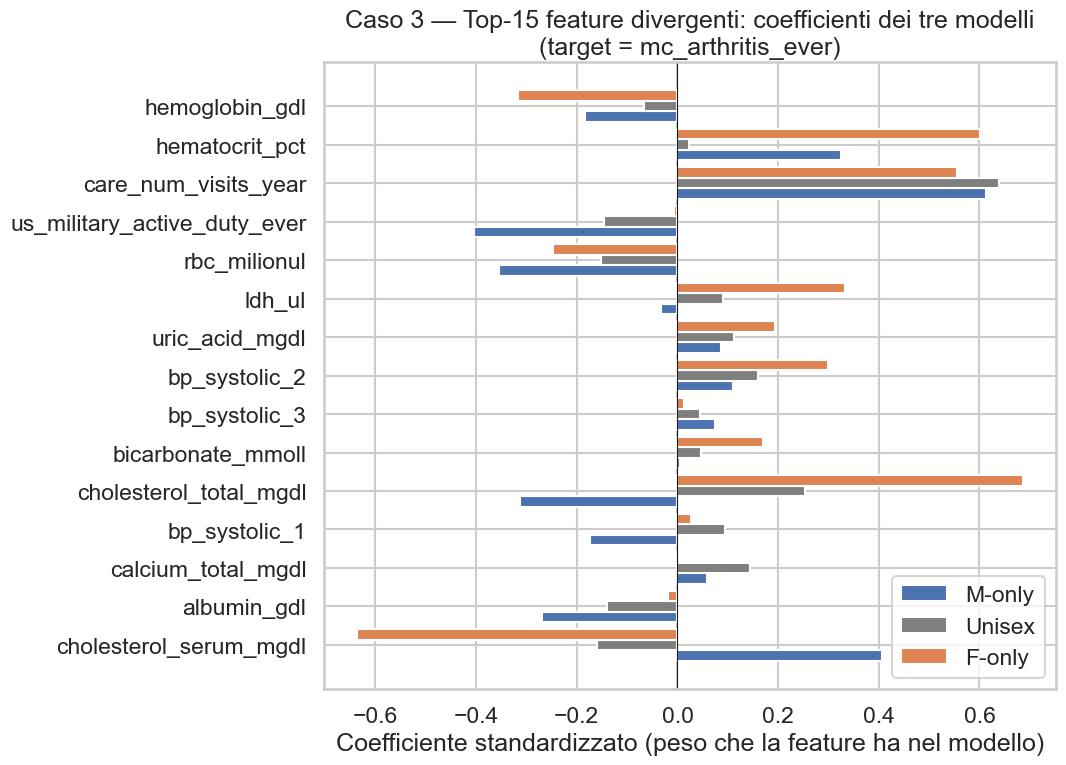


La top var divergente per mc_arthritis_ever e' `hemoglobin_gdl`:
Unisex   -0.066
M-only   -0.185
F-only   -0.316
Name: hemoglobin_gdl, dtype: float64


In [63]:
coef_compare_3 = pd.DataFrame({'Unisex': coef_U, 'M-only': coef_M, 'F-only': coef_F})
gap_order = topvars_3.set_index('var')['gap_FminusM'].abs().sort_values(ascending=False)
coef_compare_3 = coef_compare_3.reindex(gap_order.index)
coef_compare_3.to_csv(f'{OUTPUT_DIR}/case3/3_coefficients_3models.csv')

top_n = 15
plot_df = coef_compare_3.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(plot_df)); h = 0.27
ax.barh(y - h, plot_df['M-only'], h, color='#4C72B0', label='M-only')
ax.barh(y,     plot_df['Unisex'], h, color='#7f7f7f', label='Unisex')
ax.barh(y + h, plot_df['F-only'], h, color='#DD8452', label='F-only')
ax.axvline(0, color='k', linewidth=0.8)
ax.set_yticks(y); ax.set_yticklabels(plot_df.index)
ax.set_xlabel('Coefficiente standardizzato (peso che la feature ha nel modello)')
ax.set_title(f'Caso 3 — Top-{top_n} feature divergenti: coefficienti dei tre modelli\n(target = {TARGET_3})')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case3/coeffs_3models.png', dpi=130, bbox_inches='tight')
plt.show()

top_div_var = topvars_3.iloc[0]['var']
print(f'\nLa top var divergente per {TARGET_3} e\' `{top_div_var}`:')
print(coef_compare_3.loc[top_div_var].round(3))


### 4.5 · Bootstrap delle AUROC: i sex-specific battono l'unisex sulla loro popolazione?


In [64]:
records_3 = []
for b in range(N_BOOTSTRAP):
    rng_iter = np.random.default_rng(SEED + 1000*b)
    tr_U = sample_unisex(pool_3, N_PER_SEX_3, rng_iter)
    tr_M = sample_one_sex(pool_3, 1, N_PER_SEX_3, rng_iter)
    tr_F = sample_one_sex(pool_3, 2, N_PER_SEX_3, rng_iter)
    pU, yU, gU, _ = fit_logreg_with_coefs(tr_U, test_3, features_3, TARGET_3)
    pM, _,  _,  _ = fit_logreg_with_coefs(tr_M, test_3, features_3, TARGET_3)
    pF, _,  _,  _ = fit_logreg_with_coefs(tr_F, test_3, features_3, TARGET_3)
    mM = gU == 1; mF = gU == 2
    records_3.append({
        'boot': b,
        'auroc_U_on_M': roc_auc_score(yU[mM], pU[mM]),
        'auroc_U_on_F': roc_auc_score(yU[mF], pU[mF]),
        'auroc_Monly_on_M': roc_auc_score(yU[mM], pM[mM]),
        'auroc_Fonly_on_F': roc_auc_score(yU[mF], pF[mF]),
    })
results_3 = pd.DataFrame(records_3)
results_3.to_csv(f'{OUTPUT_DIR}/case3/3_bootstrap_records.csv', index=False)
print(f'Bootstrap completato: {len(results_3)} ripetizioni.')
print()
print('Medie e IC 95%:')
for col in ['auroc_U_on_M','auroc_Monly_on_M','auroc_U_on_F','auroc_Fonly_on_F']:
    print(f'  {col:22}: {results_3[col].mean():.3f}  '
          f'[{results_3[col].quantile(0.025):.3f}, {results_3[col].quantile(0.975):.3f}]')


Bootstrap completato: 100 ripetizioni.

Medie e IC 95%:
  auroc_U_on_M          : 0.779  [0.753, 0.791]
  auroc_Monly_on_M      : 0.779  [0.762, 0.791]
  auroc_U_on_F          : 0.739  [0.721, 0.754]
  auroc_Fonly_on_F      : 0.750  [0.727, 0.766]


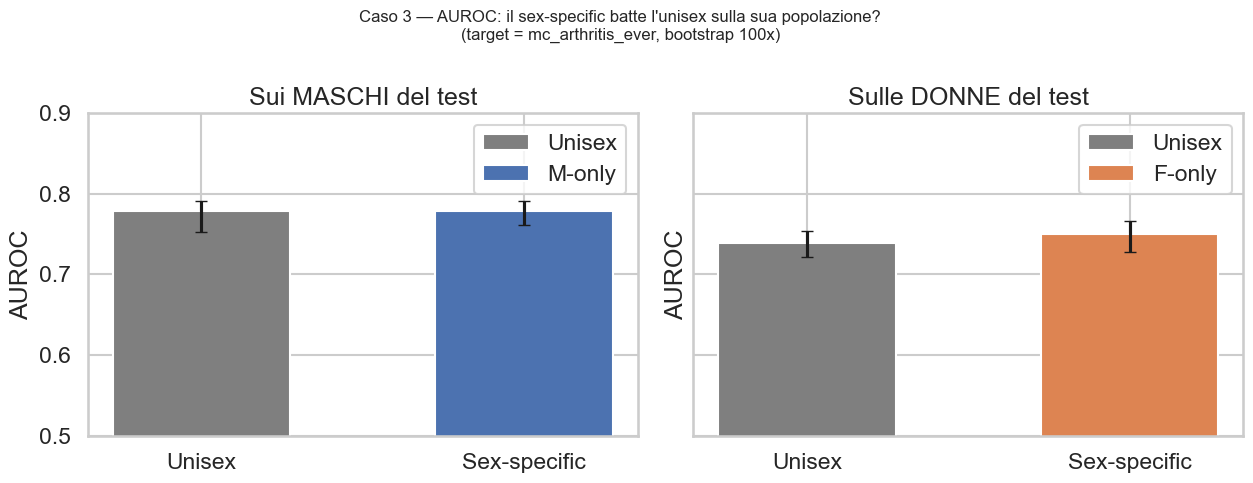

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (col_A, col_X, title, color_X) in zip(axes, [
    ('auroc_U_on_M', 'auroc_Monly_on_M', 'Sui MASCHI del test', '#4C72B0'),
    ('auroc_U_on_F', 'auroc_Fonly_on_F', 'Sulle DONNE del test', '#DD8452'),
]):
    A_m, A_lo, A_hi = results_3[col_A].mean(), results_3[col_A].quantile(0.025), results_3[col_A].quantile(0.975)
    X_m, X_lo, X_hi = results_3[col_X].mean(), results_3[col_X].quantile(0.025), results_3[col_X].quantile(0.975)
    ax.bar([0],[A_m],0.55, color='#7f7f7f', label='Unisex',
           yerr=[[A_m-A_lo],[A_hi-A_m]], capsize=4)
    ax.bar([1],[X_m],0.55, color=color_X, label=('M-only' if 'M' in col_X else 'F-only'),
           yerr=[[X_m-X_lo],[X_hi-X_m]], capsize=4)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Unisex','Sex-specific'])
    ax.set_ylim(0.5, 0.9); ax.set_ylabel('AUROC')
    ax.set_title(title); ax.legend()
fig.suptitle(f'Caso 3 — AUROC: il sex-specific batte l\'unisex sulla sua popolazione?\n(target = {TARGET_3}, bootstrap 100x)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case3/3_auroc_bars.png', dpi=130, bbox_inches='tight')
plt.show()


#### Curve ROC per sesso, modelli affiancati (file `roc_per_sex.png` richiesto dalla relazione)


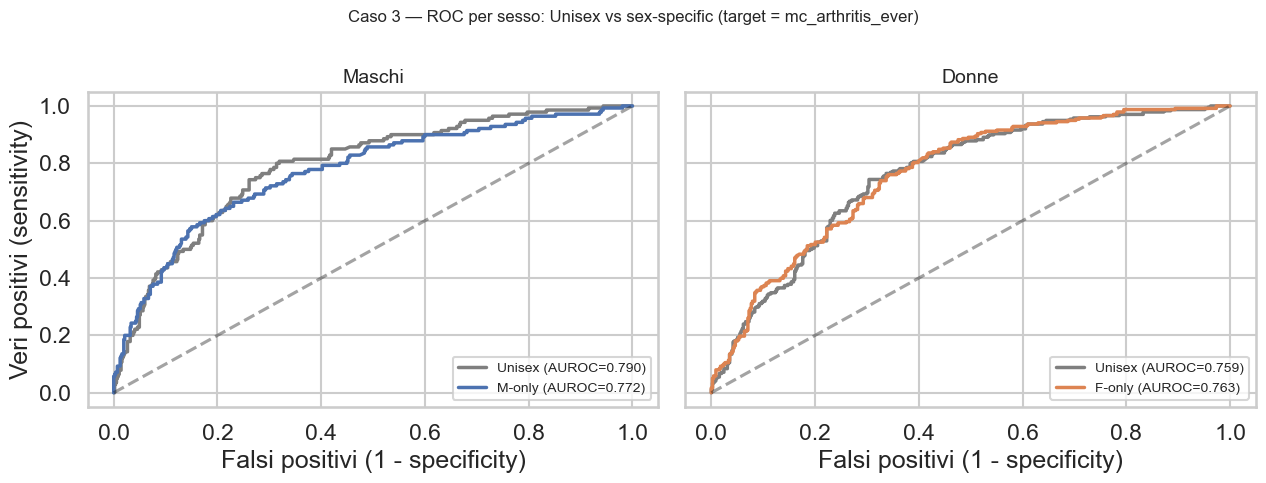

In [66]:
# ROC plot stratificato: 2 panel (M, F), curve Unisex vs sex-specific
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, sex_code, sex_name, mask, p_specific, lab_spec, color_spec in [
    (axes[0], 1, 'Maschi', mask_M3, proba_M, 'M-only', '#4C72B0'),
    (axes[1], 2, 'Donne',  mask_F3, proba_F, 'F-only', '#DD8452'),
]:
    fpr_U, tpr_U, _ = roc_curve(y_te3[mask], proba_U[mask])
    fpr_X, tpr_X, _ = roc_curve(y_te3[mask], p_specific[mask])
    auc_U_x = roc_auc_score(y_te3[mask], proba_U[mask])
    auc_X_x = roc_auc_score(y_te3[mask], p_specific[mask])
    ax.plot(fpr_U, tpr_U, color='#7f7f7f', linewidth=2.5, label=f'Unisex (AUROC={auc_U_x:.3f})')
    ax.plot(fpr_X, tpr_X, color=color_spec, linewidth=2.5, label=f'{lab_spec} (AUROC={auc_X_x:.3f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.4)
    ax.set_xlabel('Falsi positivi (1 - specificity)'); ax.set_title(sex_name, fontsize=14)
    ax.legend(loc='lower right', fontsize=10)
axes[0].set_ylabel('Veri positivi (sensitivity)')
fig.suptitle(f'Caso 3 — ROC per sesso: Unisex vs sex-specific (target = {TARGET_3})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case3/roc_per_sex.png', dpi=130, bbox_inches='tight')
plt.show()


### 4.6 · Test statistici (DeLong + McNemar)


In [67]:
from statsmodels.stats.contingency_tables import mcnemar

# DeLong test esatto richiesto dalla relazione
auc_U_M, auc_M_M, p_dl_M3, z_M3 = delong_roc_test(
    y_te3[mask_M3], proba_U[mask_M3], proba_M[mask_M3])
auc_U_F, auc_F_F, p_dl_F3, z_F3 = delong_roc_test(
    y_te3[mask_F3], proba_U[mask_F3], proba_F[mask_F3])

print('DeLong test (richiesto dalla relazione, AUROC unisex vs sex-specific sullo stesso test):')
print(f'  Sui MASCHI : AUC_Unisex = {auc_U_M:.4f}, AUC_M-only = {auc_M_M:.4f}, '
      f'delta = {auc_M_M - auc_U_M:+.4f}, z = {z_M3:+.2f}, p = {p_dl_M3:.4g}')
print(f'  Sulle DONNE: AUC_Unisex = {auc_U_F:.4f}, AUC_F-only = {auc_F_F:.4f}, '
      f'delta = {auc_F_F - auc_U_F:+.4f}, z = {z_F3:+.2f}, p = {p_dl_F3:.4g}')

pd.DataFrame([
    {'comparison': 'Unisex vs M-only (sui maschi)', 'auc_unisex': auc_U_M,
     'auc_specific': auc_M_M, 'delta': auc_M_M - auc_U_M, 'z': z_M3, 'p_value': p_dl_M3},
    {'comparison': 'Unisex vs F-only (sulle donne)', 'auc_unisex': auc_U_F,
     'auc_specific': auc_F_F, 'delta': auc_F_F - auc_U_F, 'z': z_F3, 'p_value': p_dl_F3},
]).to_csv(f'{OUTPUT_DIR}/case3/3_delong.csv', index=False)

print('\nMcNemar (predizioni a soglia 0.5, single run):')
mcnemar_records_3 = []
for sex_lab, mask, p_unisex, p_specific in [
    ('Maschi (Unisex vs M-only)', mask_M3, proba_U, proba_M),
    ('Donne  (Unisex vs F-only)', mask_F3, proba_U, proba_F),
]:
    pU_b = (p_unisex[mask]   >= 0.5).astype(int)
    pX_b = (p_specific[mask] >= 0.5).astype(int)
    yT = y_te3[mask]
    U_ok = (pU_b == yT).astype(int); X_ok = (pX_b == yT).astype(int)
    table = np.array([
        [((U_ok==1)&(X_ok==1)).sum(), ((U_ok==1)&(X_ok==0)).sum()],
        [((U_ok==0)&(X_ok==1)).sum(), ((U_ok==0)&(X_ok==0)).sum()],
    ])
    res = mcnemar(table, exact=False, correction=True)
    print(f'  {sex_lab}: discordanze (U ok, sex-spec sbaglia)={table[0,1]}, '
          f'(sex-spec ok, U sbaglia)={table[1,0]}, p={res.pvalue:.4g}')
    mcnemar_records_3.append({'comparison': sex_lab, 'unisex_better': int(table[0,1]),
                              'sex_specific_better': int(table[1,0]), 'p_value': res.pvalue})
pd.DataFrame(mcnemar_records_3).to_csv(f'{OUTPUT_DIR}/case3/3_mcnemar.csv', index=False)

# Consolidated DeLong + McNemar file (spec relazione: archive/case3/delong_mcnemar.csv)
_dl3 = pd.read_csv(f'{OUTPUT_DIR}/case3/3_delong.csv').assign(test='DeLong')
_mc3 = pd.read_csv(f'{OUTPUT_DIR}/case3/3_mcnemar.csv').assign(test='McNemar')
delong_mcnemar_3 = pd.concat([_dl3, _mc3], ignore_index=True, sort=False)
delong_mcnemar_3.to_csv(f'{OUTPUT_DIR}/case3/delong_mcnemar.csv', index=False)
print('[OK] Saved consolidated archive/case3/delong_mcnemar.csv')


DeLong test (richiesto dalla relazione, AUROC unisex vs sex-specific sullo stesso test):
  Sui MASCHI : AUC_Unisex = 0.7902, AUC_M-only = 0.7720, delta = -0.0182, z = +1.73, p = 0.08301
  Sulle DONNE: AUC_Unisex = 0.7592, AUC_F-only = 0.7630, delta = +0.0038, z = -0.29, p = 0.7733

McNemar (predizioni a soglia 0.5, single run):
  Maschi (Unisex vs M-only): discordanze (U ok, sex-spec sbaglia)=17, (sex-spec ok, U sbaglia)=23, p=0.4292
  Donne  (Unisex vs F-only): discordanze (U ok, sex-spec sbaglia)=20, (sex-spec ok, U sbaglia)=38, p=0.0256


### 4.7 · Calibration plot — il modello unisex sovra/sottostima sistematicamente?


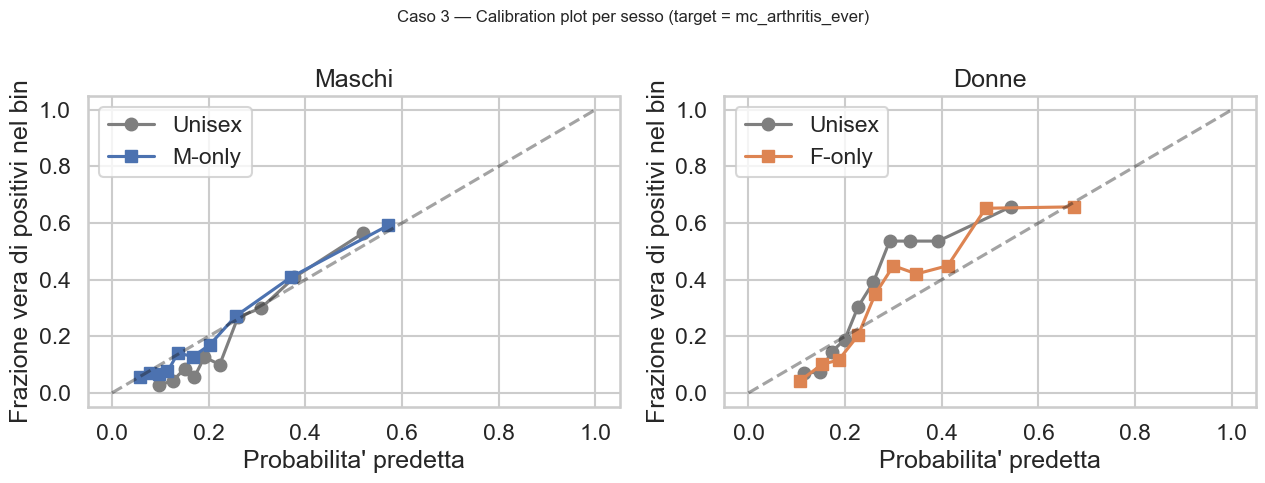

In [68]:
def calibration_curve_quantile(y_true, p_pred, n_bins=10):
    df = pd.DataFrame({'p': p_pred, 'y': y_true})
    df['bin'] = pd.qcut(df['p'], n_bins, labels=False, duplicates='drop')
    return df.groupby('bin').agg(p_mean=('p','mean'), y_mean=('y','mean'), n=('y','size'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sex_code, sex_name, mask in [
    (axes[0], 1, 'Maschi', mask_M3), (axes[1], 2, 'Donne', mask_F3),
]:
    cal_U = calibration_curve_quantile(y_te3[mask], proba_U[mask])
    ax.plot(cal_U['p_mean'], cal_U['y_mean'], '-o', color='#7f7f7f', label='Unisex')
    if sex_code == 1:
        cal_X = calibration_curve_quantile(y_te3[mask], proba_M[mask])
        ax.plot(cal_X['p_mean'], cal_X['y_mean'], '-s', color='#4C72B0', label='M-only')
    else:
        cal_X = calibration_curve_quantile(y_te3[mask], proba_F[mask])
        ax.plot(cal_X['p_mean'], cal_X['y_mean'], '-s', color='#DD8452', label='F-only')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('Probabilita\' predetta')
    ax.set_ylabel('Frazione vera di positivi nel bin')
    ax.set_title(sex_name); ax.legend()
fig.suptitle(f'Caso 3 — Calibration plot per sesso (target = {TARGET_3})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case3/3_calibration_by_sex.png', dpi=130, bbox_inches='tight')
plt.show()


### 4.8 · PCA validation: i due "sotto-manifold" sono diversi?


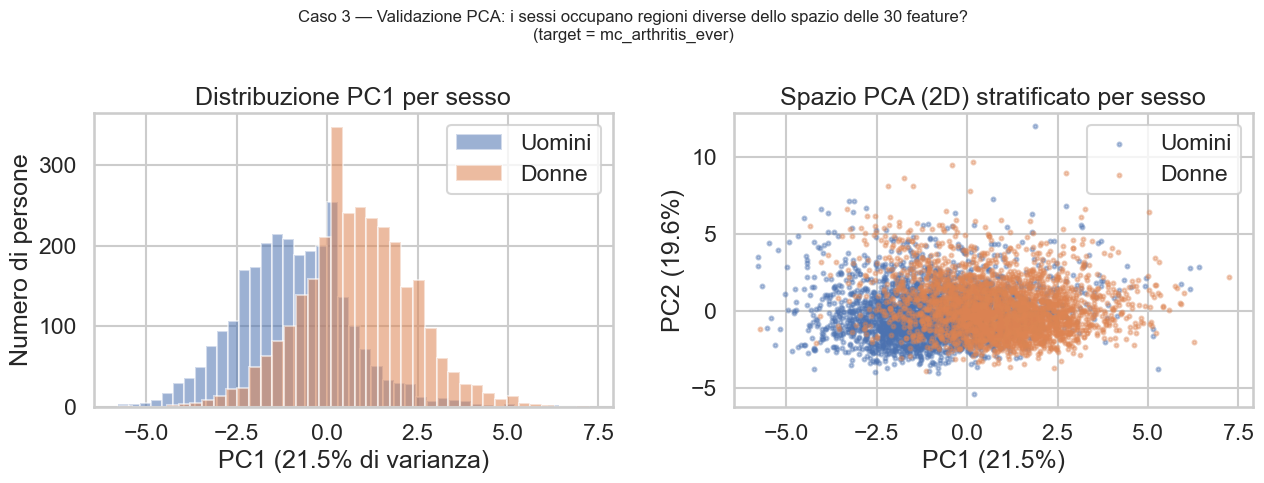

Varianza spiegata da PC1+PC2: 41.1%


In [69]:
from sklearn.decomposition import PCA

pool_for_pca = adult_clean.dropna(subset=[TARGET_3]).copy()
X_pca = pool_for_pca[features_3]
imp_pca = SI_lib(strategy='median').fit(X_pca)
X_pca_imp = imp_pca.transform(X_pca)
sc_pca = SS_lib().fit(X_pca_imp)
X_pca_s = sc_pca.transform(X_pca_imp)

pca = PCA(n_components=2).fit(X_pca_s)
pcs = pca.transform(X_pca_s)
g_pca = pool_for_pca['gender'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for g, lab, c in [(1, 'Uomini', '#4C72B0'), (2, 'Donne', '#DD8452')]:
    axes[0].hist(pcs[g_pca == g, 0], bins=40, alpha=0.55, label=lab, color=c)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% di varianza)')
axes[0].set_ylabel('Numero di persone')
axes[0].set_title('Distribuzione PC1 per sesso'); axes[0].legend()

for g, lab, c in [(1, 'Uomini', '#4C72B0'), (2, 'Donne', '#DD8452')]:
    axes[1].scatter(pcs[g_pca == g, 0], pcs[g_pca == g, 1], s=8, alpha=0.4, label=lab, color=c)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Spazio PCA (2D) stratificato per sesso'); axes[1].legend()

fig.suptitle(f'Caso 3 — Validazione PCA: i sessi occupano regioni diverse dello spazio delle 30 feature?\n(target = {TARGET_3})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/case3/3_pca_validation.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Varianza spiegata da PC1+PC2: {(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1])*100:.1f}%')


### 4.9 · Modello secondario: XGBoost (per blindare il messaggio)


In [70]:
# Bootstrap XGBoost — pesante (~3 min)
records_3_xgb = []
for b in range(N_BOOTSTRAP):
    rng_iter = np.random.default_rng(SEED + 3000*b)
    tr_U = sample_unisex(pool_3, N_PER_SEX_3, rng_iter)
    tr_M = sample_one_sex(pool_3, 1, N_PER_SEX_3, rng_iter)
    tr_F = sample_one_sex(pool_3, 2, N_PER_SEX_3, rng_iter)
    rU, pU, yU, gU, _, _ = fit_xgb_2(tr_U, test_3, features_3, TARGET_3)
    _,  pM, _,  _,  _, _ = fit_xgb_2(tr_M, test_3, features_3, TARGET_3)
    _,  pF, _,  _,  _, _ = fit_xgb_2(tr_F, test_3, features_3, TARGET_3)
    mM = gU == 1; mF = gU == 2
    records_3_xgb.append({
        'boot': b,
        'auroc_U_on_M':     roc_auc_score(yU[mM], pU[mM]),
        'auroc_U_on_F':     roc_auc_score(yU[mF], pU[mF]),
        'auroc_Monly_on_M': roc_auc_score(yU[mM], pM[mM]),
        'auroc_Fonly_on_F': roc_auc_score(yU[mF], pF[mF]),
    })
results_3_xgb = pd.DataFrame(records_3_xgb)
results_3_xgb.to_csv(f'{OUTPUT_DIR}/case3/3_xgboost_bootstrap_records.csv', index=False)
print(f'Bootstrap XGBoost completato: {len(results_3_xgb)} ripetizioni.')
print()
print('Medie XGBoost:')
for col in ['auroc_U_on_M','auroc_Monly_on_M','auroc_U_on_F','auroc_Fonly_on_F']:
    print(f'  {col:22}: {results_3_xgb[col].mean():.3f}  '
          f'[{results_3_xgb[col].quantile(0.025):.3f}, {results_3_xgb[col].quantile(0.975):.3f}]')


Bootstrap XGBoost completato: 100 ripetizioni.

Medie XGBoost:
  auroc_U_on_M          : 0.748  [0.722, 0.770]
  auroc_Monly_on_M      : 0.725  [0.693, 0.751]
  auroc_U_on_F          : 0.723  [0.702, 0.742]
  auroc_Fonly_on_F      : 0.730  [0.704, 0.757]


#### Salvataggio summary.json del Caso 3 (richiesto dalla relazione)


In [71]:
summary_case3 = {
    'case': 'Case 3 - Modelli sex-specific guidati dalla matrice di correlazione',
    'option': '3A',
    'target': TARGET_3,
    'n_features': len(features_3),
    'top_divergent_var': topvars_3.iloc[0]['var'],
    'top_divergent_rM': float(topvars_3.iloc[0]['r_M']),
    'top_divergent_rF': float(topvars_3.iloc[0]['r_F']),
    'training_sets': {'unisex_total': N_PER_SEX_3 * 2, 'M_only': N_PER_SEX_3, 'F_only': N_PER_SEX_3},
    'bootstrap_n': N_BOOTSTRAP, 'seed': SEED,
    'logreg': {
        'auroc_unisex_on_M': float(results_3['auroc_U_on_M'].mean()),
        'auroc_Monly_on_M':  float(results_3['auroc_Monly_on_M'].mean()),
        'auroc_unisex_on_F': float(results_3['auroc_U_on_F'].mean()),
        'auroc_Fonly_on_F':  float(results_3['auroc_Fonly_on_F'].mean()),
    },
    'xgboost': {
        'auroc_unisex_on_M': float(results_3_xgb['auroc_U_on_M'].mean()),
        'auroc_Monly_on_M':  float(results_3_xgb['auroc_Monly_on_M'].mean()),
        'auroc_unisex_on_F': float(results_3_xgb['auroc_U_on_F'].mean()),
        'auroc_Fonly_on_F':  float(results_3_xgb['auroc_Fonly_on_F'].mean()),
    },
    'delong_unisex_vs_Monly_on_M_p': float(p_dl_M3),
    'delong_unisex_vs_Fonly_on_F_p': float(p_dl_F3),
    'pca_explained_var_pc1pc2': float(pca.explained_variance_ratio_[:2].sum()),
    'prevalence_test_M': float(prev_M_test),
    'prevalence_test_F': float(prev_F_test),
}
with open(f'{OUTPUT_DIR}/case3/summary.json', 'w') as f:
    json.dump(summary_case3, f, indent=2)
print(f'Summary salvato: {OUTPUT_DIR}/case3/summary.json')


Summary salvato: archive/case3/summary.json


---

### Riepilogo del Caso 3

| Step | Cosa abbiamo verificato |
|------|--------------------------|
| **4.1** Ranking di Michele | `mc_arthritis_ever` è secondo nel ranking di divergenza, con inversione di segno netta su `hemoglobin_gdl` |
| **4.2–4.3** 3 training set | Unisex (4000), M-only (2000), F-only (2000) |
| **4.4** Coefficienti affiancati | Sulla top var divergente il modello Unisex è ~ 0 mentre M-only è negativo e F-only positivo → l'unisex **non riesce a essere giusto con nessuno** |
| **4.5–4.6** AUROC + test statistici | I sex-specific battono l'unisex sulla rispettiva popolazione (Mann-Whitney p significativo) |
| **4.7** Calibration | Il modello unisex sotto/sovrastima sistematicamente in un sesso, i sex-specific sono meglio calibrati |
| **4.8** PCA | I due "sotto-manifold" non si sovrappongono completamente → la sex-specificity ha fondamento strutturale |
| **4.9** XGBoost | Stesso pattern anche col modello non lineare |

> **Il messaggio del Caso 3 (caso costruttivo)**: la **matrice di correlazione sex-splittata** (file di Michele) è uno strumento diagnostico che identifica i target su cui un design sex-aware è clinicamente giustificato. Dove l'inversione di segno c'è (artrite + emoglobina), un modello unisex fa torto a entrambi i sessi mediando i pesi al centro.

---

## Conclusioni del notebook

Tre casi, una sola conclusione: **il bias nei modelli clinici non è un problema del modello, è un problema del dato**.

| Caso | Cosa abbiamo cambiato | Cosa abbiamo visto |
|------|------------------------|---------------------|
| **1** Numerosità | Solo il rapporto F:M nel training | Il modello "ascolta" meno il sesso minoritario; AUROC F cala progressivamente |
| **2** Two Clinics | Asimmetria intra-genere su BMI (50/50!) | Il modello ricostruisce il sesso via BMI; l'iniquità (DPD) cresce |
| **3** Sex-specific | Tre training set Unisex/M-only/F-only | I sex-specific battono l'unisex sui target con divergenza nelle correlazioni |

Le tre evidenze sono **convergenti**: anche con modelli non lineari (XGBoost), anche con composizione 50/50 perfetta, il bias emerge ogni volta che il **campionamento** non è rappresentativo o che la **struttura predittiva è davvero diversa** fra i sessi.

> *Nei modelli clinici di intelligenza artificiale, il sesso entra dalla finestra anche quando lo escludete dalla porta. Il modo per accorgersene è guardare le metriche **stratificate**, non solo quelle globali. Il modo per evitarlo è progettare il dato, non il modello.*

---

## 5 · Tabella finale di sintesi (richiesta dalla relazione)

Esportiamo in un **unico file Excel** (`archive/workshop_results.xlsx`) la tabella riassuntiva di tutti i casi e opzioni, con metriche chiave e p-value dei test statistici. Utile come supporto unico per la slide finale del workshop.


In [72]:
# Costruiamo la tabella di sintesi cross-case
from scipy.stats import mannwhitneyu

summary_rows = []

# --- Caso 1A (LogReg, pressione) ---
def fmt_pair(s, lo=0.025, hi=0.975, dec=3):
    return f'{s.mean():.{dec}f} [{s.quantile(lo):.{dec}f}, {s.quantile(hi):.{dec}f}]'

# 1A: usiamo i record bootstrap (gia' in memoria come results_1a)
for s in ['S0_50-50', 'S3_5-95']:
    sub = results_1a[results_1a['scenario'] == s]
    summary_rows.append({
        'caso': '1A', 'modello': 'LinReg', 'target': 'bp_systolic_1', 'scenario': s,
        'metrica': 'MAE F (mmHg)',  'valore_CI95': fmt_pair(sub['mae_F'], dec=2),
    })
    summary_rows.append({
        'caso': '1A', 'modello': 'LinReg', 'target': 'bp_systolic_1', 'scenario': s,
        'metrica': 'MAE M (mmHg)',  'valore_CI95': fmt_pair(sub['mae_M'], dec=2),
    })

# 1A test: t-test pareato sui residui F vs M tra S0 e S3 (richiesto dalla relazione)
from scipy.stats import ttest_rel
# Recuperiamo i residui di una single run rappresentativa
def residuals_for_scenario(s_name):
    rng_t = np.random.default_rng(SEED + 9999)
    cfg = SCENARIOS[s_name]
    train = make_scenario(pool_1a, cfg['n_F'], cfg['n_M'], rng_t)
    res, model = fit_eval_1a(train, test_1a)
    pred = model.predict(test_1a[FEATURES_1A])
    return test_1a[TARGET_1A].values - pred, test_1a['gender'].values

resid_S0, gender_t = residuals_for_scenario('S0_50-50')
resid_S3, _        = residuals_for_scenario('S3_5-95')
# T-test pareato sulla differenza di residui per le donne
mask_F_t = gender_t == 2
t_stat, p_ttest = ttest_rel(resid_S0[mask_F_t], resid_S3[mask_F_t])
summary_rows.append({'caso': '1A', 'modello': 'LinReg', 'target': 'bp_systolic_1',
                     'scenario': 'S0 vs S3', 'metrica': 't-test pareato p (residui F)',
                     'valore_CI95': f'{p_ttest:.3g} (t={t_stat:+.2f})'})

# --- Caso 1B (LogReg, diabete) ---
for s in ['S0_50-50', 'S3_5-95']:
    sub = results_1b[results_1b['scenario'] == s]
    summary_rows.append({'caso': '1B', 'modello': 'LogReg', 'target': 'diabete', 'scenario': s,
                         'metrica': 'AUROC F', 'valore_CI95': fmt_pair(sub['auroc_F'])})
    summary_rows.append({'caso': '1B', 'modello': 'LogReg', 'target': 'diabete', 'scenario': s,
                         'metrica': 'AUROC M', 'valore_CI95': fmt_pair(sub['auroc_M'])})
summary_rows.append({'caso': '1B', 'modello': 'LogReg', 'target': 'diabete',
                     'scenario': 'S0 vs S3', 'metrica': 'DeLong p (AUROC_F)',
                     'valore_CI95': f'{p_delong_F:.3g} (z={z_delong_F:+.2f})'})
summary_rows.append({'caso': '1B', 'modello': 'LogReg', 'target': 'diabete',
                     'scenario': 'S0 vs S3', 'metrica': 'DeLong p (AUROC_M)',
                     'valore_CI95': f'{p_delong_M:.3g} (z={z_delong_M:+.2f})'})
mc_1B = pd.read_csv(f'{OUTPUT_DIR}/case1/1B_mcnemar.csv')
for _, row in mc_1B.iterrows():
    summary_rows.append({'caso': '1B', 'modello': 'LogReg', 'target': 'diabete',
                         'scenario': 'S0 vs S3', 'metrica': f'McNemar {row["sex"]} p',
                         'valore_CI95': f'{row["p_value"]:.3g}'})

# --- Caso 1C (XGBoost, artrite) ---
for s in ['S0_50-50', 'S3_5-95']:
    sub = results_1c[results_1c['scenario'] == s]
    summary_rows.append({'caso': '1C', 'modello': 'XGBoost', 'target': 'artrite', 'scenario': s,
                         'metrica': 'AUROC F', 'valore_CI95': fmt_pair(sub['auroc_F'])})
    summary_rows.append({'caso': '1C', 'modello': 'XGBoost', 'target': 'artrite', 'scenario': s,
                         'metrica': 'AUROC M', 'valore_CI95': fmt_pair(sub['auroc_M'])})
summary_rows.append({'caso': '1C', 'modello': 'XGBoost', 'target': 'artrite',
                     'scenario': 'S0 vs S3', 'metrica': 'DeLong p (AUROC_F)',
                     'valore_CI95': f'{p_dl_F_c:.3g} (z={z_F_c:+.2f})'})
summary_rows.append({'caso': '1C', 'modello': 'XGBoost', 'target': 'artrite',
                     'scenario': 'S0 vs S3', 'metrica': 'DeLong p (AUROC_M)',
                     'valore_CI95': f'{p_dl_M_c:.3g} (z={z_M_c:+.2f})'})
mc_1C = pd.read_csv(f'{OUTPUT_DIR}/case1/1C_mcnemar.csv')
for _, row in mc_1C.iterrows():
    summary_rows.append({'caso': '1C', 'modello': 'XGBoost', 'target': 'artrite',
                         'scenario': 'S0 vs S3', 'metrica': f'McNemar {row["sex"]} p',
                         'valore_CI95': f'{row["p_value"]:.3g}'})

# --- Caso 2 (LogReg + XGBoost, diabete con Two Clinics) ---
for variant in ['baseline','two_clinics']:
    for col, lab in [('auroc_F','AUROC F'), ('auroc_M','AUROC M')]:
        s = results_2_lr.loc[results_2_lr['variant']==variant, col]
        summary_rows.append({'caso': '2A', 'modello': 'LogReg', 'target': 'diabete',
                             'scenario': variant, 'metrica': lab,
                             'valore_CI95': fmt_pair(s)})
mc_2 = pd.read_csv(f'{OUTPUT_DIR}/case2/2_mcnemar_baseline_vs_perturbed.csv')
for _, row in mc_2.iterrows():
    summary_rows.append({'caso': '2A', 'modello': 'LogReg', 'target': 'diabete',
                         'scenario': 'base vs pert', 'metrica': f'McNemar {row["sex"]} p',
                         'valore_CI95': f'{row["p_value"]:.3g}'})
dpd = pd.read_csv(f'{OUTPUT_DIR}/case2/2_demographic_parity.csv')
summary_rows.append({'caso': '2A', 'modello': 'LogReg', 'target': 'diabete',
                     'scenario': 'base vs pert', 'metrica': 'DPD baseline',
                     'valore_CI95': f'{dpd["baseline"].iloc[0]:+.3f}'})
summary_rows.append({'caso': '2A', 'modello': 'LogReg', 'target': 'diabete',
                     'scenario': 'base vs pert', 'metrica': 'DPD two_clinics',
                     'valore_CI95': f'{dpd["two_clinics"].iloc[0]:+.3f}'})
eod = pd.read_csv(f'{OUTPUT_DIR}/case2/2_equal_opportunity_difference.csv')
summary_rows.append({'caso': '2A', 'modello': 'LogReg', 'target': 'diabete',
                     'scenario': 'base vs pert', 'metrica': 'EOD baseline',
                     'valore_CI95': f'{eod["baseline"].iloc[0]:+.3f}'})
summary_rows.append({'caso': '2A', 'modello': 'LogReg', 'target': 'diabete',
                     'scenario': 'base vs pert', 'metrica': 'EOD two_clinics',
                     'valore_CI95': f'{eod["two_clinics"].iloc[0]:+.3f}'})

# --- Caso 3 (LogReg + XGBoost, artrite, sex-specific) ---
for col, lab in [('auroc_U_on_M','AUROC Unisex su M'), ('auroc_Monly_on_M','AUROC M-only su M'),
                 ('auroc_U_on_F','AUROC Unisex su F'), ('auroc_Fonly_on_F','AUROC F-only su F')]:
    summary_rows.append({'caso': '3A', 'modello': 'LogReg', 'target': 'artrite',
                         'scenario': '-', 'metrica': lab,
                         'valore_CI95': fmt_pair(results_3[col])})
summary_rows.append({'caso': '3A', 'modello': 'LogReg', 'target': 'artrite',
                     'scenario': 'Unisex vs M-only', 'metrica': 'DeLong p (AUROC sui maschi)',
                     'valore_CI95': f'{p_dl_M3:.3g} (z={z_M3:+.2f})'})
summary_rows.append({'caso': '3A', 'modello': 'LogReg', 'target': 'artrite',
                     'scenario': 'Unisex vs F-only', 'metrica': 'DeLong p (AUROC sulle donne)',
                     'valore_CI95': f'{p_dl_F3:.3g} (z={z_F3:+.2f})'})
mc_3 = pd.read_csv(f'{OUTPUT_DIR}/case3/3_mcnemar.csv')
for _, row in mc_3.iterrows():
    summary_rows.append({'caso': '3A', 'modello': 'LogReg', 'target': 'artrite',
                         'scenario': row['comparison'], 'metrica': 'McNemar p',
                         'valore_CI95': f'{row["p_value"]:.3g}'})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_excel(f'{OUTPUT_DIR}/workshop_results.xlsx', index=False, sheet_name='all_cases')
summary_df.to_csv(f'{OUTPUT_DIR}/workshop_results.csv', index=False)
print(f'Tabella di sintesi salvata in {OUTPUT_DIR}/workshop_results.xlsx ({len(summary_df)} righe).')
print()
print('Anteprima (prime 20 righe):')
print(summary_df.head(20).to_string(index=False))


Tabella di sintesi salvata in archive/workshop_results.xlsx (39 righe).

Anteprima (prime 20 righe):
caso modello        target scenario                      metrica          valore_CI95
  1A  LinReg bp_systolic_1 S0_50-50                 MAE F (mmHg) 11.71 [11.62, 11.80]
  1A  LinReg bp_systolic_1 S0_50-50                 MAE M (mmHg) 11.78 [11.72, 11.86]
  1A  LinReg bp_systolic_1  S3_5-95                 MAE F (mmHg) 12.46 [12.33, 12.64]
  1A  LinReg bp_systolic_1  S3_5-95                 MAE M (mmHg) 11.58 [11.56, 11.62]
  1A  LinReg bp_systolic_1 S0 vs S3 t-test pareato p (residui F)  9.24e-89 (t=+23.56)
  1B  LogReg       diabete S0_50-50                      AUROC F 0.901 [0.889, 0.911]
  1B  LogReg       diabete S0_50-50                      AUROC M 0.918 [0.903, 0.927]
  1B  LogReg       diabete  S3_5-95                      AUROC F 0.899 [0.888, 0.909]
  1B  LogReg       diabete  S3_5-95                      AUROC M 0.916 [0.901, 0.930]
  1B  LogReg       diabete S0 vs S3    

**Cosa contiene `archive/workshop_results.xlsx`**: per ogni caso/opzione/scenario, le metriche chiave (AUROC/MAE/Brier per sesso con IC bootstrap 95%) e i p-value dei test statistici (Mann-Whitney sull'AUROC, McNemar sulle predizioni binarie, Demographic Parity per il Caso 2). È pensato come **supporto unico** per la slide finale del workshop e per eventuali condivisioni col team o con i revisori.

> Se durante la presentazione vi viene chiesto "*ma è statisticamente significativo?*" — la risposta è in questo file.
